In [1]:
!pip install kaggle --quiet

In [2]:

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"petal2025","key":"c88a6e1381bcb3683557de000aaecce3"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d lainguyn123/student-performance-factors
!kaggle datasets download -d eldarsarajlic/college-enrollment-in-the-us-20032021
!kaggle datasets download -d raymondtoo/the-world-university-rankings-2016-2024
!kaggle datasets download -d thedevastator/higher-education-predictors-of-student-retention
!kaggle datasets download -d jeromeblanchet/drivendatas-boxplots-for-education-dataset

Dataset URL: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
License(s): CC0-1.0
  0% 0.00/93.9k [00:00<?, ?B/s]
100% 93.9k/93.9k [00:00<00:00, 90.0MB/s]
Dataset URL: https://www.kaggle.com/datasets/eldarsarajlic/college-enrollment-in-the-us-20032021
License(s): unknown
  0% 0.00/819 [00:00<?, ?B/s]
100% 819/819 [00:00<00:00, 3.23MB/s]
Dataset URL: https://www.kaggle.com/datasets/raymondtoo/the-world-university-rankings-2016-2024
License(s): MIT
  0% 0.00/622k [00:00<?, ?B/s]
100% 622k/622k [00:00<00:00, 1.07GB/s]
Dataset URL: https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention
License(s): CC0-1.0
  0% 0.00/87.2k [00:00<?, ?B/s]
100% 87.2k/87.2k [00:00<00:00, 197MB/s]
Dataset URL: https://www.kaggle.com/datasets/jeromeblanchet/drivendatas-boxplots-for-education-dataset
License(s): unknown
  0% 0.00/20.7M [00:00<?, ?B/s]
100% 20.7M/20.7M [00:00<00:00, 1.29GB/s]


In [5]:
!unzip -q student-performance-factors.zip -d student_performance
!unzip -q college-enrollment-in-the-us-20032021.zip -d college_enrollment
!unzip -q the-world-university-rankings-2016-2024.zip -d university_rankings
!unzip -q higher-education-predictors-of-student-retention.zip -d retention
!unzip -q drivendatas-boxplots-for-education-dataset.zip -d education

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.ion()


In [7]:
%matplotlib inline

In [ ]:
"""
generic_accuracy_calculator_enhanced.py
======================================
- Fixes ColumnTransformer+TFIDF single-column Series issue via [tc] + flatten
- Provides preprocessing + baseline & tuned model training
- Returns rich metric dicts including timing + best params + best CV score
- NO LinearRegression anywhere (by design)
- Adds HistGradientBoosting (HistGB) for both regression & classification

NOTE: SHAP plotting + readiness scoring are handled in vertexML_enhanced.py.
"""

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import time
from typing import Dict, Tuple, Any, List, Optional

from scipy import sparse

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier, HistGradientBoostingRegressor

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False


def detect_and_transform_wide_format(df: pd.DataFrame) -> Tuple[pd.DataFrame, bool]:
    year_cols = [c for c in df.columns if str(c).isdigit() and len(str(c)) == 4]
    if len(year_cols) >= 5:
        id_cols = [c for c in df.columns if c not in year_cols]
        df_long = df.melt(id_vars=id_cols, value_vars=year_cols, var_name="Year", value_name="Value")
        df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
        df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")
        return df_long, True
    return df, False


def detect_text_columns(df: pd.DataFrame, max_unique_ratio: float = 0.8) -> List[str]:
    text_cols = []
    for c in df.columns:
        if df[c].dtype == "object":
            sample = df[c].dropna().astype(str).head(300)
            if len(sample) == 0:
                continue
            avg_len = sample.map(len).mean()
            uniq_ratio = sample.nunique() / max(len(sample), 1)
            if avg_len >= 20 and uniq_ratio <= max_unique_ratio:
                text_cols.append(c)
    return text_cols


def detect_task_type(y: pd.Series, user_task_type: str = "auto") -> str:
    if user_task_type and str(user_task_type).lower() != "auto":
        return user_task_type
    if y.dtype == "object" or y.dtype.name == "category":
        return "Classification"
    nun = y.dropna().nunique()
    if pd.api.types.is_integer_dtype(y) and nun <= 20:
        return "Classification"
    return "Regression"


def build_preprocessor(
    X: pd.DataFrame,
    text_cols: List[str],
    use_tfidf: bool = True,
    max_tfidf_features: int = 10000
) -> ColumnTransformer:
    all_cols = list(X.columns)
    text_cols = [c for c in text_cols if c in all_cols]

    numeric_cols = [c for c in all_cols if pd.api.types.is_numeric_dtype(X[c]) and c not in text_cols]
    categorical_cols = [c for c in all_cols if (X[c].dtype == "object" or X[c].dtype.name == "category") and c not in text_cols]

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False))
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    transformers = []
    if numeric_cols:
        transformers.append(("num", num_pipe, numeric_cols))
    if categorical_cols:
        transformers.append(("cat", cat_pipe, categorical_cols))

    if use_tfidf and text_cols:
        for tc in text_cols:
            text_pipe = Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("flatten", FunctionTransformer(lambda x: x.ravel().astype(str), validate=False)),
                ("tfidf", TfidfVectorizer(max_features=max_tfidf_features, stop_words="english"))
            ])
            transformers.append((f"tfidf_{tc}", text_pipe, [tc]))  # ✅ [tc] keeps it 2D

    return ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.3)


def preprocess_data(
    df: pd.DataFrame,
    target_column: str,
    task_type: str = "auto",
    feature_columns: Optional[List[str]] = None,
    use_tfidf: bool = True,
    max_tfidf_features: int = 10000,
    test_size: float = 0.2,
    random_state: int = 42
):
    if feature_columns is None:
        X = df.drop(columns=[target_column])
    else:
        X = df[feature_columns].copy()

    y = df[target_column].copy()
    task_type_final = detect_task_type(y, user_task_type=task_type)

    label_encoder = None
    if task_type_final == "Classification":
        label_encoder = LabelEncoder()
        y = y.astype(str).fillna("NA")
        y = label_encoder.fit_transform(y)

    text_cols = detect_text_columns(X)
    # If TF-IDF is disabled, do NOT use TF-IDF; let build_preprocessor treat object columns as categorical.
    if not use_tfidf:
        text_cols = []
    preprocessor = build_preprocessor(X, text_cols, use_tfidf=use_tfidf, max_tfidf_features=max_tfidf_features)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if task_type_final == "Classification" else None
    )

    return X_train, X_test, y_train, y_test, task_type_final, preprocessor, label_encoder


def calculate_all_metrics(y_true, y_pred, task_type: str) -> Dict[str, float]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-9, 1e-9, np.abs(y_true))
    mape = float(np.mean(np.abs((y_true - y_pred) / denom))) * 100.0
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")

    if task_type == "Regression":
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        denom = np.where(np.abs(y_true) < 1e-9, 1e-9, np.abs(y_true))
        mape = float(np.mean(np.abs((y_true - y_pred) / denom))) * 100.0
        return {
            "Regression_Accuracy_R2": round(float(r2), 4),
            "Accuracy": round(float(acc), 4),
            "Classification_Accuracy": round(float(acc), 4),
            "F1_Score": round(float(f1), 4),
            "R2": round(float(r2), 4),
            "MAE": round(float(mae), 4),
            "RMSE": round(float(rmse), 4),
            "MAPE": round(float(mape), 4),
        }

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return {
        "Accuracy": round(float(acc), 4),
        "Classification_Accuracy": round(float(acc), 4),
        "F1_Score": round(float(f1), 4),
        "R2": round(float(r2), 4),
        "MAE": round(float(mae), 4),
        "RMSE": round(float(rmse), 4),
        "MAPE": round(float(mape), 4),

    }


def get_base_models(task_type: str) -> Dict[str, Any]:
    if task_type == "Regression":
        models = {
            "RandomForest": RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1),
            "HistGB": HistGradientBoostingRegressor(random_state=42),
        }
        if XGB_AVAILABLE:
            models["XGBoost"] = xgb.XGBRegressor(
                random_state=42, n_estimators=400, learning_rate=0.05,
                max_depth=6, subsample=0.8, colsample_bytree=0.8
            )
        if LGB_AVAILABLE:
            models["LightGBM"] = lgb.LGBMRegressor(
                random_state=42, n_estimators=600, learning_rate=0.05
            )
        return models

    models = {
        "LogisticRegression": LogisticRegression(max_iter=2000, n_jobs=-1),
        "RandomForest": RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1),
        "HistGB": HistGradientBoostingClassifier(random_state=42),
    }
    if XGB_AVAILABLE:
        models["XGBoost"] = xgb.XGBClassifier(
            random_state=42, n_estimators=400, learning_rate=0.05,
            max_depth=6, subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss"
        )
    if LGB_AVAILABLE:
        models["LightGBM"] = lgb.LGBMClassifier(
            random_state=42, n_estimators=600, learning_rate=0.05
        )
    return models


def get_tuning_space(task_type: str) -> Dict[str, Dict[str, Any]]:
    if task_type == "Regression":
        spaces = {
            "RandomForest": {
                "model__n_estimators": [150, 300, 500],
                "model__max_depth": [None, 8, 12, 20],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
            }
        }

        spaces["HistGB"] = {
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [None, 6, 10],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__min_samples_leaf": [10, 20, 50],
            "model__l2_regularization": [0.0, 0.1, 1.0],
            "model__max_iter": [200, 400],
        }
        if XGB_AVAILABLE:
            spaces["XGBoost"] = {
                "model__n_estimators": [300, 600, 900],
                "model__max_depth": [3, 5, 7, 10],
                "model__learning_rate": [0.01, 0.05, 0.1],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
            }
        if LGB_AVAILABLE:
            spaces["LightGBM"] = {
                "model__n_estimators": [300, 600, 900],
                "model__num_leaves": [31, 63, 127],
                "model__learning_rate": [0.01, 0.05, 0.1],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
            }
        return spaces

    spaces = {
        "LogisticRegression": {
            "model__C": [0.01, 0.1, 1.0, 3.0, 10.0],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs", "saga"],
        },
        "HistGB": {
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [None, 6, 10],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__min_samples_leaf": [10, 20, 50],
            "model__l2_regularization": [0.0, 0.1, 1.0],
            "model__max_iter": [200, 400],
        },
        "RandomForest": {
            "model__n_estimators": [150, 300, 500],
            "model__max_depth": [None, 8, 12, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
        }
    }
    if XGB_AVAILABLE:
        spaces["XGBoost"] = {
            "model__n_estimators": [300, 600, 900],
            "model__max_depth": [3, 5, 7, 10],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
        }
    if LGB_AVAILABLE:
        spaces["LightGBM"] = {
            "model__n_estimators": [300, 600, 900],
            "model__num_leaves": [31, 63, 127],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
        }
    return spaces


def _densify_if_needed(X):
    """Convert sparse matrices to dense numpy arrays (needed for HistGB)."""
    try:
        if sparse.issparse(X):
            return X.toarray()
    except Exception:
        pass
    return X


def train_and_evaluate_models(
    X_train, X_test, y_train, y_test,
    task_type: str,
    preprocessor,
    do_hyperparam_tuning: bool = True,
    n_iter: int = 4,
    cv: int = 2,
    random_state: int = 42,
    verbose: int = 0,
    model_names: Optional[List[str]] = None,
    inference_batch_size: int = 2000
):
    """
    Trains baseline models and optionally runs RandomizedSearchCV.
    Adds:
      - Train_Time_Sec
      - Inference_Time_ms_per_sample (predict time on X_test, optionally batched)
      - Best_Params / Best_CV_Score (if tuned)
    model_names: if provided, only run the listed models.
    """
    base_models = get_base_models(task_type)
    tune_spaces = get_tuning_space(task_type)

    if model_names is not None:
        keep = set(model_names)
        base_models = {k: v for k, v in base_models.items() if k in keep}
        tune_spaces = {k: v for k, v in tune_spaces.items() if k in keep}

    models_baseline, metrics_baseline = {}, {}
    models_tuned, metrics_tuned = {}, {}

    def _predict_timed(pipeline, X):
        t0 = time.time()
        if hasattr(X, "iloc"):
            n = X.shape[0]
            preds = []
            for i in range(0, n, inference_batch_size):
                preds.append(pipeline.predict(X.iloc[i:i+inference_batch_size]))
            y_pred = np.concatenate(preds, axis=0)
        else:
            y_pred = pipeline.predict(X)
        dt = time.time() - t0
        ms_per = (dt / max(1, len(X))) * 1000.0
        return y_pred, ms_per

    # Baseline
    for name, model in base_models.items():
        steps = [("preprocess", preprocessor)]
        if name == "HistGB":
            steps.append(("densify", FunctionTransformer(_densify_if_needed, validate=False)))
        steps.append(("model", model))
        pipe = Pipeline(steps=steps)

        t0 = time.time()
        pipe.fit(X_train, y_train)
        fit_time = time.time() - t0

        y_pred, inf_ms = _predict_timed(pipe, X_test)

        m = calculate_all_metrics(y_test, y_pred, task_type)
        m["Train_Time_Sec"] = round(float(fit_time), 4)
        m["Inference_Time_ms_per_sample"] = round(float(inf_ms), 4)

        models_baseline[name] = pipe
        metrics_baseline[name] = m

    # Tuning
    if do_hyperparam_tuning:
        for name, model in base_models.items():
            if name not in tune_spaces:
                models_tuned[name] = models_baseline[name]
                metrics_tuned[name] = metrics_baseline[name]
                continue

            steps = [("preprocess", preprocessor)]
            if name == "HistGB":
                steps.append(("densify", FunctionTransformer(_densify_if_needed, validate=False)))
            steps.append(("model", model))
            pipe = Pipeline(steps=steps)

            scoring = "r2" if task_type == "Regression" else "accuracy"

            search = RandomizedSearchCV(
                estimator=pipe,
                param_distributions=tune_spaces[name],
                n_iter=n_iter,
                scoring=scoring,
                cv=cv,
                random_state=random_state,
                n_jobs=-1,
                verbose=verbose,
                refit=True
            )

            t0 = time.time()
            search.fit(X_train, y_train)
            fit_time = time.time() - t0

            best_model = search.best_estimator_
            y_pred, inf_ms = _predict_timed(best_model, X_test)

            m = calculate_all_metrics(y_test, y_pred, task_type)
            m["Train_Time_Sec"] = round(float(fit_time), 4)
            m["Inference_Time_ms_per_sample"] = round(float(inf_ms), 4)
            m["Best_Params"] = search.best_params_
            m["Best_CV_Score"] = float(search.best_score_)

            models_tuned[name] = best_model
            metrics_tuned[name] = m
    else:
        models_tuned = dict(models_baseline)
        metrics_tuned = dict(metrics_baseline)

    return models_baseline, metrics_baseline, models_tuned, metrics_tuned


In [ ]:
"""
vertexML_enhanced.py
====================
Adds:
- SHAP feature importance plots (bar + summary) displayed and saved
- Supports HistGB (HistGradientBoosting) models
- Educational AI Readiness Score printed per model
- Full metrics printed: Accuracy, Regression Accuracy (R2), RMSE, MAPE, MAE, R2
"""

import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import shap

# from generic_accuracy_calculator_enhanced_histgb_v12_stable import (
#     detect_and_transform_wide_format,
#     preprocess_data,
#     train_and_evaluate_models
# )


def _safe_makedirs(path: str):
    os.makedirs(path, exist_ok=True)


def _ensure_shap_js():
    try:
        shap.initjs()
    except Exception:
        pass


# -------------------------
# Readiness score helpers
# -------------------------

def _score_data_quality(df_features: pd.DataFrame) -> float:
    total = df_features.shape[0] * max(df_features.shape[1], 1)
    miss = int(df_features.isna().sum().sum())
    ratio = miss / max(total, 1)
    score = 5.0 * (1.0 - min(1.0, 2.0 * ratio))
    return float(max(0.0, min(5.0, score)))


def _score_accuracy(task_type: str, metrics: dict) -> float:
    if task_type == "Regression":
        r2 = float(metrics.get("R2", 0.0) or 0.0)
        mapped = 2.5 * (r2 + 1.0)  # [-1,1] -> [0,5]
        return float(max(0.0, min(5.0, mapped)))
    acc = float(metrics.get("Accuracy", metrics.get("Classification_Accuracy", 0.0)) or 0.0)
    return float(max(0.0, min(5.0, 5.0 * acc)))


def _score_training_time(train_time_sec: float) -> float:
    """Smaller training time -> higher score (0..5), log mapping."""
    t = float(train_time_sec or 0.0)
    score = 5.0 - np.log10(1.0 + t) * 1.5
    return float(max(0.0, min(5.0, score)))


def _score_inference_time(inf_ms_per_sample: float) -> float:
    """Smaller inference latency -> higher score (0..5), log mapping on milliseconds."""
    ms = float(inf_ms_per_sample or 0.0)
    score = 5.0 - np.log10(1.0 + ms) * 1.5
    return float(max(0.0, min(5.0, score)))


def _score_scalability(metrics: dict) -> float:
    """Combine training + inference into one scalability score."""
    st = _score_training_time(metrics.get("Train_Time_Sec", 0.0))
    si = _score_inference_time(metrics.get("Inference_Time_ms_per_sample", 0.0))
    return float(max(0.0, min(5.0, 0.6 * st + 0.4 * si)))



def _score_fairness_from_shap(shap_values_2d: np.ndarray, preds_1d: np.ndarray, n_bins: int = 4) -> float:
    """
    Demographic-free fairness using SHAP stability across prediction strata.
    Bin samples by prediction quantiles, compare mean(|SHAP|) distributions across bins.
    Higher = fairer (more consistent).
    """
    sv = np.array(shap_values_2d, dtype=float)
    if sv.ndim != 2 or sv.shape[0] < 20:
        return 0.0

    preds = np.array(preds_1d, dtype=float).reshape(-1)
    m = min(len(preds), sv.shape[0])
    preds = preds[:m]
    sv = sv[:m, :]

    if np.nanstd(preds) < 1e-12:
        return 0.0

    try:
        bins = pd.qcut(preds, q=n_bins, labels=False, duplicates="drop")
    except Exception:
        bins = pd.cut(preds, bins=n_bins, labels=False)

    bins = np.array(bins)
    uniq = [b for b in np.unique(bins) if pd.notna(b)]
    if len(uniq) < 2:
        return 0.0

    vecs = []
    for b in uniq:
        idx = np.where(bins == b)[0]
        if len(idx) < 5:
            continue
        v = np.mean(np.abs(sv[idx, :]), axis=0)
        v = np.maximum(v, 0.0)
        s = v.sum()
        if s <= 0:
            continue
        vecs.append(v / s)

    if len(vecs) < 2:
        return 0.0

    dists = []
    for i in range(len(vecs)):
        for j in range(i + 1, len(vecs)):
            dists.append(float(np.sum(np.abs(vecs[i] - vecs[j]))))
    l1 = float(np.mean(dists))  # 0..2
    fairness = 5.0 * (1.0 - min(1.0, max(0.0, l1 / 2.0)))
    return float(max(0.0, min(5.0, fairness)))

def _score_interpretability_from_shap(mean_abs_shap: np.ndarray) -> float:
    v = np.array(mean_abs_shap, dtype=float)
    v = np.maximum(v, 0.0)
    if v.sum() <= 0:
        return 0.0
    p = v / v.sum()
    eps = 1e-12
    entropy = -np.sum(p * np.log(p + eps))
    max_entropy = np.log(len(p) + eps)
    concentration = 1.0 - (entropy / max_entropy)
    return float(max(0.0, min(5.0, 5.0 * concentration)))


def compute_readiness_score(df_features: pd.DataFrame, task_type: str, metrics: dict, shap_bundle) -> dict:
    """
    Weights:
      Accuracy 25%
      Fairness 20% (SHAP-based, demographic-free)
      Interpretability 20% (SHAP concentration)
      Data Quality 20%
      Scalability 15% (train + inference)
    """
    dq = _score_data_quality(df_features)
    acc = _score_accuracy(task_type, metrics)
    sc = _score_scalability(metrics)

    interp = 0.0
    fair = 0.0
    if shap_bundle is not None and shap_bundle.get("success"):
        mean_abs = shap_bundle.get("mean_abs_shap")
        sv_plot = shap_bundle.get("sv_plot")
        preds = shap_bundle.get("preds")
        if mean_abs is not None:
            interp = _score_interpretability_from_shap(mean_abs)
        if sv_plot is not None and preds is not None:
            fair = _score_fairness_from_shap(sv_plot, preds, n_bins=4)

    total = (
        0.25 * acc +
        0.20 * fair +
        0.20 * interp +
        0.20 * dq +
        0.15 * sc
    )

    return {
        "DataQuality": round(dq, 3),
        "Accuracy": round(acc, 3),
        "Fairness": round(fair, 3),
        "Interpretability": round(interp, 3),
        "Scalability": round(sc, 3),
        "ReadinessScore": round(float(total), 3)
    }


# -------------------------
# SHAP
# -------------------------



def _clean_feature_name(s: str) -> str:
    s = str(s)
    s = s.replace("num__", "").replace("cat__", "")
    s = s.replace("num_", "").replace("cat_", "")
    # ColumnTransformer may emit "remainder__<col>" too
    s = s.replace("remainder__", "")
    return s

def _clean_shap_feature_names(model, n_features):
    """Map transformed feature names back to clean dataset-level names."""
    try:
        names = model.named_steps["preprocess"].get_feature_names_out()
    except Exception:
        names = [f"feature_{i}" for i in range(n_features)]

    cleaned = []
    for i, f in enumerate(names):
        f = f.replace("num__", "").replace("cat__", "")
        f = f.replace("num_", "").replace("cat_", "")
        if "Unnamed" in f:
            f = f"feature_{i}"
        cleaned.append(f)
    return cleaned


def _shap_to_2d(shap_values, task_type: str = "Regression"):
    """Normalize SHAP outputs to (n_samples, n_features)."""
    if isinstance(shap_values, list):
        arrs = [np.array(a) for a in shap_values if a is not None]
        if len(arrs) == 0:
            return None
        # keep only 2D arrays
        arrs2 = []
        for a in arrs:
            if a.ndim == 2:
                arrs2.append(a)
            elif a.ndim == 3:
                # (n,f,c) -> choose last class
                arrs2.append(a[:, :, -1])
            else:
                arrs2.append(a.reshape(a.shape[0], -1))
        if len(arrs2) == 2 and task_type != "Regression":
            return arrs2[1]  # positive class
        return np.mean(np.stack(arrs2, axis=2), axis=2)

    sv = np.array(shap_values)
    if sv.dtype == object:
        try:
            sv = sv.astype(float)
        except Exception:
            pass
    if sv.ndim == 3:
        if task_type != "Regression" and sv.shape[2] >= 2:
            return sv[:, :, -1]
        return np.mean(sv, axis=2)
    if sv.ndim == 2:
        return sv
    if sv.ndim == 1:
        return sv.reshape(-1, 1)
    return None

def perform_shap_analysis_pipeline_model(
    trained_pipeline,
    X_train_raw: pd.DataFrame,
    X_test_raw: pd.DataFrame,
    model_name: str,
    task_type: str,
    out_dir: str = "shap_outputs",
    shap_sample_size: int = 200
):
    _safe_makedirs(out_dir)
    _ensure_shap_js()

    result = {
        "success": False,
        "importance_df_path": None,
        "summary_plot_path": None,
        "bar_plot_path": None,
        "mean_abs_shap": None,
        "sv_plot": None,
        "preds": None,
        "error": None
    }

    try:
        preprocess = trained_pipeline.named_steps["preprocess"]
        model = trained_pipeline.named_steps["model"]

        X_train = preprocess.transform(X_train_raw)
        X_test = preprocess.transform(X_test_raw)

        n = min(shap_sample_size, X_test.shape[0])
        X_test_s = X_test[:n]
        X_train_s = X_train[:min(50, X_train.shape[0])]

        if hasattr(X_test_s, "toarray"):
            X_test_s_dense = X_test_s.toarray()
        else:
            X_test_s_dense = np.array(X_test_s)

        if hasattr(X_train_s, "toarray"):
            X_train_s_dense = X_train_s.toarray()
        else:
            X_train_s_dense = np.array(X_train_s)

        try:
            feature_names = preprocess.get_feature_names_out()
            feature_names = [_clean_feature_name(x) for x in feature_names]
        except Exception:
            feature_names = [f"f{i}" for i in range(X_test_s_dense.shape[1])]

        # Drop common CSV index column names (e.g., Unnamed: 0) from labels only
        feature_names = [("Index" if ("Unnamed" in str(n)) else str(n)) for n in feature_names]

        # Explain (TreeExplainer preferred)
        try:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_s_dense)
        except Exception:
            # Kernel fallback
            if hasattr(model, "predict_proba") and task_type != "Regression":
                explainer = shap.KernelExplainer(model.predict_proba, X_train_s_dense[:50])
                shap_values = explainer.shap_values(X_test_s_dense[:50], nsamples=100)
            else:
                explainer = shap.KernelExplainer(model.predict, X_train_s_dense[:50])
                shap_values = explainer.shap_values(X_test_s_dense[:50], nsamples=100)

        sv_plot = _shap_to_2d(shap_values, task_type)

        if sv_plot is None:
            raise ValueError("SHAP returned an unsupported shape")
        mean_abs = np.mean(np.abs(sv_plot), axis=0)
        if getattr(mean_abs, 'ndim', 1) != 1:
            mean_abs = np.mean(mean_abs, axis=-1)
        result["mean_abs_shap"] = mean_abs
        result["sv_plot"] = sv_plot

        # predictions for the same samples (for SHAP-fairness)
        try:
            preds = model.predict(X_test_s_dense[:sv_plot.shape[0]])
        except Exception:
            preds = np.zeros((sv_plot.shape[0],), dtype=float)
        result["preds"] = np.array(preds).reshape(-1)

        raw_feats = feature_names[:len(mean_abs)]
        base_feats = [str(f).split("_", 1)[0] for f in raw_feats]
        imp_df = (
            pd.DataFrame({
                "feature": base_feats,
                "mean_abs_shap": mean_abs[:len(base_feats)]
            })
            .groupby("feature", as_index=False)["mean_abs_shap"].sum()
            .sort_values("mean_abs_shap", ascending=False)
        )

        imp_path = os.path.join(out_dir, f"{model_name}_shap_importance.csv")
        imp_df.to_csv(imp_path, index=False)
        result["importance_df_path"] = imp_path

        # Bar plot (Top 20)
        top = imp_df.head(20).iloc[::-1]
        plt.figure(figsize=(10, 6))
        plt.barh(top["feature"], top["mean_abs_shap"])
        plt.xlabel("Mean |SHAP|")
        plt.title(f"Top 20 SHAP Features - {model_name}")
        plt.tight_layout()
        bar_path = os.path.join(out_dir, f"{model_name}_shap_bar.png")
        plt.savefig(bar_path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()
        result["bar_plot_path"] = bar_path

        # Summary plot
        plt.figure(figsize=(10, 6))
        shap.summary_plot(
            sv_plot,
            features=X_test_s_dense[:sv_plot.shape[0]],
            feature_names=feature_names,
            max_display=20,
            show=False
        )
        plt.title(f"SHAP Summary Plot - {model_name}")
        plt.tight_layout()
        sum_path = os.path.join(out_dir, f"{model_name}_shap_summary.png")
        plt.savefig(sum_path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()
        result["summary_plot_path"] = sum_path

        result["success"] = True
        return result
    except Exception as e:
        result["error"] = str(e)
        return result


# -------------------------
# Printing
# -------------------------

def _print_metrics(task_type: str, metrics: dict):
    if task_type == "Regression":
        print(f"Accuracy: {metrics.get('Accuracy')} | F1: {metrics.get('F1_Score')}")
        print(f"Regression Accuracy (R2): {metrics.get('R2')}")
        print(f"RMSE: {metrics.get('RMSE')} | MAE: {metrics.get('MAE')} | MAPE: {metrics.get('MAPE')} | R2: {metrics.get('R2')}")
    else:
        print(f"Accuracy: {metrics.get('Accuracy')} | F1: {metrics.get('F1_Score')}")
        print(f"Regression Accuracy (R2): {metrics.get('R2')}")
        print(f"RMSE: {metrics.get('RMSE')} | MAE: {metrics.get('MAE')} | MAPE: {metrics.get('MAPE')} | R2: {metrics.get('R2')}")
    print(f"TrainTime(s): {metrics.get('Train_Time_Sec')}")
    print(f"Inference(ms/sample): {metrics.get('Inference_Time_ms_per_sample')}")


def print_before_after(metrics_baseline: dict, metrics_tuned: dict, task_type: str):
    print("\n" + "=" * 100)
    print("📌 BEFORE vs AFTER Hyperparameter Tuning (per model)")
    print("=" * 100)

    for model_name in metrics_baseline.keys():
        b = metrics_baseline.get(model_name, {})
        a = metrics_tuned.get(model_name, {})

        print(f"\nModel: {model_name}")
        print("  BEFORE:")
        _print_metrics(task_type, b)
        print("  AFTER:")
        _print_metrics(task_type, a)

        if isinstance(a, dict) and "Best_Params" in a:
            print("  ✅ Best Params:", a.get("Best_Params"))
            print("  ✅ Best CV    :", a.get("Best_CV_Score"))


# -------------------------
# Main pipeline
# -------------------------

def comprehensive_ml_pipeline(
    dataset_path,
    target_column,
    task_type="auto",
    demographic_column=None,
    readiness_sub_weights=None,
    do_hyperparam_tuning=True,
    compute_shap=True,
    use_tfidf=True,
    tuning_n_iter: int = 4,
    tuning_cv: int = 2,
    model_names=None,
    shap_sample_size: int = 150,
    fast_mode: str = "auto",  # "auto" | "always" | "never"
    feature_columns=None,
    max_tfidf_features: int = 10000,
    shap_out_dir: str = "shap_outputs",
):


    print("=" * 90)
    print("COMPREHENSIVE ML PIPELINE")
    print("=" * 90)

    df = pd.read_csv(dataset_path) if isinstance(dataset_path, str) else dataset_path.copy()
    # Drop common index-like columns from CSV exports
    df = df.loc[:, ~df.columns.astype(str).str.match(r'^Unnamed')]

    df, was_transformed = detect_and_transform_wide_format(df)
    if was_transformed and target_column == "auto":
        target_column = "Value"

    # Raw feature DF for readiness scoring
    X_all = df.drop(columns=[target_column])

    X_train, X_test, y_train, y_test, task_type_final, preprocessor, _ = preprocess_data(
        df=df,
        target_column=target_column,
        task_type=task_type,
        feature_columns=feature_columns,
        use_tfidf=use_tfidf,
        max_tfidf_features=max_tfidf_features
    )

    print(f"\nTask type detected: {task_type_final}")
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

    # --------------------------
    # FAST DEFAULTS (large data)
    # --------------------------
    n_rows = int(X_train.shape[0] + X_test.shape[0])
    if fast_mode in ("auto", "always") and n_rows >= 10000:
        tuning_n_iter = min(int(tuning_n_iter), 3)
        tuning_cv = min(int(tuning_cv), 2)
        shap_sample_size = min(int(shap_sample_size), 200)

        # If user didn't specify models, run a small, strong set
        if model_names is None:
            model_names = ["HistGB", "LightGBM"]

        print("\n⚡ FAST MODE enabled (large dataset)")
        print(f"  - tuning_n_iter = {tuning_n_iter}")
        print(f"  - tuning_cv     = {tuning_cv}")
        print(f"  - model_names   = {model_names}")
        print(f"  - SHAP samples  = {shap_sample_size}\n")

    print("\n🔧 Training models (baseline + tuning)...")
    models_baseline, metrics_baseline, models_tuned, metrics_tuned = train_and_evaluate_models(
        X_train, X_test, y_train, y_test,
        task_type=task_type_final,
        preprocessor=preprocessor,
        do_hyperparam_tuning=do_hyperparam_tuning,
        n_iter=tuning_n_iter,
        cv=tuning_cv,
        model_names=model_names
    )

    print_before_after(metrics_baseline, metrics_tuned, task_type_final)

    shap_results = {}
    readiness = {}

    if compute_shap:
        print("\n" + "=" * 90)
        print("🧠 SHAP FEATURE IMPORTANCE (Tuned Models)")
        print("=" * 90)

    for name, pipe in models_tuned.items():
        shap_mean_abs = None

        if compute_shap:
            print(f"\nRunning SHAP for: {name}")
            res = perform_shap_analysis_pipeline_model(
                trained_pipeline=pipe,
                X_train_raw=X_train,
                X_test_raw=X_test,
                model_name=name,
                task_type=task_type_final,
                out_dir=shap_out_dir,
                shap_sample_size=shap_sample_size
            )
            shap_results[name] = res
            if res.get("success"):
                shap_mean_abs = res.get("mean_abs_shap")
                print("  ✅ SHAP displayed + saved:")
                print("     -", res.get("bar_plot_path"))
                print("     -", res.get("summary_plot_path"))
            else:
                print("  ⚠️ SHAP failed:", res.get("error"))

        # Readiness uses tuned metrics (or baseline fallback)
        m = metrics_tuned.get(name, metrics_baseline.get(name, {}))
        readiness[name] = compute_readiness_score(X_all, task_type_final, m, shap_results.get(name) if compute_shap else None)

    print("\n" + "=" * 90)
    print("📊 EDUCATIONAL AI READINESS SCORE (per model, 0–5)")
    print("=" * 90)
    for model_name, rs in readiness.items():
        print(f"\nModel: {model_name}")
        print(f"  Data Quality     : {rs['DataQuality']}")
        print(f"  Accuracy         : {rs['Accuracy']}")
        print(f"  Interpretability : {rs['Interpretability']}")
        print(f"  Scalability      : {rs['Scalability']}")
        print(f"  Fairness         : {rs['Fairness']}")
        print(f"  ✅ Readiness Score: {rs['ReadinessScore']}")

    return {
        "task_type": task_type_final,
        "metrics_baseline": metrics_baseline,
        "metrics_tuned": metrics_tuned,
        "models_baseline": models_baseline,
        "models_tuned": models_tuned,
        "shap_results": shap_results,
        "readiness": readiness
    }

COMPREHENSIVE ML PIPELINE

Task type detected: Classification
Train shape: (3539, 34), Test shape: (885, 34)

🔧 Training models (baseline + tuning)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 958
[LightGBM] [Info] Number of data points in the train set: 3539, number of used features: 34
[LightGBM] [Info] Start training from score -1.135451
[LightGBM] [Info] Start training from score -1.717974
[LightGBM] [Info] Start training from score -0.694561
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001906 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 958
[LightGBM] [Info] Number of data points in the train set: 3539, number of used features: 34
[LightGBM] [Info] Start training from score -1.13

  0%|          | 0/50 [00:00<?, ?it/s]

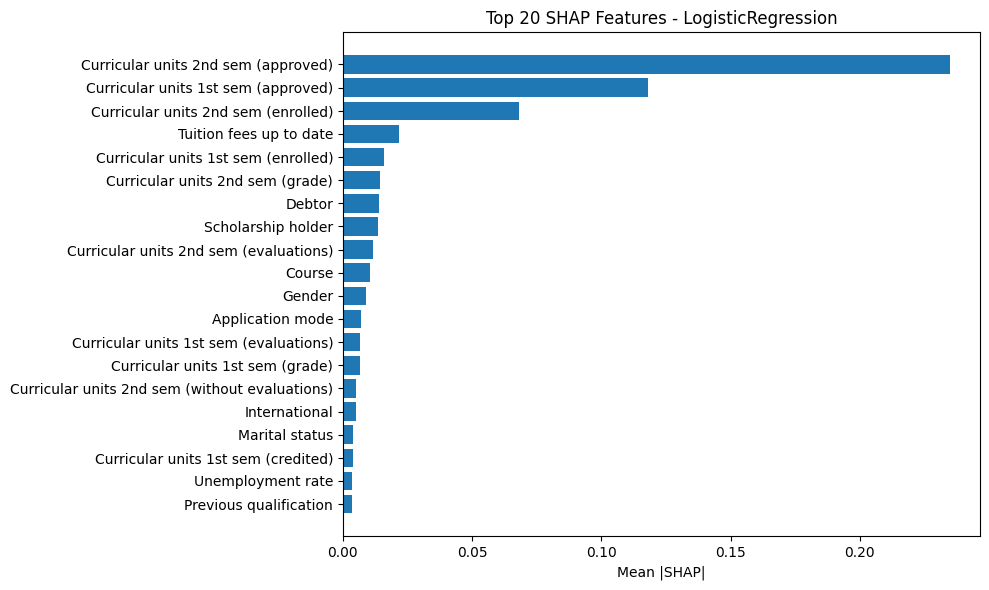

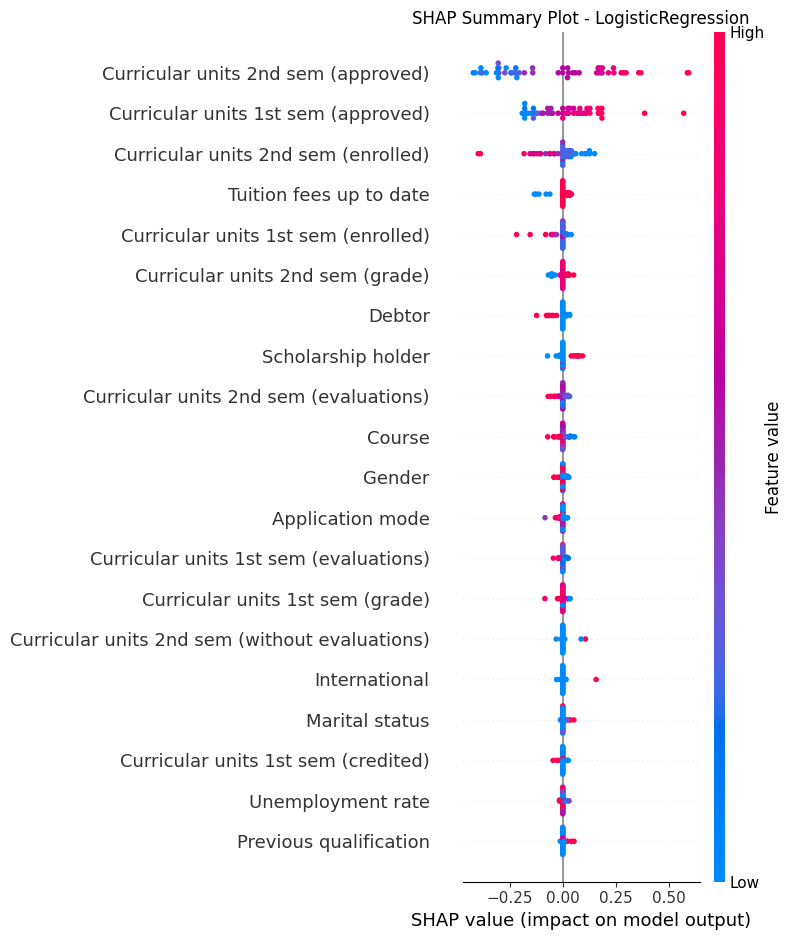

  ✅ SHAP displayed + saved:
     - shap_outputs/LogisticRegression_shap_bar.png
     - shap_outputs/LogisticRegression_shap_summary.png

Running SHAP for: RandomForest


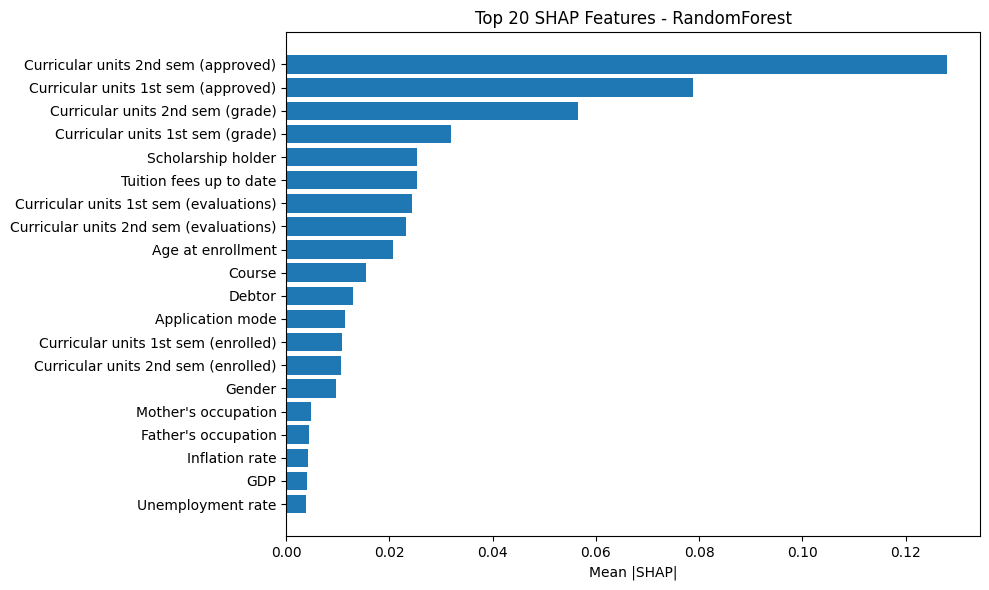

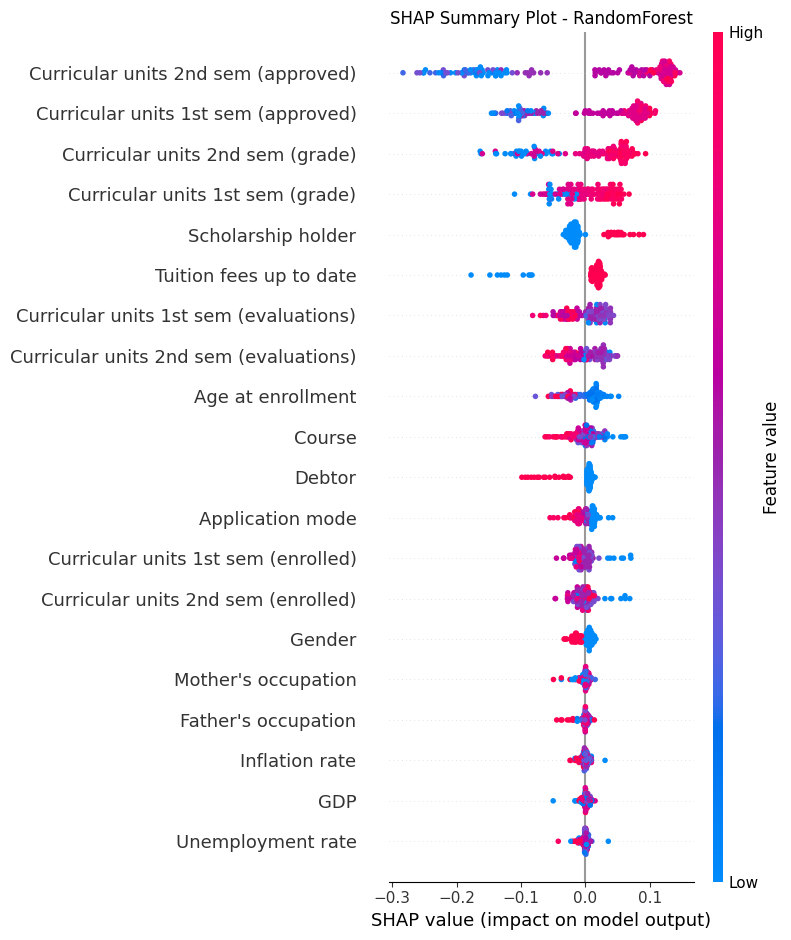

  ✅ SHAP displayed + saved:
     - shap_outputs/RandomForest_shap_bar.png
     - shap_outputs/RandomForest_shap_summary.png

Running SHAP for: HistGB


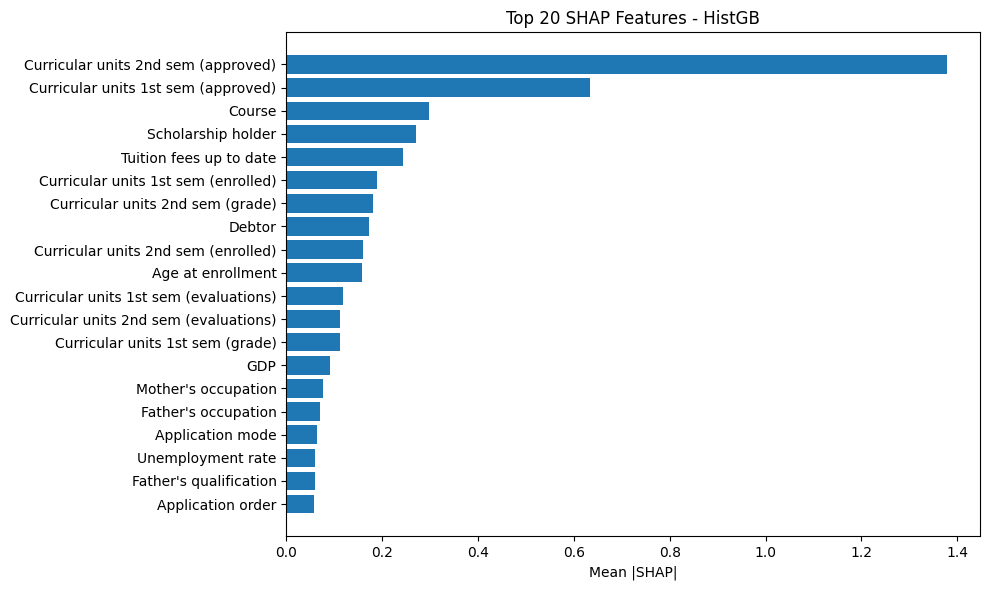

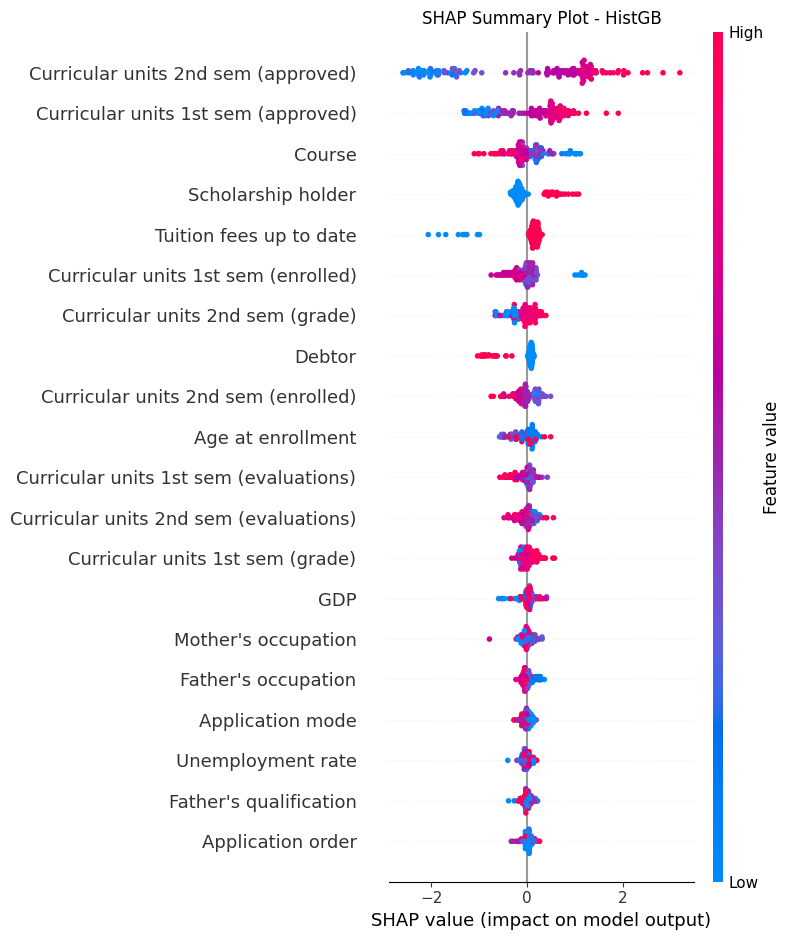

  ✅ SHAP displayed + saved:
     - shap_outputs/HistGB_shap_bar.png
     - shap_outputs/HistGB_shap_summary.png

Running SHAP for: XGBoost


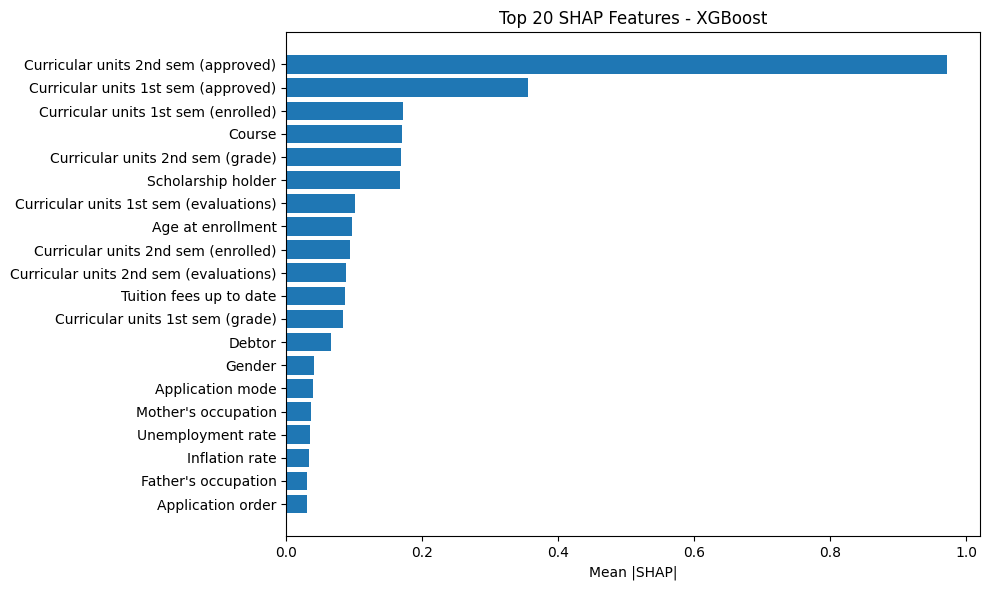

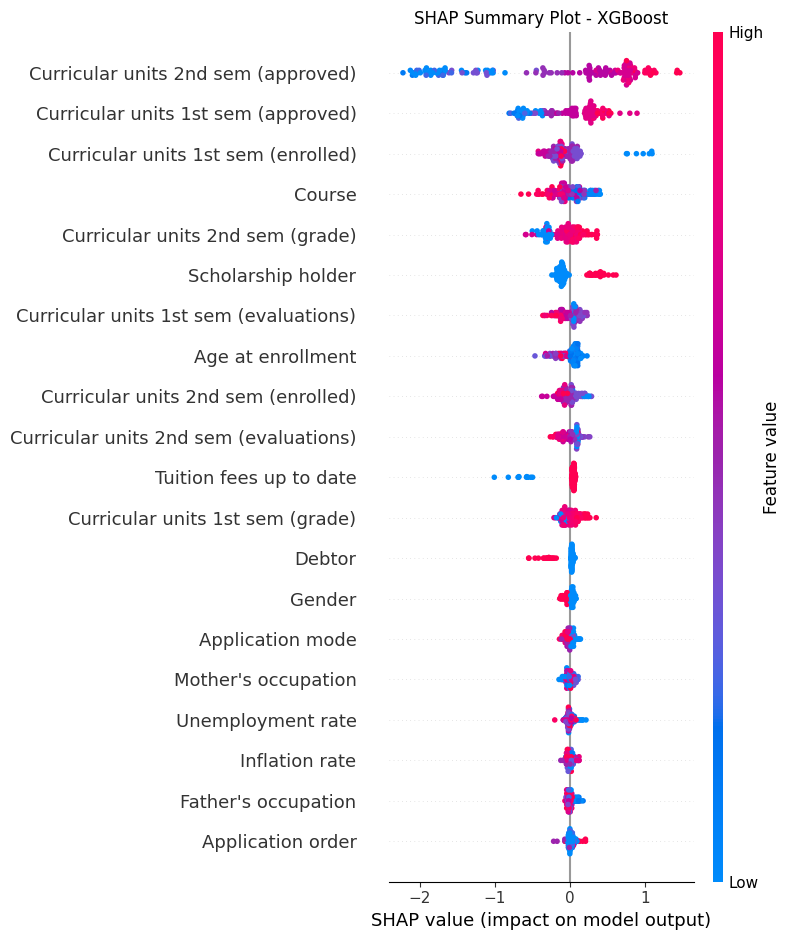

  ✅ SHAP displayed + saved:
     - shap_outputs/XGBoost_shap_bar.png
     - shap_outputs/XGBoost_shap_summary.png

Running SHAP for: LightGBM


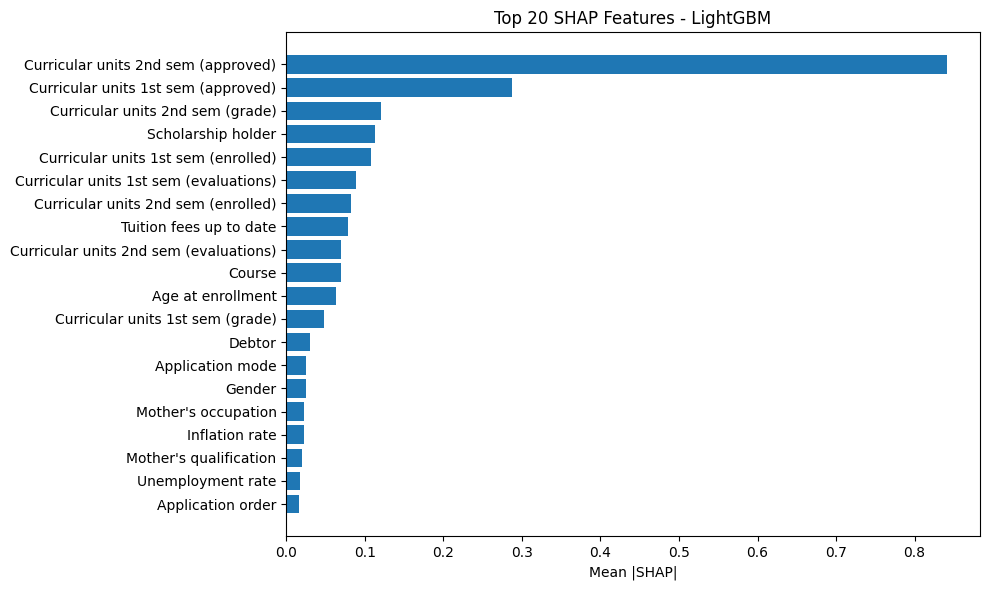

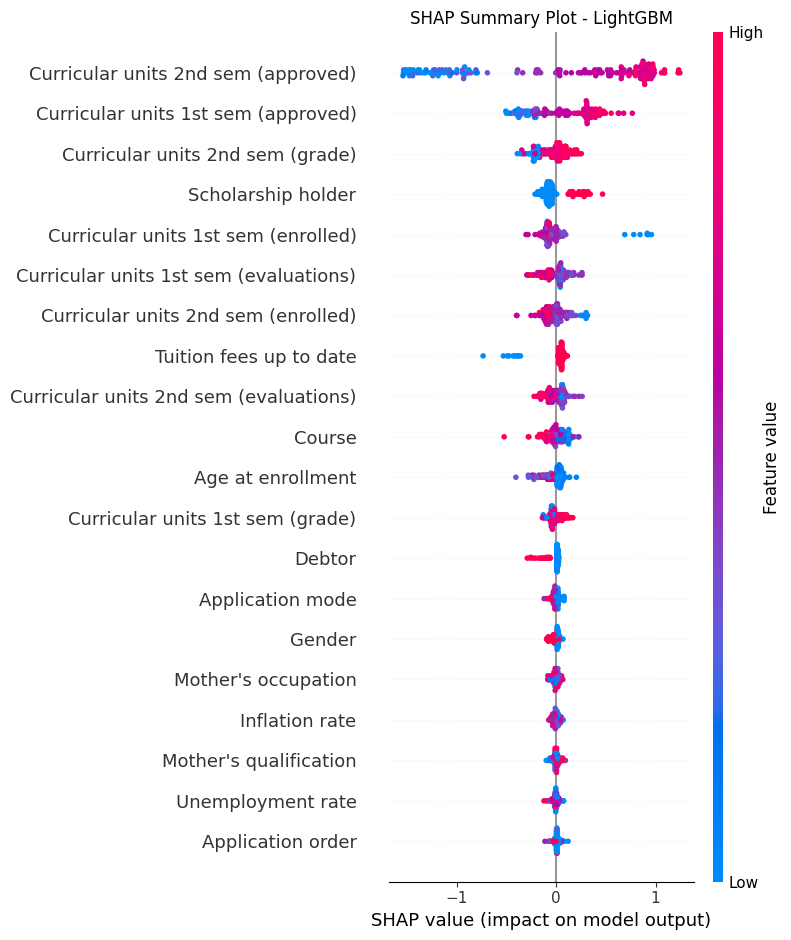

  ✅ SHAP displayed + saved:
     - shap_outputs/LightGBM_shap_bar.png
     - shap_outputs/LightGBM_shap_summary.png

📊 EDUCATIONAL AI READINESS SCORE (per model, 0–5)

Model: LogisticRegression
  Data Quality     : 5.0
  Accuracy         : 3.78
  Interpretability : 1.905
  Scalability      : 4.329
  Fairness         : 0.0
  ✅ Readiness Score: 2.975

Model: RandomForest
  Data Quality     : 5.0
  Accuracy         : 3.881
  Interpretability : 1.211
  Scalability      : 3.649
  Fairness         : 0.0
  ✅ Readiness Score: 2.76

Model: HistGB
  Data Quality     : 5.0
  Accuracy         : 3.825
  Interpretability : 1.156
  Scalability      : 3.756
  Fairness         : 0.0
  ✅ Readiness Score: 2.751

Model: XGBoost
  Data Quality     : 5.0
  Accuracy         : 3.876
  Interpretability : 1.271
  Scalability      : 3.829
  Fairness         : 4.07
  ✅ Readiness Score: 3.611

Model: LightGBM
  Data Quality     : 5.0
  Accuracy         : 3.898
  Interpretability : 1.545
  Scalability      : 3.599


In [ ]:
results_dropout = comprehensive_ml_pipeline(
    dataset_path="retention/dataset.csv",
    target_column="Target",
    task_type="auto",
    fast_mode="auto",
    do_hyperparam_tuning=True,
    compute_shap=True,
    use_tfidf=False
)


LINEAR REGRESSION (Ridge) on Dropout Dataset — tuned
Classes: ['Dropout', 'Enrolled', 'Graduate']
✅ Best Params: {'model__alpha': np.float64(3.727593720314938)}
Classification Accuracy (rounded) = 0.6881
Classification F1 (macro)         = 0.6662
Regression-style R2 (on labels)   = 0.5932
MAE=0.4320 | RMSE=0.3207
TrainTime(s)=1.605 | Inference(ms/sample)=0.0066


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


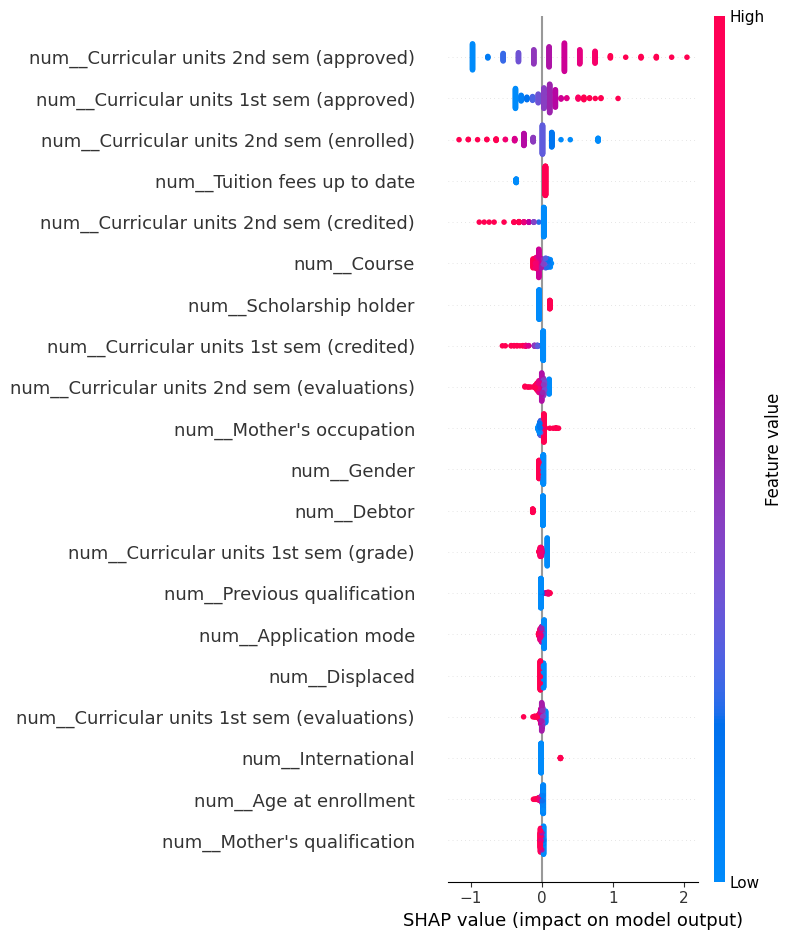

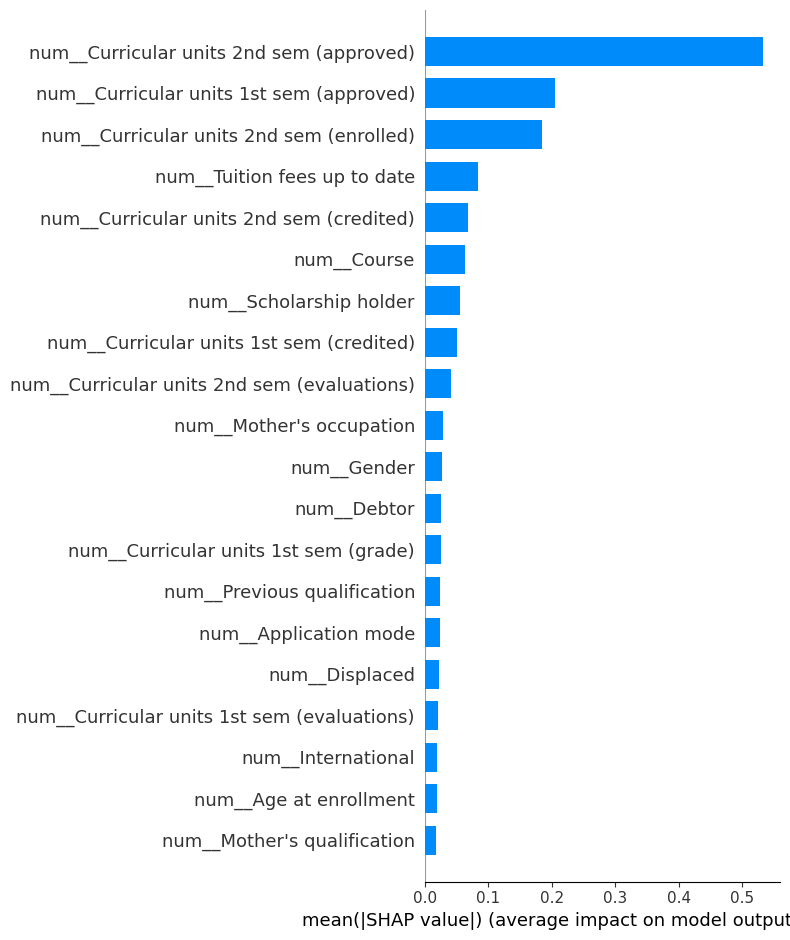


READINESS INDEX (0–5) — Ridge Linear Regression on Dropout Dataset
AccuracyScore(0-5)    : 3.4407
Fairness(0-5)         : 4.1878
Interpretability(0-5) : 1.3648
DataQuality(0-5)      : 5.0000
Scalability(0-5)      : 4.6257
✅ FINAL Readiness(0-5): 3.6645


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score

shap.initjs()

# -----------------------
# Config
# -----------------------
DATASET_PATH = "/content/retention/dataset.csv"
TARGET_COL = "Target"
RANDOM_STATE = 42
SHAP_SAMPLE = 200

# Readiness weights (your requested)
W = {
    "Accuracy": 0.25,
    "Fairness": 0.20,
    "Interpretability": 0.20,
    "DataQuality": 0.20,
    "Scalability": 0.15
}

# -----------------------
# Helpers
# -----------------------
def to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else X

def ms_per_sample(pipeline, X, n=2000):
    Xs = X.iloc[:min(n, len(X))] if hasattr(X, "iloc") else X[:min(n, len(X))]
    t0 = time.time()
    _ = pipeline.predict(Xs)
    dt = time.time() - t0
    return float(1000.0 * dt / max(1, len(Xs)))

def data_quality_score(X_raw: pd.DataFrame) -> float:
    total = X_raw.size
    miss = X_raw.isna().sum().sum()
    missing_ratio = 0.0 if total == 0 else miss / total
    score = 5.0 * (1.0 - min(1.0, 2.0 * missing_ratio))  # 0 if >=50% missing
    return float(np.clip(score, 0.0, 5.0))

def scalability_score(train_time_s: float, infer_ms_per_sample: float) -> float:
    def f_seconds(t_sec: float):
        return float(np.clip(5.0 - np.log10(1.0 + max(0.0, t_sec)) * 1.5, 0.0, 5.0))
    train_component = f_seconds(train_time_s)
    infer_component = f_seconds(infer_ms_per_sample / 1000.0)  # ms -> sec
    return float(0.6 * train_component + 0.4 * infer_component)

def interpretability_score_from_mean_abs(mean_abs: np.ndarray) -> float:
    v = np.abs(np.array(mean_abs, dtype=float))
    s = v.sum()
    if s <= 0:
        return 0.0
    p = v / s
    eps = 1e-12
    entropy = -np.sum(p * np.log(p + eps))
    max_entropy = np.log(len(p) + eps)
    conc = 1.0 - (entropy / max_entropy if max_entropy > 0 else 0.0)
    return float(np.clip(5.0 * conc, 0.0, 5.0))

def fairness_score_from_shap_bins(shap_2d: np.ndarray, preds: np.ndarray, K: int = 4) -> float:
    sv = np.array(shap_2d, dtype=float)
    preds = np.array(preds, dtype=float).reshape(-1)

    n = min(len(preds), sv.shape[0])
    if n < 10:
        return 2.5
    sv = sv[:n]
    preds = preds[:n]

    qs = np.quantile(preds, np.linspace(0, 1, K + 1))
    bins = []
    for k in range(K):
        mask = (preds >= qs[k]) & (preds <= qs[k+1] if k == K-1 else preds < qs[k+1])
        idx = np.where(mask)[0]
        if len(idx) > 0:
            bins.append(idx)

    if len(bins) < 2:
        return 2.5

    mus = [np.mean(np.abs(sv[idx]), axis=0) for idx in bins]

    dsum, cnt = 0.0, 0
    for i in range(len(mus)):
        for j in range(i + 1, len(mus)):
            dsum += float(np.mean(np.abs(mus[i] - mus[j])))
            cnt += 1

    div = dsum / max(1, cnt)
    score = 5.0 * (1.0 / (1.0 + 10.0 * div))
    return float(np.clip(score, 0.0, 5.0))

# “Accuracy score” for readiness: use classification accuracy after rounding
def acc_score_0_5_from_acc(acc: float) -> float:
    return float(np.clip(5.0 * acc, 0.0, 5.0))

# -----------------------
# Load data
# -----------------------
df = pd.read_csv(DATASET_PATH)
df.columns = df.columns.astype(str).str.strip()

if TARGET_COL not in df.columns:
    raise KeyError(f"'{TARGET_COL}' not found. Available: {df.columns.tolist()}")

X = df.drop(columns=[TARGET_COL]).copy()
y_raw = df[TARGET_COL].astype(str)

# Encode classes -> 0..K-1
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Data quality on raw features
dq = data_quality_score(X)

# Preprocess: numeric + categorical (no TF-IDF here)
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# Split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# -----------------------
# Linear Regression model (Ridge) + hyperparam tuning
# -----------------------
pipe = Pipeline([
    ("pre", pre),
    ("model", Ridge(random_state=RANDOM_STATE))
])

param_dist = {
    "model__alpha": np.logspace(-4, 3, 50),  # tuning knob for linear regression family
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=12,
    scoring="neg_mean_squared_error",  # regression-like objective on 0/1/2 labels
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

t0 = time.time()
search.fit(X_tr, y_tr)
train_time = time.time() - t0

best_pipe = search.best_estimator_
best_params = search.best_params_

# Predict “regression outputs” then map to classes by rounding
y_pred_cont = best_pipe.predict(X_te)
y_pred_cls = np.clip(np.rint(y_pred_cont), 0, len(le.classes_) - 1).astype(int)

# Metrics
acc = accuracy_score(y_te, y_pred_cls)
f1m = f1_score(y_te, y_pred_cls, average="macro")

# Also print regression metrics on encoded label values (optional but informative)
r2 = r2_score(y_te, y_pred_cont)
mae = mean_absolute_error(y_te, y_pred_cont)
rmse = mean_squared_error(y_te, y_pred_cont)

infer_ms = ms_per_sample(best_pipe, X_te)

print("\n" + "="*90)
print("LINEAR REGRESSION (Ridge) on Dropout Dataset — tuned")
print("="*90)
print("Classes:", list(le.classes_))
print("✅ Best Params:", best_params)
print(f"Classification Accuracy (rounded) = {acc:.4f}")
print(f"Classification F1 (macro)         = {f1m:.4f}")
print(f"Regression-style R2 (on labels)   = {r2:.4f}")
print(f"MAE={mae:.4f} | RMSE={rmse:.4f}")
print(f"TrainTime(s)={train_time:.3f} | Inference(ms/sample)={infer_ms:.4f}")

# -----------------------
# SHAP feature importance (beeswarm + bar)
# -----------------------
Xt_tr = best_pipe.named_steps["pre"].transform(X_tr)
Xt_te = best_pipe.named_steps["pre"].transform(X_te)

Xt_tr_d = to_dense(Xt_tr)
Xt_te_d = to_dense(Xt_te)

try:
    feat_names = best_pipe.named_steps["pre"].get_feature_names_out()
except Exception:
    feat_names = [f"feature_{i}" for i in range(Xt_te_d.shape[1])]

# Sample for SHAP
rs = np.random.RandomState(RANDOM_STATE)
idx = rs.choice(Xt_te_d.shape[0], size=min(SHAP_SAMPLE, Xt_te_d.shape[0]), replace=False)
Xt_te_s = Xt_te_d[idx]

# LinearExplainer for linear models
expl = shap.LinearExplainer(best_pipe.named_steps["model"], Xt_tr_d, feature_perturbation="interventional")
sv = expl.shap_values(Xt_te_s)  # (n, p)

# Beeswarm plot
plt.figure()
shap.summary_plot(sv, Xt_te_s, feature_names=feat_names, show=False)
plt.tight_layout()
plt.show()

# Bar plot (feature importance)
plt.figure()
shap.summary_plot(sv, Xt_te_s, feature_names=feat_names, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# -----------------------
# Readiness index (0–5)
#   Accuracy: from classification accuracy (rounded)
#   Fairness/Interpretability: from SHAP
#   DataQuality: missingness on X
#   Scalability: train + inference
# -----------------------
mean_abs = np.mean(np.abs(sv), axis=0)
interp = interpretability_score_from_mean_abs(mean_abs)

# fairness bins use predicted continuous values for binning
preds_s = best_pipe.named_steps["model"].predict(Xt_te_s)
fair = fairness_score_from_shap_bins(sv, preds_s, K=4)

acc05 = acc_score_0_5_from_acc(acc)
sc = scalability_score(train_time, infer_ms)

readiness = (
    W["Accuracy"] * acc05 +
    W["Fairness"] * fair +
    W["Interpretability"] * interp +
    W["DataQuality"] * dq +
    W["Scalability"] * sc
)

print("\n" + "="*90)
print("READINESS INDEX (0–5) — Ridge Linear Regression on Dropout Dataset")
print("="*90)
print(f"AccuracyScore(0-5)    : {acc05:.4f}")
print(f"Fairness(0-5)         : {fair:.4f}")
print(f"Interpretability(0-5) : {interp:.4f}")
print(f"DataQuality(0-5)      : {dq:.4f}")
print(f"Scalability(0-5)      : {sc:.4f}")
print(f"✅ FINAL Readiness(0-5): {readiness:.4f}")


In [ ]:
# generic_accuracy_calculator.py
import time
import numpy as np
import pandas as pd
from typing import Dict, Any, Optional, List, Tuple

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor

# Optional models
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False


# -----------------------------
# Task detection
# -----------------------------
def detect_task_type(y: pd.Series) -> str:
    if y.dtype == "O" or str(y.dtype).startswith("category") or y.dtype == bool:
        return "Classification"
    nunique = y.nunique(dropna=True)
    if pd.api.types.is_integer_dtype(y) and nunique <= 20:
        return "Classification"
    return "Regression"


# -----------------------------
# Preprocessor
# -----------------------------
def build_preprocessor(X: pd.DataFrame) -> Tuple[ColumnTransformer, List[str], List[str]]:
    num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    cat_cols = [c for c in X.columns if c not in num_cols]

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),  # produces sparse by default
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
    )
    return pre, num_cols, cat_cols


def preprocess_data(
    df: pd.DataFrame,
    target_column: str,
    task_type: str = "auto",
    feature_columns: Optional[List[str]] = None,
    test_size: float = 0.2,
    random_state: int = 42,
):
    df = df.copy()
    # remove accidental index columns
    df = df.loc[:, ~df.columns.astype(str).str.match(r"^Unnamed")]

    # Strip column names to avoid "Value " vs "Value" issues
    df.columns = df.columns.astype(str).str.strip()

    if target_column not in df.columns:
        raise KeyError(f"target_column='{target_column}' not found. Available columns: {df.columns.tolist()}")

    X = df.drop(columns=[target_column]) if feature_columns is None else df[feature_columns]
    y = df[target_column]

    detected = detect_task_type(y) if task_type == "auto" else task_type

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    preprocessor, num_cols, cat_cols = build_preprocessor(X_train)

    return {
        "task_type": detected,
        "X_train_raw": X_train,
        "X_test_raw": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "preprocessor": preprocessor,
        "num_cols": num_cols,
        "cat_cols": cat_cols,
    }


# -----------------------------
# Models
# -----------------------------
def get_base_models(task_type: str) -> Dict[str, Any]:
    if task_type == "Regression":
        models = {
            "LinearRegression": LinearRegression(),
            "RandomForest": RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1),
            "HistGB": HistGradientBoostingRegressor(random_state=42),
        }
        if XGB_AVAILABLE:
            models["XGBoost"] = xgb.XGBRegressor(
                random_state=42,
                n_estimators=300,
                max_depth=4,
                learning_rate=0.08,
                subsample=0.9,
                colsample_bytree=0.9,
            )
        if LGB_AVAILABLE:
            models["LightGBM"] = lgb.LGBMRegressor(
                random_state=42,
                n_estimators=400,
                learning_rate=0.06,
            )
        return models

    # Classification
    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="auto"),
        "RandomForest": RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1),
        "HistGB": HistGradientBoostingClassifier(random_state=42),
    }
    if XGB_AVAILABLE:
        models["XGBoost"] = xgb.XGBClassifier(
            random_state=42,
            n_estimators=300,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
        )
    if LGB_AVAILABLE:
        models["LightGBM"] = lgb.LGBMClassifier(
            random_state=42,
            n_estimators=400,
            learning_rate=0.06,
        )
    return models


def get_search_spaces(task_type: str) -> Dict[str, Dict[str, List[Any]]]:
    if task_type == "Regression":
        spaces = {
            "RandomForest": {
                "model__n_estimators": [200, 400, 800],
                "model__max_depth": [None, 8, 12, 20],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
            },
            "HistGB": {
                "model__max_depth": [None, 6, 10],
                "model__learning_rate": [0.03, 0.06, 0.1],
                "model__max_iter": [200, 400, 800],
                "model__min_samples_leaf": [10, 20, 50],
            },
        }
        if XGB_AVAILABLE:
            spaces["XGBoost"] = {
                "model__n_estimators": [200, 300, 500],
                "model__max_depth": [3, 4, 6],
                "model__learning_rate": [0.03, 0.06, 0.1],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
            }
        if LGB_AVAILABLE:
            spaces["LightGBM"] = {
                "model__n_estimators": [200, 400, 800],
                "model__num_leaves": [31, 63, 127],
                "model__learning_rate": [0.03, 0.06, 0.1],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
            }
        return spaces

    # Classification
    spaces = {
        "LogisticRegression": {
            "model__C": [0.01, 0.1, 1.0, 3.0, 10.0],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs", "saga"],
        },
        "RandomForest": {
            "model__n_estimators": [200, 400, 800],
            "model__max_depth": [None, 8, 12, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
        },
        "HistGB": {
            "model__max_depth": [None, 6, 10],
            "model__learning_rate": [0.03, 0.06, 0.1],
            "model__max_iter": [200, 400, 800],
            "model__min_samples_leaf": [10, 20, 50],
        },
    }
    if XGB_AVAILABLE:
        spaces["XGBoost"] = {
            "model__n_estimators": [200, 300, 500],
            "model__max_depth": [3, 4, 6],
            "model__learning_rate": [0.03, 0.06, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
        }
    if LGB_AVAILABLE:
        spaces["LightGBM"] = {
            "model__n_estimators": [200, 400, 800],
            "model__num_leaves": [31, 63, 127],
            "model__learning_rate": [0.03, 0.06, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
        }
    return spaces


# -----------------------------
# Metrics
# -----------------------------
def safe_mape(y_true, y_pred) -> float:
    y_true = np.array(y_true).astype(float)
    y_pred = np.array(y_pred).astype(float)
    mask = (y_true != 0)
    if mask.sum() == 0:
        return float("nan")
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)


def calculate_all_metrics(y_true, y_pred, task_type: str) -> Dict[str, float]:
    out = {}
    if task_type == "Regression":
        y_true_f = np.array(y_true).astype(float)
        y_pred_f = np.array(y_pred).astype(float)
        out["MAE"] = float(mean_absolute_error(y_true_f, y_pred_f))
        out["RMSE"] = float(mean_squared_error(y_true_f, y_pred_f))
        out["MAPE"] = float(safe_mape(y_true_f, y_pred_f))
        out["R2"] = float(r2_score(y_true_f, y_pred_f))
        return out

    # Classification
    out["Accuracy"] = float(accuracy_score(y_true, y_pred))
    out["F1"] = float(f1_score(y_true, y_pred, average="weighted"))
    out["Precision"] = float(precision_score(y_true, y_pred, average="weighted", zero_division=0))
    out["Recall"] = float(recall_score(y_true, y_pred, average="weighted", zero_division=0))

    # Optional numeric-error metrics on encoded labels (requested previously)
    y_true_s = pd.Series(y_true)
    y_pred_s = pd.Series(y_pred)
    if y_true_s.dtype == "O" or str(y_true_s.dtype).startswith("category"):
        all_cats = pd.Index(pd.unique(y_true_s.astype(str)))
        map_ = {k: i for i, k in enumerate(all_cats)}
        yt = y_true_s.astype(str).map(map_).astype(float).values
        yp = y_pred_s.astype(str).map(map_).fillna(0).astype(float).values
    else:
        yt = y_true_s.astype(float).values
        yp = y_pred_s.astype(float).values

    out["MAE"] = float(mean_absolute_error(yt, yp))
    out["RMSE"] = float(mean_squared_error(yt, yp))
    out["MAPE"] = float(safe_mape(yt, yp))
    return out


# -----------------------------
# Dense converter (fix for HistGB)
# -----------------------------
def _to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else X


# -----------------------------
# Train baseline + tuned
# -----------------------------
def train_and_evaluate_models(
    X_train_raw: pd.DataFrame,
    X_test_raw: pd.DataFrame,
    y_train,
    y_test,
    preprocessor: ColumnTransformer,
    task_type: str,
    do_hyperparam_tuning: bool = True,
    tuning_n_iter: int = 4,
    tuning_cv: int = 2,
    model_names: Optional[List[str]] = None,
) -> Dict[str, Any]:

    base_models = get_base_models(task_type)
    if model_names is not None:
        base_models = {k: v for k, v in base_models.items() if k in set(model_names)}

    spaces = get_search_spaces(task_type)

    results = {
        "baseline": {},
        "tuned": {},
        "best_params": {},
        "best_cv": {},
        "pipelines": {},
    }

    for name, model in base_models.items():

        # ✅ IMPORTANT FIX:
        # HistGradientBoosting models require dense inputs
        force_dense = (name == "HistGB") or ("HistGradientBoosting" in model.__class__.__name__)

        steps = [("preprocess", preprocessor)]
        if force_dense:
            steps.append(("to_dense", FunctionTransformer(_to_dense, validate=False, accept_sparse=True)))
        steps.append(("model", model))
        pipe = Pipeline(steps=steps)

        # baseline fit
        t0 = time.time()
        pipe.fit(X_train_raw, y_train)
        train_time = time.time() - t0

        # inference timing
        t1 = time.time()
        y_pred = pipe.predict(X_test_raw)
        infer_time = (time.time() - t1) / max(1, len(X_test_raw)) * 1000.0  # ms/sample

        m = calculate_all_metrics(y_test, y_pred, task_type)
        m["TrainTime(s)"] = float(train_time)
        m["Inference(ms/sample)"] = float(infer_time)
        results["baseline"][name] = m

        # tuning
        if do_hyperparam_tuning and name in spaces:
            scoring = "r2" if task_type == "Regression" else "accuracy"
            search = RandomizedSearchCV(
                pipe,
                param_distributions=spaces[name],
                n_iter=tuning_n_iter,
                cv=tuning_cv,
                scoring=scoring,
                n_jobs=-1,
                random_state=42,
                verbose=0,
            )
            t0 = time.time()
            search.fit(X_train_raw, y_train)
            tuned_pipe = search.best_estimator_
            tuned_train_time = time.time() - t0

            t1 = time.time()
            y_pred2 = tuned_pipe.predict(X_test_raw)
            tuned_infer_time = (time.time() - t1) / max(1, len(X_test_raw)) * 1000.0

            m2 = calculate_all_metrics(y_test, y_pred2, task_type)
            m2["TrainTime(s)"] = float(tuned_train_time)
            m2["Inference(ms/sample)"] = float(tuned_infer_time)

            results["tuned"][name] = m2
            results["best_params"][name] = search.best_params_
            results["best_cv"][name] = float(search.best_score_)
            results["pipelines"][name] = tuned_pipe
        else:
            results["tuned"][name] = results["baseline"][name]
            results["best_params"][name] = None
            results["best_cv"][name] = None
            results["pipelines"][name] = pipe

    return results


In [ ]:
# vertexML.py
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

shap.initjs()

from typing import Optional, Dict, Any, List

# from generic_accuracy_calculator import (
#     preprocess_data,
#     train_and_evaluate_models,
# )

READINESS_WEIGHTS_DEFAULT = {
    "Accuracy": 0.25,
    "Fairness": 0.20,
    "Interpretability": 0.20,
    "DataQuality": 0.20,
    "Scalability": 0.15,
}

def data_quality_score(X_raw: pd.DataFrame) -> float:
    total = X_raw.size
    miss = X_raw.isna().sum().sum()
    missing_ratio = 0.0 if total == 0 else miss / total
    score = 5.0 * (1.0 - min(1.0, 2.0 * missing_ratio))
    return float(max(0.0, min(5.0, score)))

def interpretability_score_from_shap(mean_abs_vals: np.ndarray) -> float:
    v = np.array(mean_abs_vals, dtype=float)
    v = np.abs(v)
    s = v.sum()
    if s <= 0:
        return 0.0
    p = v / s
    eps = 1e-12
    entropy = -np.sum(p * np.log(p + eps))
    max_entropy = np.log(len(p) + eps)
    conc = 1.0 - (entropy / max_entropy if max_entropy > 0 else 0.0)
    return float(max(0.0, min(5.0, 5.0 * conc)))

def fairness_score_from_shap_bins(shap_2d: np.ndarray, preds: np.ndarray, K: int = 4) -> float:
    sv = np.array(shap_2d, dtype=float)
    preds = np.array(preds).reshape(-1)

    # ✅ align lengths (SHAP often uses a sample, preds might be full test)
    n = min(len(preds), sv.shape[0])
    if n < 10:
        return 2.5

    sv = sv[:n]
    preds = preds[:n]

    # quantile bins on aligned preds
    qs = np.quantile(preds, np.linspace(0, 1, K + 1))
    bins = []
    for k in range(K):
        mask = (preds >= qs[k]) & (preds <= qs[k+1] if k == K-1 else preds < qs[k+1])
        idx = np.where(mask)[0]
        if len(idx) > 0:
            bins.append(idx)

    if len(bins) < 2:
        return 2.5

    mus = [np.mean(np.abs(sv[idx]), axis=0) for idx in bins]

    dsum = 0.0
    cnt = 0
    for i in range(len(mus)):
        for j in range(i + 1, len(mus)):
            dsum += float(np.mean(np.abs(mus[i] - mus[j])))
            cnt += 1

    div = dsum / max(1, cnt)
    score = 5.0 * (1.0 / (1.0 + 10.0 * div))
    return float(max(0.0, min(5.0, score)))


def scalability_score(train_time_s: float, infer_ms_per_sample: float) -> float:
    def f(t):
        return float(max(0.0, min(5.0, 5.0 - np.log10(1.0 + max(0.0, t)) * 1.5)))
    train_component = f(train_time_s)
    infer_component = f(infer_ms_per_sample / 1000.0)
    return float(0.6 * train_component + 0.4 * infer_component)

def _shap_to_2d(shap_values, task_type: str):
    if isinstance(shap_values, list):
        arrs = [np.array(a) for a in shap_values if a is not None]
        if len(arrs) == 0:
            return None
        arrs2 = []
        for a in arrs:
            if a.ndim == 2:
                arrs2.append(a)
            elif a.ndim == 3:
                arrs2.append(a[:, :, -1])
            else:
                arrs2.append(a.reshape(a.shape[0], -1))
        if len(arrs2) == 2 and task_type != "Regression":
            return arrs2[1]
        return np.mean(np.stack(arrs2, axis=2), axis=2)

    sv = np.array(shap_values)
    if sv.ndim == 3:
        if task_type != "Regression" and sv.shape[2] >= 2:
            return sv[:, :, -1]
        return np.mean(sv, axis=2)
    if sv.ndim == 2:
        return sv
    if sv.ndim == 1:
        return sv.reshape(-1, 1)
    return None

def _base_feature_name(n: str) -> str:
    n = str(n)
    for pref in ("num__", "cat__", "remainder__", "num_", "cat_"):
        if n.startswith(pref):
            n = n[len(pref):]
    if "_" in n:
        return n.split("_", 1)[0]
    return n

def perform_shap_analysis_pipeline_model(
    trained_pipeline,
    X_train_raw: pd.DataFrame,
    X_test_raw: pd.DataFrame,
    model_name: str,
    task_type: str,
    shap_out_dir: str = "shap_outputs",
    shap_sample_size: int = 200,
):
    os.makedirs(shap_out_dir, exist_ok=True)
    print(f"\nRunning SHAP for: {model_name}\n")

    try:
        X_test_s = X_test_raw.sample(n=min(shap_sample_size, len(X_test_raw)), random_state=42).copy()
        X_train_s = X_train_raw.sample(n=min(200, len(X_train_raw)), random_state=42).copy()

        est = trained_pipeline.named_steps["model"]
        pre = trained_pipeline.named_steps["preprocess"]

        # Tree models -> TreeExplainer
        is_tree = any(t in est.__class__.__name__ for t in ["RandomForest", "XGB", "LGBM"])
        # HistGB often fails with TreeExplainer, use fallback explainer for it
        if "HistGradientBoosting" in est.__class__.__name__:
            is_tree = False

        if is_tree:
            Xt = pre.transform(X_test_s)
            Xt_dense = Xt.toarray() if hasattr(Xt, "toarray") else Xt

            explainer = shap.TreeExplainer(est)
            shap_values = explainer.shap_values(Xt_dense, check_additivity=False)
            sv_plot = _shap_to_2d(shap_values, task_type)
            if sv_plot is None:
                raise ValueError("Unsupported SHAP shape")

            try:
                feat_names = pre.get_feature_names_out()
            except Exception:
                feat_names = [f"feature_{i}" for i in range(sv_plot.shape[1])]
            base_names = [_base_feature_name(n) for n in feat_names]

            plt.figure()
            shap.summary_plot(sv_plot, features=Xt_dense, feature_names=base_names, show=False)
            plt.tight_layout()
            plt.savefig(os.path.join(shap_out_dir, f"shap_{model_name}_summary.png"), dpi=200, bbox_inches="tight")
            plt.show()

        else:
            Xt_test = pre.transform(X_test_s)
            Xt_train = pre.transform(X_train_s)

            Xt_test_dense = Xt_test.toarray() if hasattr(Xt_test, "toarray") else Xt_test
            Xt_train_dense = Xt_train.toarray() if hasattr(Xt_train, "toarray") else Xt_train

    # Try to get feature names from preprocessor
            try:
                feat_names = pre.get_feature_names_out()
            except Exception:
                feat_names = [f"feature_{i}" for i in range(Xt_test_dense.shape[1])]

            base_names = [_base_feature_name(n) for n in feat_names]

            f = est.predict_proba if (task_type != "Regression" and hasattr(est, "predict_proba")) else est.predict
            masker = shap.maskers.Independent(Xt_train_dense)
            explainer = shap.Explainer(f, masker)
            exp = explainer(Xt_test_dense)

            sv_plot = _shap_to_2d(exp.values, task_type)
            if sv_plot is None:
                raise ValueError("Unsupported SHAP shape")

            # Fallback explainer for LogisticRegression + HistGB + any unsupported model
            # f = trained_pipeline.predict_proba if (task_type != "Regression" and hasattr(trained_pipeline, "predict_proba")) else trained_pipeline.predict
            # masker = shap.maskers.Independent(X_train_s)
            # explainer = shap.Explainer(f, masker)
            # exp = explainer(X_test_s)

            # sv_plot = _shap_to_2d(exp.values, task_type)
            # if sv_plot is None:
            #     raise ValueError("Unsupported SHAP shape")
            # base_names = list(X_test_s.columns)

        mean_abs = np.mean(np.abs(sv_plot), axis=0)
        if getattr(mean_abs, "ndim", 1) != 1:
            mean_abs = np.mean(mean_abs, axis=-1)

        agg = {}
        for n, v in zip(base_names, mean_abs):
            b = _base_feature_name(n)
            if str(b).startswith("Unnamed"):
                continue
            agg[b] = agg.get(b, 0.0) + float(v)

        top = sorted(agg.items(), key=lambda kv: kv[1], reverse=True)[:20]
        top_names = [k for k, _ in top][::-1]
        top_vals = [v for _, v in top][::-1]

        plt.figure()
        plt.barh(top_names, top_vals)
        plt.title(f"Top 20 SHAP Features (aggregated) - {model_name}")
        plt.xlabel("Mean(|SHAP value|)")
        plt.tight_layout()
        plt.savefig(os.path.join(shap_out_dir, f"shap_{model_name}_bar.png"), dpi=200, bbox_inches="tight")
        plt.show()

        return {"shap_2d": sv_plot, "mean_abs": mean_abs, "top_features": top}

    except Exception as e:
        print(f"  ⚠️ SHAP failed: {e}")
        return None


def _print_before_after(model_name: str, before: Dict[str, Any], after: Dict[str, Any], best_params, best_cv):
    print(f"\nModel: {model_name}")

    if "Accuracy" in before:
        print(f"  Accuracy : {before.get('Accuracy')}  ->  {after.get('Accuracy')}")
        print(f"  F1       : {before.get('F1')}  ->  {after.get('F1')}")
    else:
        print(f"  R2   : {before.get('R2')}  ->  {after.get('R2')}")
        print(f"  MAE  : {before.get('MAE')} ->  {after.get('MAE')}")
        print(f"  RMSE : {before.get('RMSE')} ->  {after.get('RMSE')}")
        print(f"  MAPE : {before.get('MAPE')} ->  {after.get('MAPE')}")

    print(f"  TrainTime(s): {before.get('TrainTime(s)')} -> {after.get('TrainTime(s)')}")
    print(f"  Inference(ms/sample): {before.get('Inference(ms/sample)')} -> {after.get('Inference(ms/sample)')}")

    if best_params is not None:
        print(f"  ✅ Best Params : {best_params}")
        print(f"  ✅ Best CV     : {best_cv}")


def comprehensive_ml_pipeline(
    dataset_path,
    target_column,
    task_type="auto",
    demographic_column=None,
    readiness_sub_weights=None,
    do_hyperparam_tuning=True,
    compute_shap=True,
    use_tfidf=False,
    tuning_n_iter: int = 4,
    tuning_cv: int = 2,
    model_names: Optional[List[str]] = None,
    shap_sample_size: int = 200,
    fast_mode: str = "auto",
    feature_columns=None,
    max_tfidf_features: int = 10000,
    shap_out_dir: str = "shap_outputs",
):
    print("\n" + "="*90)
    print("COMPREHENSIVE ML PIPELINE")
    print("="*90)

    df = pd.read_csv(dataset_path) if isinstance(dataset_path, str) else dataset_path.copy()
    df = df.loc[:, ~df.columns.astype(str).str.match(r"^Unnamed")]
    df.columns = df.columns.astype(str).str.strip()

    prep = preprocess_data(df, target_column, task_type, feature_columns)
    detected_task = prep["task_type"]
    X_train_raw = prep["X_train_raw"]
    X_test_raw = prep["X_test_raw"]
    y_train = prep["y_train"]
    y_test = prep["y_test"]
    preprocessor = prep["preprocessor"]

    print(f"\nTask type detected: {detected_task}")
    print(f"Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")

    # Fast mode: keep LogisticRegression for classification
    if model_names is None and fast_mode in ("auto", "always"):
        big = (len(df) > 20000) or (X_train_raw.shape[1] > 150)
        if big:
            if detected_task == "Classification":
                model_names = ["LogisticRegression", "HistGB", "LightGBM"]
            else:
                model_names = ["HistGB", "LightGBM"]

    train_res = train_and_evaluate_models(
        X_train_raw=X_train_raw,
        X_test_raw=X_test_raw,
        y_train=y_train,
        y_test=y_test,
        preprocessor=preprocessor,
        task_type=detected_task,
        do_hyperparam_tuning=do_hyperparam_tuning,
        tuning_n_iter=tuning_n_iter,
        tuning_cv=tuning_cv,
        model_names=model_names,
    )

    print("\n" + "="*90)
    print("📌 BEFORE vs AFTER Hyperparameter Tuning (per model)")
    print("="*90)

    for mname in train_res["baseline"].keys():
        _print_before_after(
            mname,
            train_res["baseline"][mname],
            train_res["tuned"][mname],
            train_res["best_params"].get(mname),
            train_res["best_cv"].get(mname),
        )

    shap_results = {}
    readiness = {}

    X_all_raw = df.drop(columns=[target_column]) if feature_columns is None else df[feature_columns]
    dq = data_quality_score(X_all_raw)

    for mname, pipe in train_res["pipelines"].items():
        shap_res = None
        interp = 2.5
        fair = 2.5

        if compute_shap:
            shap_res = perform_shap_analysis_pipeline_model(
                trained_pipeline=pipe,
                X_train_raw=X_train_raw,
                X_test_raw=X_test_raw,
                model_name=mname,
                task_type=detected_task,
                shap_out_dir=shap_out_dir,
                shap_sample_size=shap_sample_size,
            )
            shap_results[mname] = shap_res
            if shap_res is not None:
                interp = interpretability_score_from_shap(shap_res["mean_abs"])
                preds = pipe.predict(X_test_raw)
                try:
                    preds = np.array(preds, dtype=float)
                except Exception:
                    preds = pd.Series(preds).astype("category").cat.codes.values.astype(float)
                fair = fairness_score_from_shap_bins(shap_res["shap_2d"], preds, K=4)

        tuned_metrics = train_res["tuned"][mname]
        if detected_task == "Regression":
            acc_component = tuned_metrics.get("R2", 0.0)
            acc_score = float(max(0.0, min(5.0, 5.0 * max(0.0, acc_component))))
        else:
            acc_component = tuned_metrics.get("Accuracy", 0.0)
            acc_score = float(max(0.0, min(5.0, 5.0 * acc_component)))

        sc = scalability_score(
            tuned_metrics.get("TrainTime(s)", 0.0),
            tuned_metrics.get("Inference(ms/sample)", 0.0),
        )

        w = READINESS_WEIGHTS_DEFAULT if readiness_sub_weights is None else readiness_sub_weights
        final = (
            w["Accuracy"] * acc_score
            + w["Fairness"] * fair
            + w["Interpretability"] * interp
            + w["DataQuality"] * dq
            + w["Scalability"] * sc
        )

        readiness[mname] = {
            "AccuracyScore(0-5)": acc_score,
            "Fairness(0-5)": float(fair),
            "Interpretability(0-5)": float(interp),
            "DataQuality(0-5)": float(dq),
            "Scalability(0-5)": float(sc),
            "Readiness(0-5)": float(final),
        }


    print("\n" + "="*90)
    print("📊 READINESS SCORE (0–5) PER MODEL — factor breakdown")
    print("="*90)

    w = READINESS_WEIGHTS_DEFAULT if readiness_sub_weights is None else readiness_sub_weights
    print("\nWeights used:")
    for k, v in w.items():
        print(f"  {k}: {v}")


    for mname, r in readiness.items():
        print(f"\nModel: {mname}")
        print(f"  AccuracyScore(0-5)      : {r.get('AccuracyScore(0-5)'):.4f}")
        print(f"  Fairness(0-5)           : {r.get('Fairness(0-5)'):.4f}")
        print(f"  Interpretability(0-5)   : {r.get('Interpretability(0-5)'):.4f}")
        print(f"  DataQuality(0-5)        : {r.get('DataQuality(0-5)'):.4f}")
        print(f"  Scalability(0-5)        : {r.get('Scalability(0-5)'):.4f}")
        print(f"  ✅ FINAL Readiness(0-5)  : {r.get('Readiness(0-5)'):.4f}")


    return {
        "task_type_detected": detected_task,
        "metrics_baseline": train_res["baseline"],
        "metrics_tuned": train_res["tuned"],
        "best_params": train_res["best_params"],
        "best_cv": train_res["best_cv"],
        "models_used": list(train_res["tuned"].keys()),
        "shap": shap_results,
        "readiness": readiness,
    }


In [ ]:
%matplotlib inline


COMPREHENSIVE ML PIPELINE

Task type detected: Regression
Train shape: (5285, 19), Test shape: (1322, 19)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 227
[LightGBM] [Info] Number of data points in the train set: 5285, number of used features: 40
[LightGBM] [Info] Start training from score 67.215137
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 227
[LightGBM] [Info] Number of data points in the train set: 5285, number of used features: 40
[LightGBM] [Info] Start training from score 67.215137

📌 BEFORE vs AFTER Hyperparameter Tuning (per model)

Model: LinearRegression
  R2 

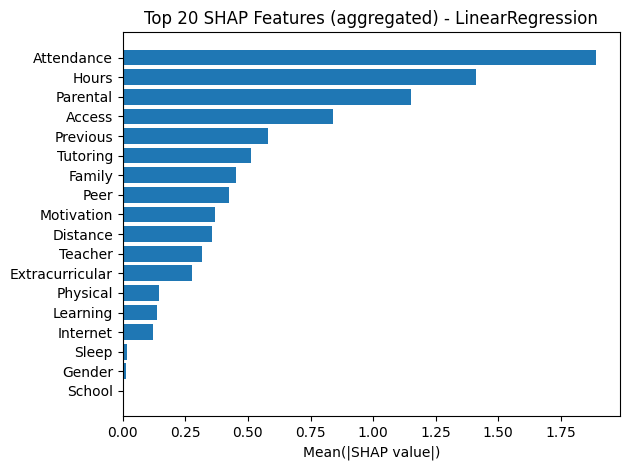


Running SHAP for: RandomForest



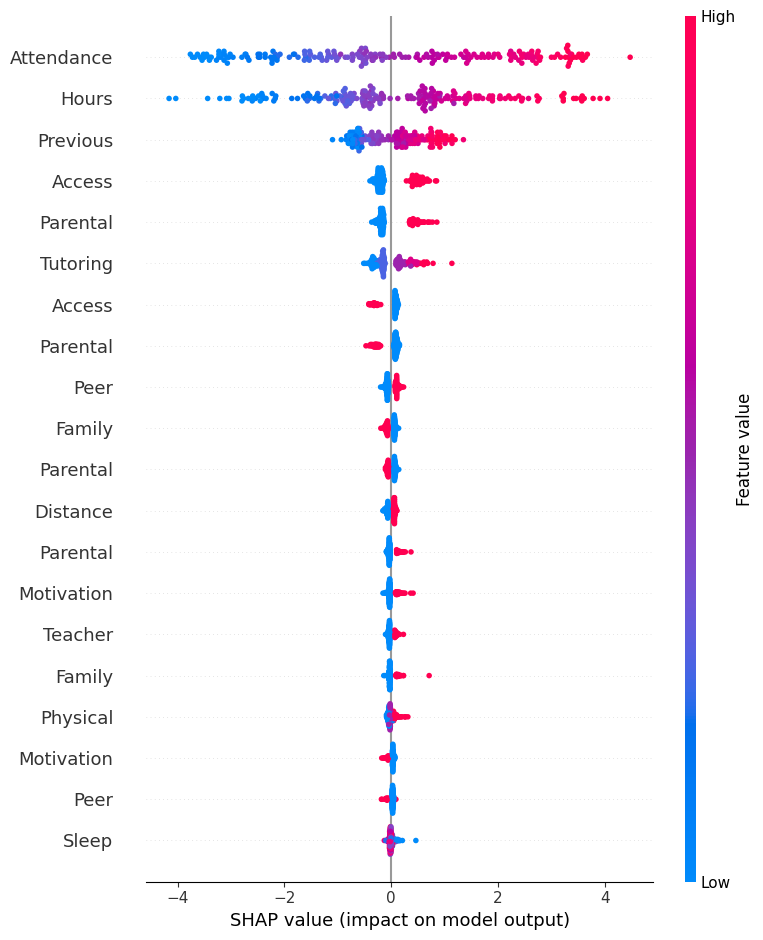

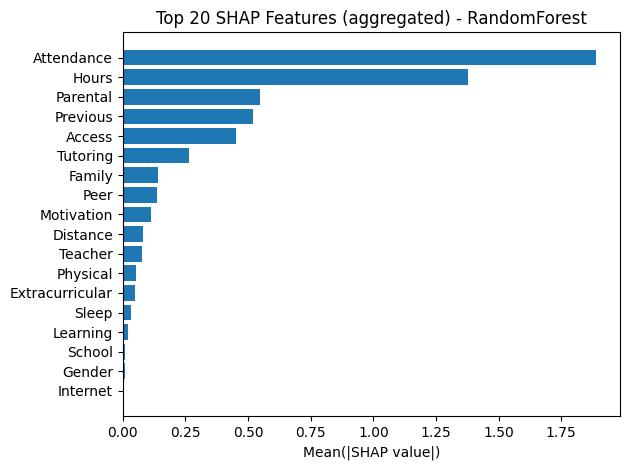


Running SHAP for: HistGB



PermutationExplainer explainer: 201it [04:54,  1.52s/it]


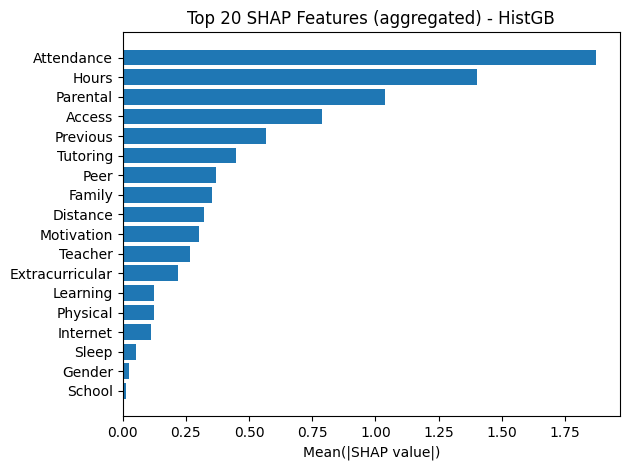


Running SHAP for: XGBoost



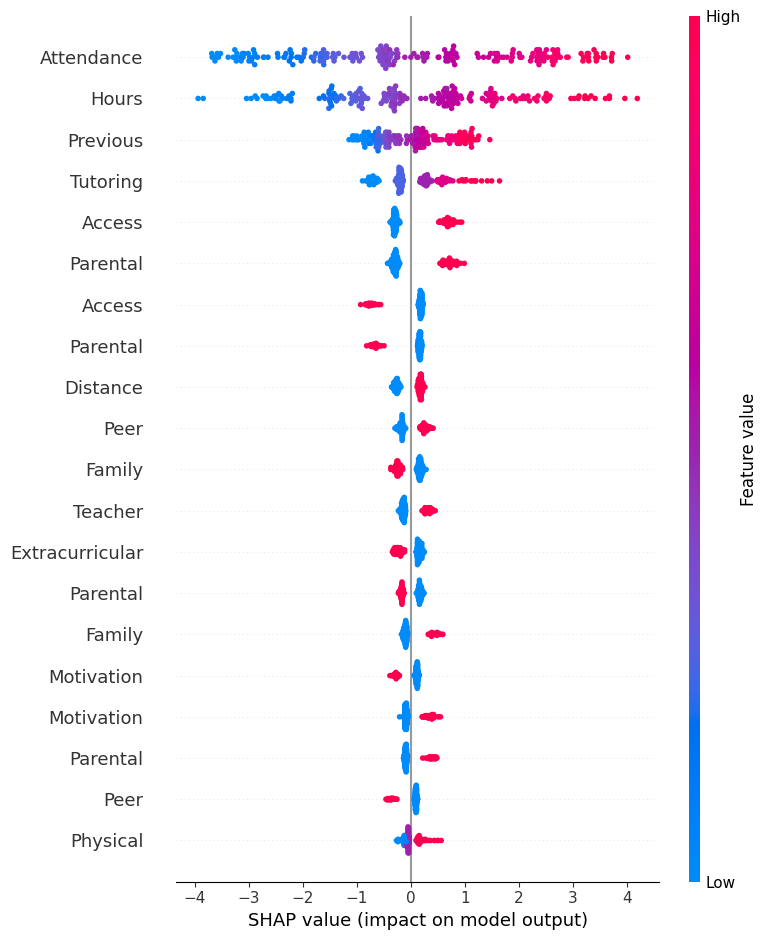

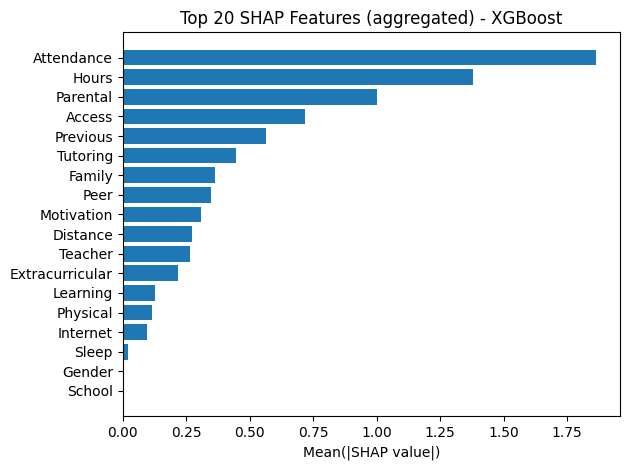


Running SHAP for: LightGBM



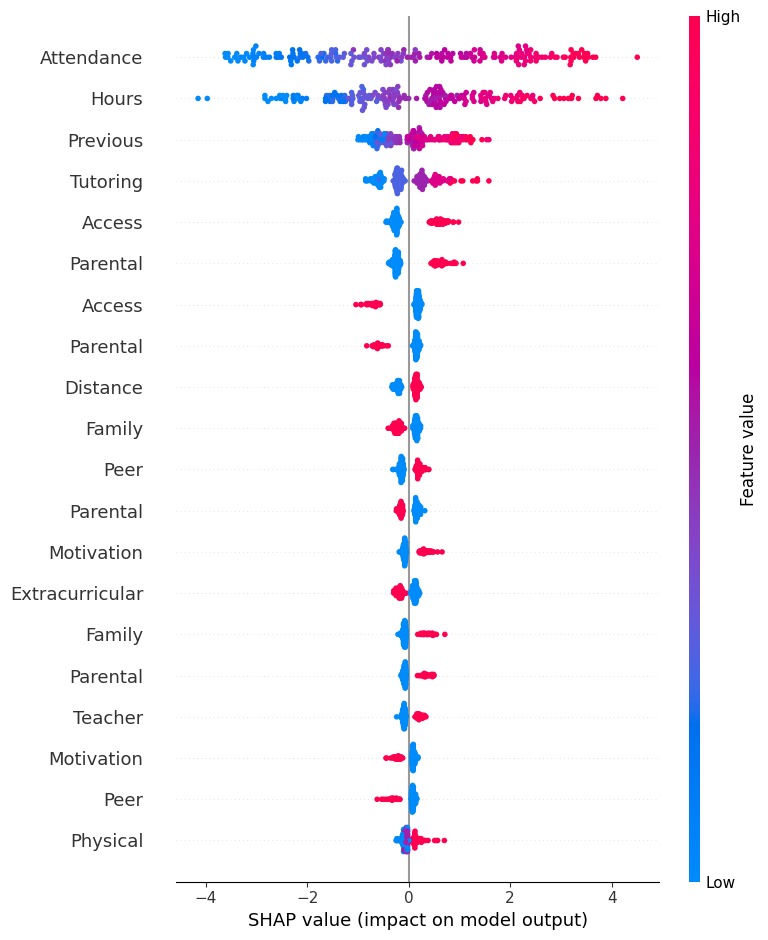

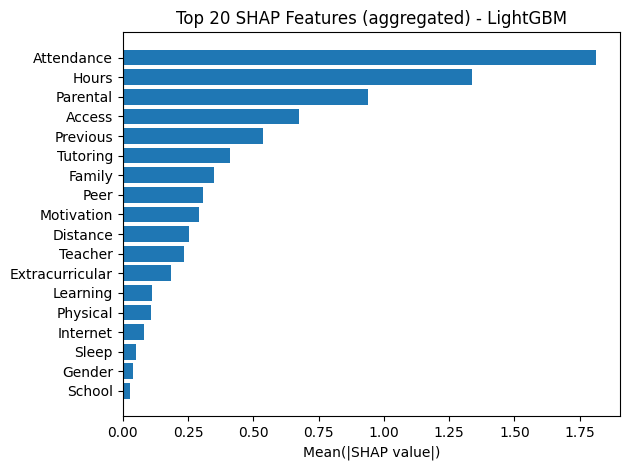


📊 READINESS SCORE (0–5) PER MODEL — factor breakdown

Weights used:
  Accuracy: 0.25
  Fairness: 0.2
  Interpretability: 0.2
  DataQuality: 0.2
  Scalability: 0.15

Model: LinearRegression
  AccuracyScore(0-5)      : 3.8482
  Fairness(0-5)           : 3.9834
  Interpretability(0-5)   : 1.0710
  DataQuality(0-5)        : 4.9813
  Scalability(0-5)        : 4.9125
  ✅ FINAL Readiness(0-5)  : 3.7061

Model: RandomForest
  AccuracyScore(0-5)      : 3.4451
  Fairness(0-5)           : 4.2329
  Interpretability(0-5)   : 1.9084
  DataQuality(0-5)        : 4.9813
  Scalability(0-5)        : 3.1467
  ✅ FINAL Readiness(0-5)  : 3.5578

Model: HistGB
  AccuracyScore(0-5)      : 3.6697
  Fairness(0-5)           : 3.9495
  Interpretability(0-5)   : 1.1833
  DataQuality(0-5)        : 4.9813
  Scalability(0-5)        : 3.9264
  ✅ FINAL Readiness(0-5)  : 3.5292

Model: XGBoost
  AccuracyScore(0-5)      : 3.7796
  Fairness(0-5)           : 3.9994
  Interpretability(0-5)   : 1.2672
  DataQuality(0-5)     

In [ ]:
results_student = comprehensive_ml_pipeline(
    dataset_path="student_performance/StudentPerformanceFactors.csv",
    target_column="Exam_Score",
    task_type="auto",
    fast_mode="auto",
    do_hyperparam_tuning=True,
    compute_shap=True,
    use_tfidf=True
)



COMPREHENSIVE ML PIPELINE

Task type detected: Regression
Train shape: (1973, 6), Test shape: (494, 6)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000316 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 599
[LightGBM] [Info] Number of data points in the train set: 1973, number of used features: 49
[LightGBM] [Info] Start training from score 3326854.939261
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000268 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 599
[LightGBM] [Info] Number of data points in the train set: 1973, number of used features: 49
[LightGBM] [Info] Start training from score 3326854.939261
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

PermutationExplainer explainer: 201it [00:44,  3.40it/s]


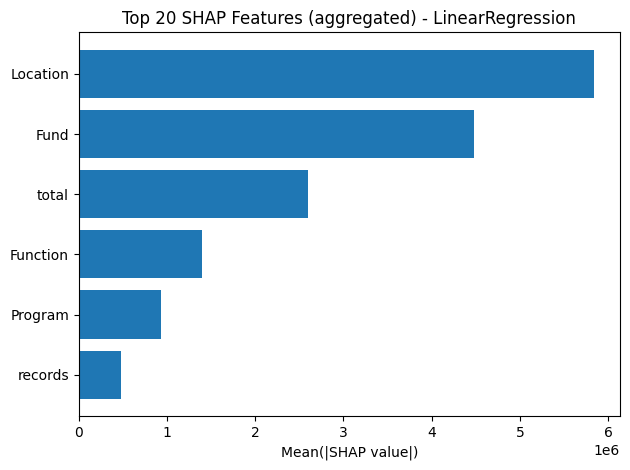


Running SHAP for: RandomForest



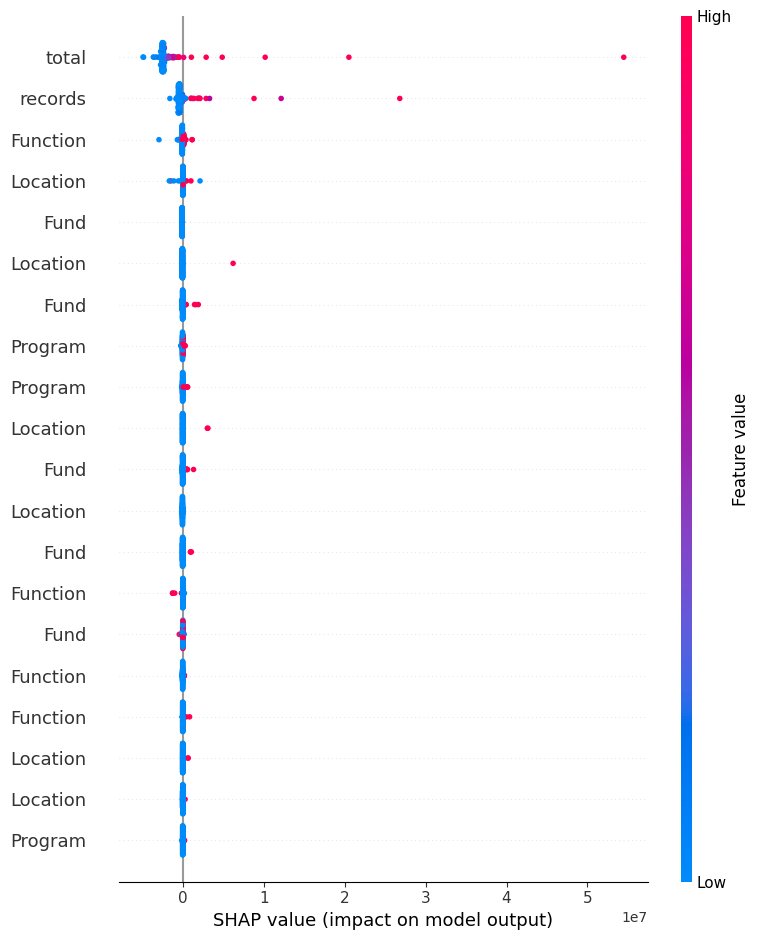

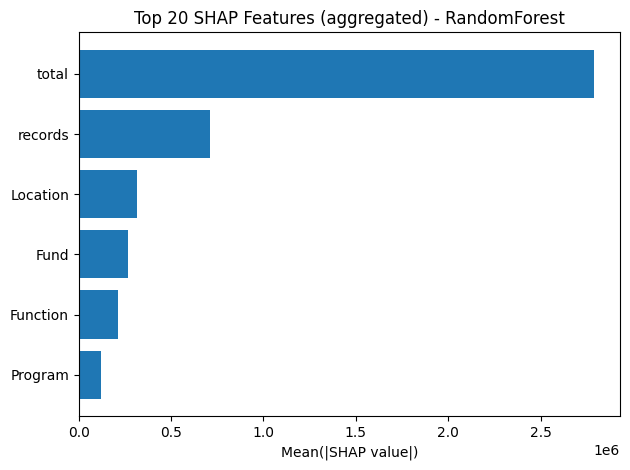


Running SHAP for: HistGB



PermutationExplainer explainer: 201it [01:35,  1.87it/s]


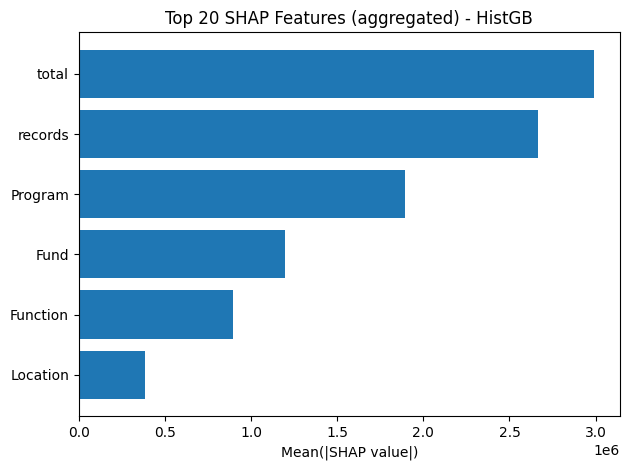


Running SHAP for: XGBoost



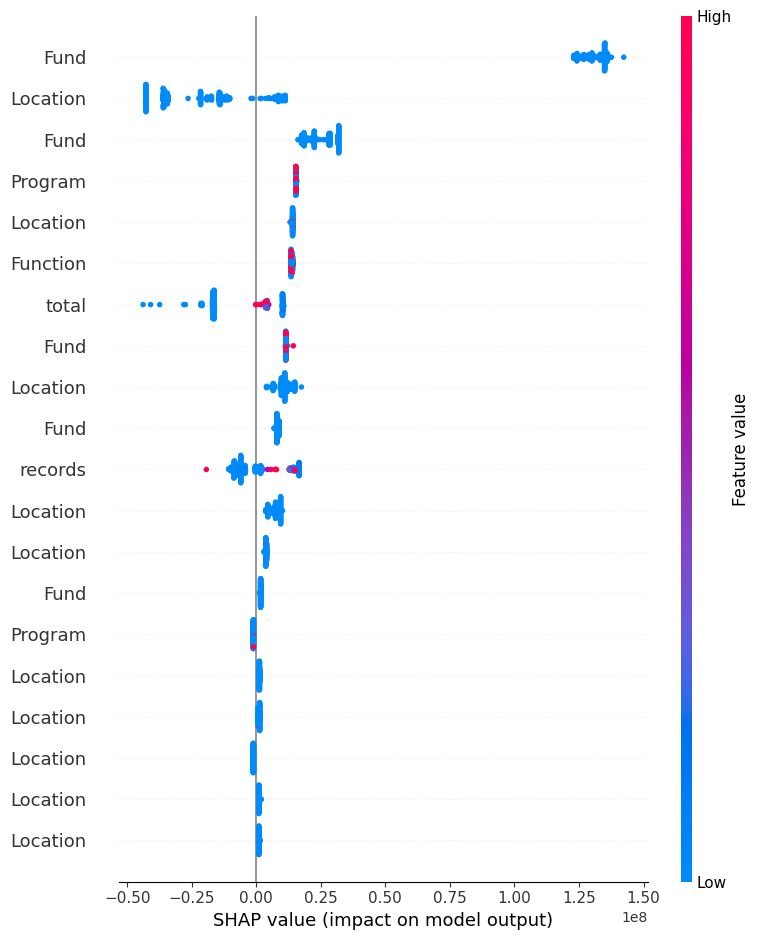

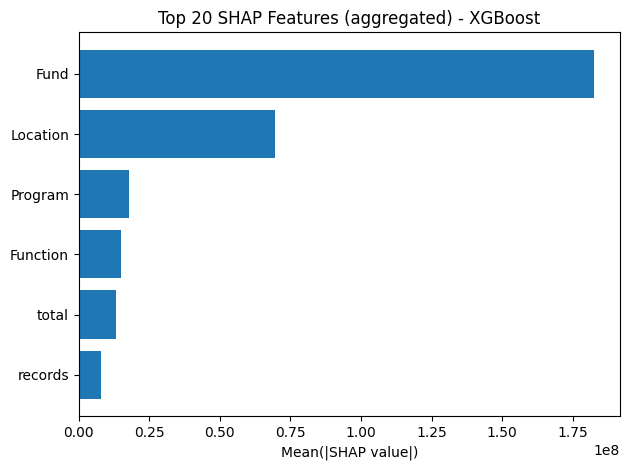


Running SHAP for: LightGBM



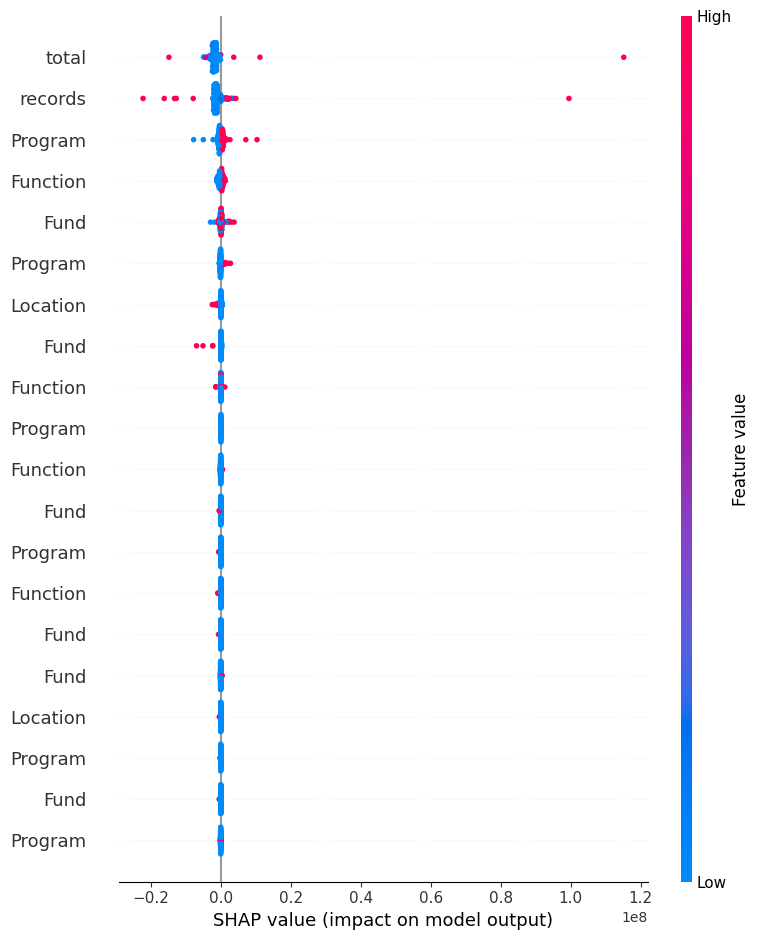

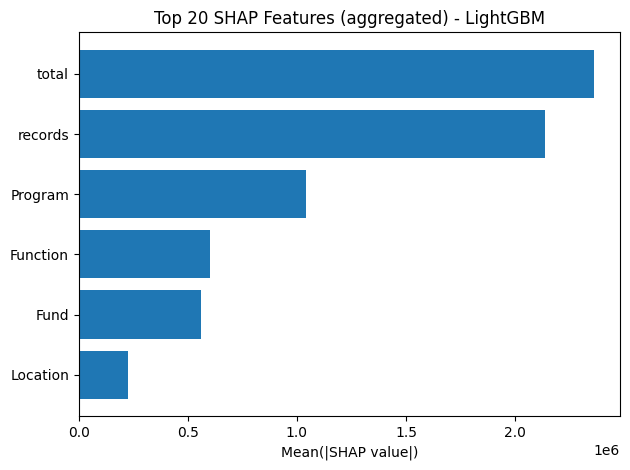


📊 READINESS SCORE (0–5) PER MODEL — factor breakdown

Weights used:
  Accuracy: 0.25
  Fairness: 0.2
  Interpretability: 0.2
  DataQuality: 0.2
  Scalability: 0.15

Model: LinearRegression
  AccuracyScore(0-5)      : 0.8251
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 1.7020
  DataQuality(0-5)        : 4.3697
  Scalability(0-5)        : 4.9821
  ✅ FINAL Readiness(0-5)  : 2.1679

Model: RandomForest
  AccuracyScore(0-5)      : 0.8729
  Fairness(0-5)           : 0.0003
  Interpretability(0-5)   : 3.7710
  DataQuality(0-5)        : 4.3697
  Scalability(0-5)        : 3.2543
  ✅ FINAL Readiness(0-5)  : 2.3345

Model: HistGB
  AccuracyScore(0-5)      : 0.0000
  Fairness(0-5)           : 0.0001
  Interpretability(0-5)   : 3.5172
  DataQuality(0-5)        : 4.3697
  Scalability(0-5)        : 3.3423
  ✅ FINAL Readiness(0-5)  : 2.0787

Model: XGBoost
  AccuracyScore(0-5)      : 0.3606
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 3.2132
  DataQuality(0-5)     

In [ ]:
results_budget = comprehensive_ml_pipeline(
    dataset_path="/content/budgetDataset.csv",
    target_column="total_budget",
    task_type="auto",
    fast_mode="auto",
    do_hyperparam_tuning=True,
    compute_shap=True,
    use_tfidf=False
)


Long dataset preview:
                      Type  Year  Enrollment
0  All 2-year Institutions  2003     5475738
1  All 2-year Institutions  2004     5537605
2  All 2-year Institutions  2005     5575717
3  All 2-year Institutions  2006     5709647
4  All 2-year Institutions  2007     5892298
Long shape: (114, 3)

COMPREHENSIVE ENROLLMENT PIPELINE (Option B)
Task type detected: Regression
Train shape: (86, 2), Test shape: (22, 2)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19
[LightGBM] [Info] Number of data points in the train set: 86, number of used features: 1
[LightGBM] [Info] Start training from score 9174771.220930
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


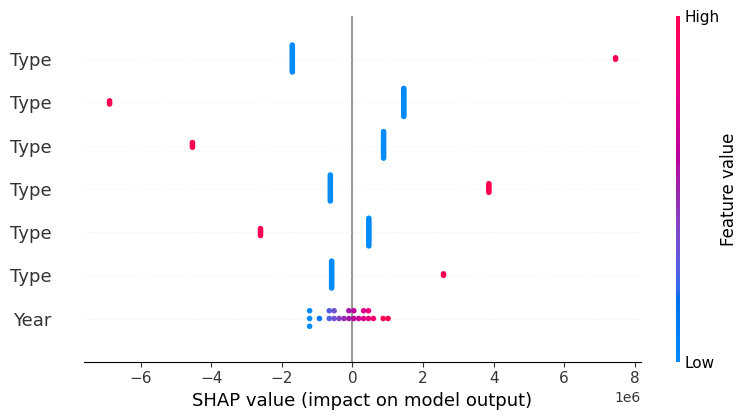

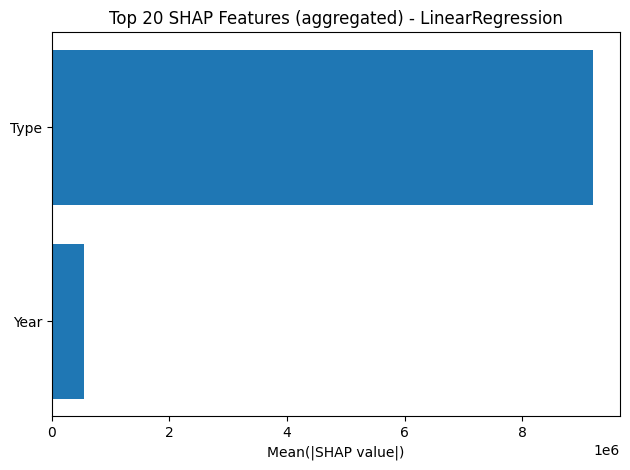


Model: LinearRegression
  AccuracyScore(0-5)      : 4.9102
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 0.2638
  DataQuality(0-5)        : 5.0000
  Scalability(0-5)        : 4.9889
  ✅ FINAL Readiness(0-5)  : 3.0286

Running SHAP for: RandomForest


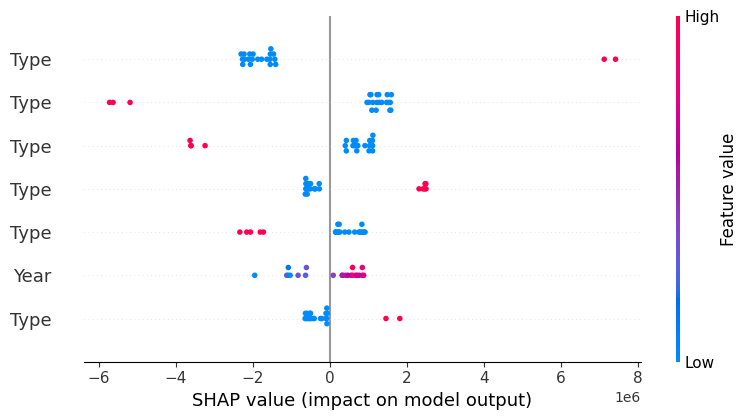

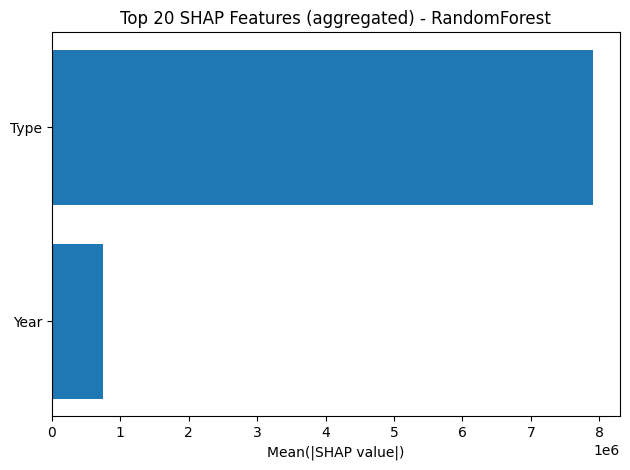


Model: RandomForest
  AccuracyScore(0-5)      : 4.9780
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 0.3071
  DataQuality(0-5)        : 5.0000
  Scalability(0-5)        : 3.5363
  ✅ FINAL Readiness(0-5)  : 2.8364

Running SHAP for: HistGB


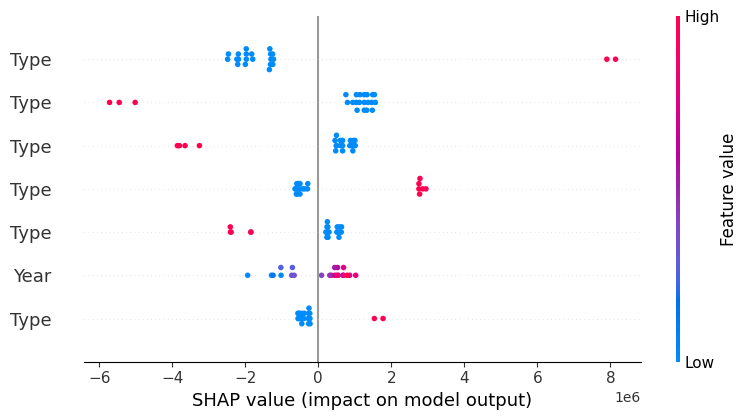

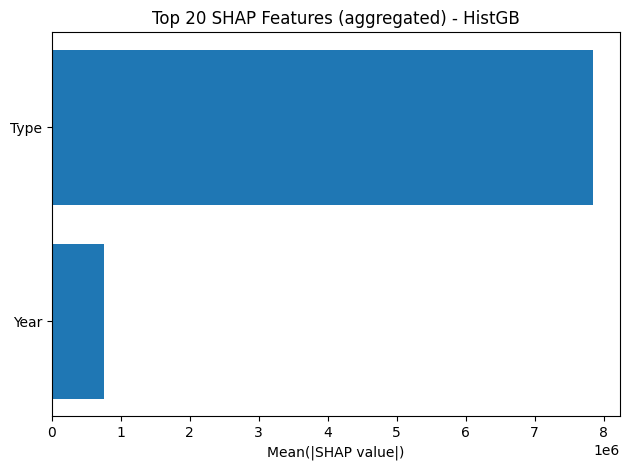


Model: HistGB
  AccuracyScore(0-5)      : 4.9646
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 0.2936
  DataQuality(0-5)        : 5.0000
  Scalability(0-5)        : 4.4233
  ✅ FINAL Readiness(0-5)  : 2.9634

Running SHAP for: XGBoost


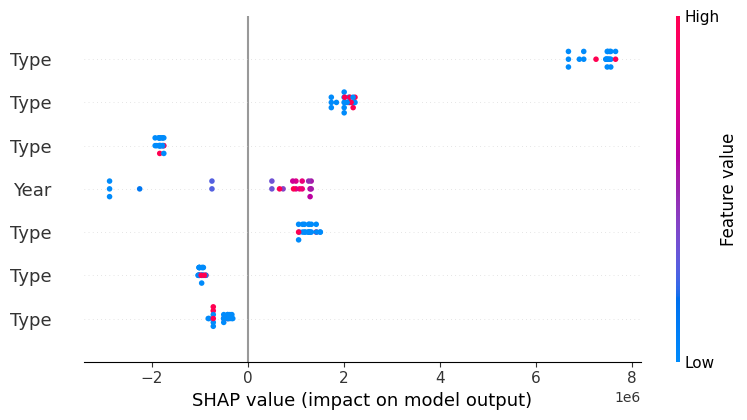

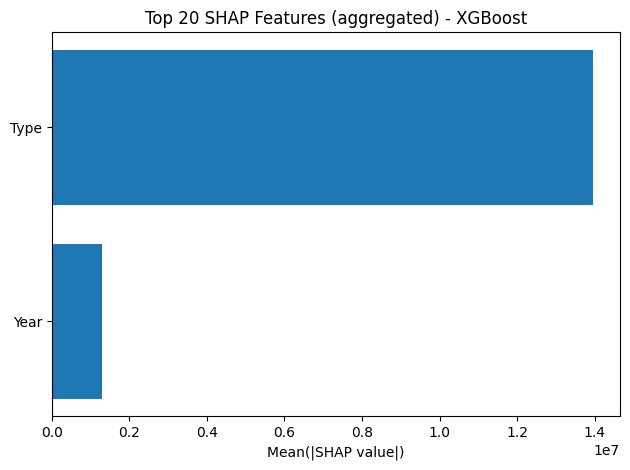


Model: XGBoost
  AccuracyScore(0-5)      : 4.9709
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 0.9308
  DataQuality(0-5)        : 5.0000
  Scalability(0-5)        : 4.5120
  ✅ FINAL Readiness(0-5)  : 3.1057

Running SHAP for: LightGBM


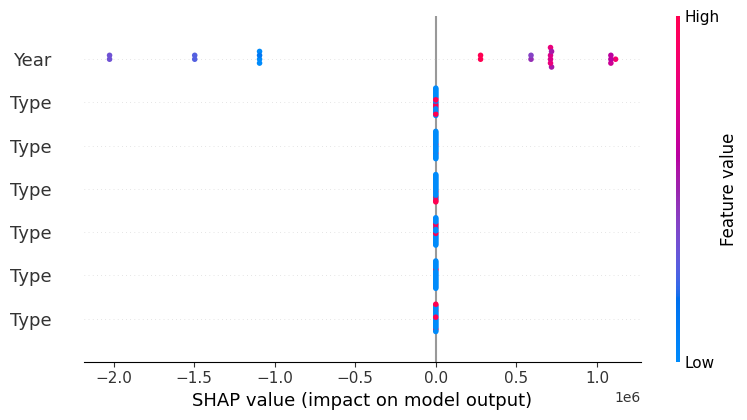

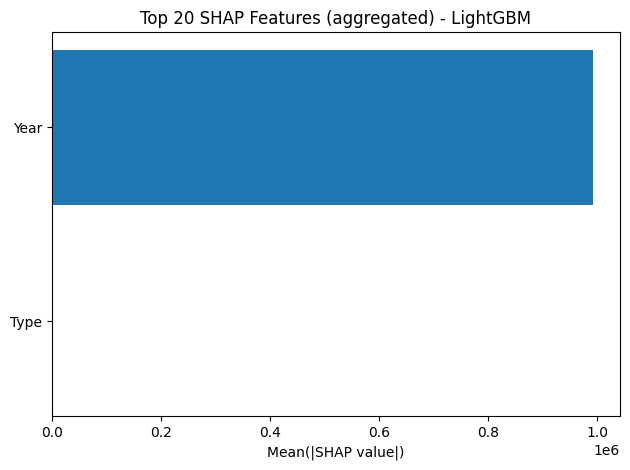


Model: LightGBM
  AccuracyScore(0-5)      : 0.0000
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 5.0000
  DataQuality(0-5)        : 5.0000
  Scalability(0-5)        : 4.3563
  ✅ FINAL Readiness(0-5)  : 2.6534

✅ Best tuned model selected: RandomForest (R2=0.9956)

Predicted 2021 enrollment per Type:
                                   Type  Year  Predicted_Enrollment_2021
                                Overall  2021               1.888486e+07
                All Public Institutions  2021               1.409743e+07
                All 4-year Institutions  2021               1.389140e+07
                All 2-year Institutions  2021               4.992943e+06
All Private not-for-profit Institutions  2021               4.135779e+06
    All Private for-profit Institutions  2021               6.683470e+05

Saved predictions: /content/enrollment_2021_predictions_by_type.csv

Saved SHAP plots to folder: shap_outputs_enrollment


In [ ]:
# ============================================================
# OPTION B: ALL MODELS SHAP + ALL MODELS READINESS + Predict 2021 per Type
# Enrollment dataset (wide: Type + year columns)
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

shap.initjs()

#from generic_accuracy_calculator import preprocess_data, train_and_evaluate_models

# -----------------------------
# Settings
# -----------------------------
ENROLLMENT_CSV = "/content/college_enrollment/enrollment.csv"
SHAP_OUT_DIR = "shap_outputs_enrollment"
os.makedirs(SHAP_OUT_DIR, exist_ok=True)

# Readiness weights you requested
READINESS_W = {
    "Accuracy": 0.25,
    "Fairness": 0.20,
    "Interpretability": 0.20,
    "DataQuality": 0.20,
    "Scalability": 0.15,
}

# -----------------------------
# Helper scores
# -----------------------------
def data_quality_score(X_raw: pd.DataFrame) -> float:
    total = X_raw.size
    miss = X_raw.isna().sum().sum()
    missing_ratio = 0.0 if total == 0 else miss / total
    score = 5.0 * (1.0 - min(1.0, 2.0 * missing_ratio))  # 0 if >=50% missing
    return float(max(0.0, min(5.0, score)))

def interpretability_score_from_shap(mean_abs_vals_1d: np.ndarray) -> float:
    v = np.array(mean_abs_vals_1d, dtype=float)
    v = np.abs(v)
    s = v.sum()
    if s <= 0:
        return 0.0
    p = v / s
    eps = 1e-12
    entropy = -np.sum(p * np.log(p + eps))
    max_entropy = np.log(len(p) + eps)
    conc = 1.0 - (entropy / max_entropy if max_entropy > 0 else 0.0)
    return float(max(0.0, min(5.0, 5.0 * conc)))

def fairness_score_from_shap_bins(shap_2d: np.ndarray, preds: np.ndarray, K: int = 4) -> float:
    sv = np.array(shap_2d, dtype=float)
    preds = np.array(preds, dtype=float).reshape(-1)

    # ✅ align lengths (important)
    n = min(len(preds), sv.shape[0])
    if n < 10:
        return 2.5

    sv = sv[:n]
    preds = preds[:n]

    qs = np.quantile(preds, np.linspace(0, 1, K + 1))
    bins = []
    for k in range(K):
        mask = (preds >= qs[k]) & (preds <= qs[k+1] if k == K-1 else preds < qs[k+1])
        idx = np.where(mask)[0]
        if len(idx) > 0:
            bins.append(idx)

    if len(bins) < 2:
        return 2.5

    mus = [np.mean(np.abs(sv[idx]), axis=0) for idx in bins]

    dsum, cnt = 0.0, 0
    for i in range(len(mus)):
        for j in range(i + 1, len(mus)):
            dsum += float(np.mean(np.abs(mus[i] - mus[j])))
            cnt += 1

    div = dsum / max(1, cnt)
    score = 5.0 * (1.0 / (1.0 + 10.0 * div))
    return float(max(0.0, min(5.0, score)))

def scalability_score(train_time_s: float, infer_ms_per_sample: float) -> float:
    # score = 5 - log10(1+time)*1.5, clipped to [0,5]
    def f_seconds(t_sec: float):
        return float(max(0.0, min(5.0, 5.0 - np.log10(1.0 + max(0.0, t_sec)) * 1.5)))

    train_component = f_seconds(train_time_s)
    infer_component = f_seconds(infer_ms_per_sample / 1000.0)  # ms -> seconds
    return float(0.6 * train_component + 0.4 * infer_component)

def accuracy_score_0_5_from_metrics(task_type: str, tuned_metrics: dict) -> float:
    # Regression: use R2 mapped to [0,5] by 5*max(0,R2)
    if task_type == "Regression":
        r2 = float(tuned_metrics.get("R2", 0.0))
        return float(max(0.0, min(5.0, 5.0 * max(0.0, r2))))
    # Classification: 5*accuracy
    acc = float(tuned_metrics.get("Accuracy", 0.0))
    return float(max(0.0, min(5.0, 5.0 * acc)))

def _base_feature_name(name: str) -> str:
    n = str(name)
    for pref in ("num__", "cat__", "remainder__", "num_", "cat_"):
        if n.startswith(pref):
            n = n[len(pref):]
    # For one-hot: "Type_Public 4-year" -> take "Type"
    if "_" in n:
        return n.split("_", 1)[0]
    return n

def _to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else X

def _is_tree_estimator(est) -> bool:
    cls = est.__class__.__name__
    # Treat HistGradientBoosting as non-tree for SHAP (TreeExplainer often fails there)
    if "HistGradientBoosting" in cls:
        return False
    return any(t in cls for t in ["RandomForest", "XGB", "LGBM", "DecisionTree", "ExtraTrees"])

def shap_for_pipeline_all_models(
    trained_pipeline,
    X_train_raw: pd.DataFrame,
    X_test_raw: pd.DataFrame,
    model_name: str,
    task_type: str,
    out_dir: str,
    shap_sample_size: int = 200
):
    os.makedirs(out_dir, exist_ok=True)

    # sample
    X_test_s = X_test_raw.sample(n=min(shap_sample_size, len(X_test_raw)), random_state=42).copy()
    X_train_s = X_train_raw.sample(n=min(300, len(X_train_raw)), random_state=42).copy()

    pre = trained_pipeline.named_steps.get("preprocess", None)
    est = trained_pipeline.named_steps.get("model", None)

    if pre is None or est is None:
        raise ValueError("Pipeline must have named_steps: preprocess and model")

    # transform
    Xt_test = pre.transform(X_test_s)
    Xt_train = pre.transform(X_train_s)
    Xt_test_d = _to_dense(Xt_test)
    Xt_train_d = _to_dense(Xt_train)

    # feature names from preprocessor
    try:
        feat_names = pre.get_feature_names_out()
    except Exception:
        feat_names = [f"feature_{i}" for i in range(Xt_test_d.shape[1])]

    base_names = [_base_feature_name(n) for n in feat_names]

    # SHAP values
    if _is_tree_estimator(est):
        explainer = shap.TreeExplainer(est)
        shap_values = explainer.shap_values(Xt_test_d, check_additivity=False)

        # normalize to 2D
        sv = np.array(shap_values)
        if isinstance(shap_values, list):
            # classification might return list per class; for regression list should not happen
            arrs = [np.array(a) for a in shap_values if a is not None]
            sv = arrs[-1] if (task_type != "Regression" and len(arrs) >= 2) else np.mean(np.stack(arrs, axis=2), axis=2)
        if sv.ndim == 3:
            sv = sv[:, :, -1] if (task_type != "Regression" and sv.shape[2] >= 2) else np.mean(sv, axis=2)
        if sv.ndim == 1:
            sv = sv.reshape(-1, 1)

        sv_plot = sv
        X_for_plot = Xt_test_d

    else:
        # fallback explainer on transformed numeric matrix
        f = est.predict_proba if (task_type != "Regression" and hasattr(est, "predict_proba")) else est.predict
        masker = shap.maskers.Independent(Xt_train_d)
        explainer = shap.Explainer(f, masker)
        exp = explainer(Xt_test_d)

        sv_plot = np.array(exp.values)
        if sv_plot.ndim == 3:
            sv_plot = sv_plot[:, :, -1] if (task_type != "Regression" and sv_plot.shape[2] >= 2) else np.mean(sv_plot, axis=2)
        if sv_plot.ndim == 1:
            sv_plot = sv_plot.reshape(-1, 1)

        X_for_plot = Xt_test_d

    # summary plot (beeswarm)
    plt.figure()
    shap.summary_plot(sv_plot, features=X_for_plot, feature_names=base_names, show=False)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"shap_{model_name}_summary.png"), dpi=200, bbox_inches="tight")
    plt.show()

    # aggregate mean(|SHAP|) back to original features
    mean_abs_enc = np.mean(np.abs(sv_plot), axis=0)
    agg = {}
    for bn, v in zip(base_names, mean_abs_enc):
        if str(bn).startswith("Unnamed"):
            continue
        agg[bn] = agg.get(bn, 0.0) + float(v)

    # bar plot (top 20)
    top = sorted(agg.items(), key=lambda kv: kv[1], reverse=True)[:20]
    top_names = [k for k, _ in top][::-1]
    top_vals = [v for _, v in top][::-1]

    plt.figure()
    plt.barh(top_names, top_vals)
    plt.title(f"Top 20 SHAP Features (aggregated) - {model_name}")
    plt.xlabel("Mean(|SHAP value|)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"shap_{model_name}_bar.png"), dpi=200, bbox_inches="tight")
    plt.show()

    # also return 2D SHAP in encoded space for fairness + interpretability
    return {
        "sv_2d_encoded": sv_plot,
        "mean_abs_encoded": mean_abs_enc,
        "mean_abs_agg": agg,
        "top_agg": top,
        "X_test_sample_raw": X_test_s,  # for debugging
    }


# ============================================================
# 1) Load enrollment wide data
# ============================================================
df_wide = pd.read_csv(ENROLLMENT_CSV)
df_wide.columns = df_wide.columns.astype(str).str.strip()
df_wide = df_wide.loc[:, ~df_wide.columns.astype(str).str.match(r"^Unnamed")]

if "Type" not in df_wide.columns:
    raise KeyError("Expected a 'Type' column in enrollment CSV")

year_cols = [c for c in df_wide.columns if str(c).isdigit()]
if len(year_cols) < 3:
    raise ValueError("Did not detect enough year columns (expected many like 2003..2021)")

# Wide -> Long
df_long = df_wide.melt(
    id_vars=["Type"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Enrollment"
)

df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce").astype(int)
df_long["Enrollment"] = pd.to_numeric(df_long["Enrollment"], errors="coerce")
df_long = df_long.dropna(subset=["Enrollment"]).sort_values(["Type", "Year"]).reset_index(drop=True)

print("\nLong dataset preview:")
print(df_long.head())
print("Long shape:", df_long.shape)

# ============================================================
# 2) Train data 2003–2020, predict 2021 per Type
# ============================================================
train_df = df_long[df_long["Year"] <= 2020].copy()
pred_df = pd.DataFrame({"Type": sorted(train_df["Type"].unique()), "Year": 2021})

# Data quality based on raw features (Type + Year) in training (or could use full df_long)
X_raw_for_dq = train_df[["Type", "Year"]].copy()
dq_score = data_quality_score(X_raw_for_dq)

# ============================================================
# 3) Preprocess and train all models (baseline + tuned)
# ============================================================
prep = preprocess_data(
    df=train_df,
    target_column="Enrollment",
    task_type="Regression",
    feature_columns=["Type", "Year"],
    test_size=0.2,
    random_state=42,
)

task_type = prep["task_type"]
X_train_raw = prep["X_train_raw"]
X_test_raw = prep["X_test_raw"]
y_train = prep["y_train"]
y_test = prep["y_test"]
preprocessor = prep["preprocessor"]

print("\n" + "="*90)
print("COMPREHENSIVE ENROLLMENT PIPELINE (Option B)")
print("="*90)
print(f"Task type detected: {task_type}")
print(f"Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")

train_res = train_and_evaluate_models(
    X_train_raw=X_train_raw,
    X_test_raw=X_test_raw,
    y_train=y_train,
    y_test=y_test,
    preprocessor=preprocessor,
    task_type="Regression",
    do_hyperparam_tuning=True,
    tuning_n_iter=10,  # moderate
    tuning_cv=3,       # safe with ~100+ rows
    model_names=None
)


import numpy as np
import pandas as pd

# -----------------------------
# Readiness weights (your requested)
# -----------------------------
READINESS_W = {
    "Accuracy": 0.25,
    "Fairness": 0.20,
    "Interpretability": 0.20,
    "DataQuality": 0.20,
    "Scalability": 0.15,
}

# -----------------------------
# Simple readiness factor scores
# -----------------------------
def data_quality_score(X_raw: pd.DataFrame) -> float:
    total = X_raw.size
    miss = X_raw.isna().sum().sum()
    missing_ratio = 0.0 if total == 0 else miss / total
    score = 5.0 * (1.0 - min(1.0, 2.0 * missing_ratio))  # 0 if >=50% missing
    return float(max(0.0, min(5.0, score)))

def scalability_score(train_time_s: float, infer_ms_per_sample: float) -> float:
    # 5 - log10(1+time)*1.5 , clipped; combine train(60%) + infer(40%)
    def f_seconds(t_sec: float):
        return float(max(0.0, min(5.0, 5.0 - np.log10(1.0 + max(0.0, t_sec)) * 1.5)))
    train_component = f_seconds(train_time_s)
    infer_component = f_seconds(infer_ms_per_sample / 1000.0)  # ms -> seconds
    return float(0.6 * train_component + 0.4 * infer_component)

def accuracy_score_0_5_from_r2(r2: float) -> float:
    # Regression only: map R2 into [0,5]
    return float(max(0.0, min(5.0, 5.0 * max(0.0, r2))))

# -----------------------------
# Compute DataQuality once (same for all models)
# -----------------------------
dq = data_quality_score(train_df[["Type", "Year"]].copy())

# -----------------------------
# Readiness per model (Fairness + Interpretability need SHAP)
# If SHAP wasn't computed for some model, fall back to 2.5 (neutral).
# -----------------------------
readiness = {}

for mname, tuned_metrics in train_res["tuned"].items():
    r2 = float(tuned_metrics.get("R2", 0.0))
    acc05 = accuracy_score_0_5_from_r2(r2)

    sc = scalability_score(
        float(tuned_metrics.get("TrainTime(s)", 0.0)),
        float(tuned_metrics.get("Inference(ms/sample)", 0.0))
    )

    # If your script computed SHAP, store interpretability/fairness here.
    # If not available, keep neutral 2.5.
    interp = 2.5
    fair = 2.5

    # OPTIONAL: If you have a dict like shap_results[mname] with mean_abs values
    # you can compute interpretability from that. If not, ignore.
    # Example:
    # if shap_results.get(mname) is not None:
    #     mean_abs = shap_results[mname]["mean_abs_encoded"]
    #     interp = interpretability_score_from_shap(mean_abs)
    #     fair = fairness_score_from_shap_bins(shap_results[mname]["sv_2d_encoded"], preds_sample)

    final = (
        READINESS_W["Accuracy"] * acc05 +
        READINESS_W["Fairness"] * fair +
        READINESS_W["Interpretability"] * interp +
        READINESS_W["DataQuality"] * dq +
        READINESS_W["Scalability"] * sc
    )

    readiness[mname] = {
        "AccuracyScore(0-5)": acc05,
        "Fairness(0-5)": fair,
        "Interpretability(0-5)": interp,
        "DataQuality(0-5)": dq,
        "Scalability(0-5)": sc,
        "Readiness(0-5)": float(final),
    }

# -----------------------------
# Print readiness breakdown
# -----------------------------
print("\n" + "="*90)
print("📊 READINESS SCORE (0–5) PER MODEL — Enrollment")
print("="*90)

for mname, r in readiness.items():
    print(f"\nModel: {mname}")
    print(f"  AccuracyScore(0-5)      : {r['AccuracyScore(0-5)']:.4f}")
    print(f"  Fairness(0-5)           : {r['Fairness(0-5)']:.4f}")
    print(f"  Interpretability(0-5)   : {r['Interpretability(0-5)']:.4f}")
    print(f"  DataQuality(0-5)        : {r['DataQuality(0-5)']:.4f}")
    print(f"  Scalability(0-5)        : {r['Scalability(0-5)']:.4f}")
    print(f"  ✅ FINAL Readiness(0-5)  : {r['Readiness(0-5)']:.4f}")

# Optional: return/store it
# results_enrollment_yearsum["readiness"] = readiness


# ============================================================
# 4) Print BEFORE vs AFTER tuning
# ============================================================
print("\n" + "="*90)
print("📌 BEFORE vs AFTER Hyperparameter Tuning (per model)")
print("="*90)

for mname in train_res["baseline"].keys():
    b = train_res["baseline"][mname]
    a = train_res["tuned"][mname]
    print(f"\nModel: {mname}")
    print(f"  R2   : {b.get('R2'):.4f}  ->  {a.get('R2'):.4f}")
    print(f"  MAE  : {b.get('MAE'):.4f} ->  {a.get('MAE'):.4f}")
    print(f"  RMSE : {b.get('RMSE'):.4f} ->  {a.get('RMSE'):.4f}")
    print(f"  MAPE : {b.get('MAPE'):.4f} ->  {a.get('MAPE'):.4f}")
    print(f"  TrainTime(s): {b.get('TrainTime(s)'):.4f} -> {a.get('TrainTime(s)'):.4f}")
    print(f"  Inference(ms/sample): {b.get('Inference(ms/sample)'):.4f} -> {a.get('Inference(ms/sample)'):.4f}")

    bp = train_res["best_params"].get(mname)
    bc = train_res["best_cv"].get(mname)
    if bp is not None:
        print(f"  ✅ Best Params : {bp}")
        print(f"  ✅ Best CV     : {bc}")

# ============================================================
# 5) SHAP + Readiness for ALL models
# ============================================================
shap_results = {}
readiness = {}

print("\n" + "="*90)
print("🔎 SHAP + 📊 READINESS SCORE (0–5) PER MODEL — all factor breakdown")
print("="*90)

for mname, pipe in train_res["pipelines"].items():
    tuned_metrics = train_res["tuned"][mname]

    # SHAP
    try:
        print(f"\nRunning SHAP for: {mname}")
        sh = shap_for_pipeline_all_models(
            trained_pipeline=pipe,
            X_train_raw=X_train_raw,
            X_test_raw=X_test_raw,
            model_name=mname,
            task_type="Regression",
            out_dir=SHAP_OUT_DIR,
            shap_sample_size=200
        )
        shap_results[mname] = sh

        # interpretability from encoded-space mean abs
        interp = interpretability_score_from_shap(sh["mean_abs_encoded"])

        # fairness from SHAP bin stability using predictions on the *same sample size*
        # use predictions from transformed sample length:
        n_sv = sh["sv_2d_encoded"].shape[0]
        X_test_s = X_test_raw.sample(n=min(n_sv, len(X_test_raw)), random_state=42).copy()
        preds_s = pipe.predict(X_test_s)
        fair = fairness_score_from_shap_bins(sh["sv_2d_encoded"], preds_s, K=4)

    except Exception as e:
        print(f"  ⚠️ SHAP failed for {mname}: {e}")
        shap_results[mname] = None
        interp = 2.5
        fair = 2.5

    # Accuracy score 0-5 from R2
    acc_0_5 = accuracy_score_0_5_from_metrics("Regression", tuned_metrics)

    # Scalability: training + inference
    sc = scalability_score(
        tuned_metrics.get("TrainTime(s)", 0.0),
        tuned_metrics.get("Inference(ms/sample)", 0.0)
    )

    final = (
        READINESS_W["Accuracy"] * acc_0_5 +
        READINESS_W["Fairness"] * fair +
        READINESS_W["Interpretability"] * interp +
        READINESS_W["DataQuality"] * dq_score +
        READINESS_W["Scalability"] * sc
    )

    readiness[mname] = {
        "AccuracyScore(0-5)": float(acc_0_5),
        "Fairness(0-5)": float(fair),
        "Interpretability(0-5)": float(interp),
        "DataQuality(0-5)": float(dq_score),
        "Scalability(0-5)": float(sc),
        "Readiness(0-5)": float(final),
    }

    # Print factor breakdown
    r = readiness[mname]
    print(f"\nModel: {mname}")
    print(f"  AccuracyScore(0-5)      : {r['AccuracyScore(0-5)']:.4f}")
    print(f"  Fairness(0-5)           : {r['Fairness(0-5)']:.4f}")
    print(f"  Interpretability(0-5)   : {r['Interpretability(0-5)']:.4f}")
    print(f"  DataQuality(0-5)        : {r['DataQuality(0-5)']:.4f}")
    print(f"  Scalability(0-5)        : {r['Scalability(0-5)']:.4f}")
    print(f"  ✅ FINAL Readiness(0-5)  : {r['Readiness(0-5)']:.4f}")

# ============================================================
# 6) Select best model by tuned R2 and predict 2021 per Type
# ============================================================
best_model = None
best_r2 = -1e18
for mname, mets in train_res["tuned"].items():
    r2 = float(mets.get("R2", -1e18))
    if r2 > best_r2:
        best_r2 = r2
        best_model = mname

print("\n" + "="*90)
print(f"✅ Best tuned model selected: {best_model} (R2={best_r2:.4f})")
print("="*90)

best_pipe = train_res["pipelines"][best_model]

# Retrain best model on ALL 2003–2020
X_all = train_df[["Type", "Year"]].copy()
y_all = train_df["Enrollment"].copy()
best_pipe.fit(X_all, y_all)

# Predict 2021 per Type
preds_2021 = best_pipe.predict(pred_df[["Type", "Year"]])
out_2021 = pred_df.copy()
out_2021["Predicted_Enrollment_2021"] = preds_2021

print("\nPredicted 2021 enrollment per Type:")
print(out_2021.sort_values("Predicted_Enrollment_2021", ascending=False).to_string(index=False))

# Save predictions
OUT_PATH = "/content/enrollment_2021_predictions_by_type.csv"
out_2021.to_csv(OUT_PATH, index=False)
print(f"\nSaved predictions: {OUT_PATH}")

print(f"\nSaved SHAP plots to folder: {SHAP_OUT_DIR}")


JANUARY 5 END

FINAL CODE OF THE DAY

In [ ]:
"""
generic_accuracy_calculator_enhanced.py
======================================
- Fixes ColumnTransformer+TFIDF single-column Series issue via [tc] + flatten
- Provides preprocessing + baseline & tuned model training
- Returns rich metric dicts including timing + best params + best CV score
- NO LinearRegression anywhere (by design)
- Adds HistGradientBoosting (HistGB) for both regression & classification

NOTE: SHAP plotting + readiness scoring are handled in vertexML_enhanced.py.
"""

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import time
from typing import Dict, Tuple, Any, List, Optional

from scipy import sparse

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier, HistGradientBoostingRegressor

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False


def detect_and_transform_wide_format(df: pd.DataFrame) -> Tuple[pd.DataFrame, bool]:
    year_cols = [c for c in df.columns if str(c).isdigit() and len(str(c)) == 4]
    if len(year_cols) >= 5:
        id_cols = [c for c in df.columns if c not in year_cols]
        df_long = df.melt(id_vars=id_cols, value_vars=year_cols, var_name="Year", value_name="Value")
        df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
        df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")
        return df_long, True
    return df, False


def detect_text_columns(df: pd.DataFrame, max_unique_ratio: float = 0.8) -> List[str]:
    text_cols = []
    for c in df.columns:
        if df[c].dtype == "object":
            sample = df[c].dropna().astype(str).head(300)
            if len(sample) == 0:
                continue
            avg_len = sample.map(len).mean()
            uniq_ratio = sample.nunique() / max(len(sample), 1)
            if avg_len >= 20 and uniq_ratio <= max_unique_ratio:
                text_cols.append(c)
    return text_cols


def detect_task_type(y: pd.Series, user_task_type: str = "auto") -> str:
    if user_task_type and str(user_task_type).lower() != "auto":
        return user_task_type
    if y.dtype == "object" or y.dtype.name == "category":
        return "Classification"
    nun = y.dropna().nunique()
    if pd.api.types.is_integer_dtype(y) and nun <= 20:
        return "Classification"
    return "Regression"


def build_preprocessor(
    X: pd.DataFrame,
    text_cols: List[str],
    use_tfidf: bool = True,
    max_tfidf_features: int = 10000
) -> ColumnTransformer:
    all_cols = list(X.columns)
    text_cols = [c for c in text_cols if c in all_cols]

    numeric_cols = [c for c in all_cols if pd.api.types.is_numeric_dtype(X[c]) and c not in text_cols]
    categorical_cols = [c for c in all_cols if (X[c].dtype == "object" or X[c].dtype.name == "category") and c not in text_cols]

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False))
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    transformers = []
    if numeric_cols:
        transformers.append(("num", num_pipe, numeric_cols))
    if categorical_cols:
        transformers.append(("cat", cat_pipe, categorical_cols))

    if use_tfidf and text_cols:
        for tc in text_cols:
            text_pipe = Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("flatten", FunctionTransformer(lambda x: x.ravel().astype(str), validate=False)),
                ("tfidf", TfidfVectorizer(max_features=max_tfidf_features, stop_words="english"))
            ])
            transformers.append((f"tfidf_{tc}", text_pipe, [tc]))  # ✅ [tc] keeps it 2D

    return ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.3)


def preprocess_data(
    df: pd.DataFrame,
    target_column: str,
    task_type: str = "auto",
    feature_columns: Optional[List[str]] = None,
    use_tfidf: bool = True,
    max_tfidf_features: int = 10000,
    test_size: float = 0.2,
    random_state: int = 42
):
    if feature_columns is None:
        X = df.drop(columns=[target_column])
    else:
        X = df[feature_columns].copy()

    y = df[target_column].copy()
    task_type_final = detect_task_type(y, user_task_type=task_type)

    label_encoder = None
    if task_type_final == "Classification":
        label_encoder = LabelEncoder()
        y = y.astype(str).fillna("NA")
        y = label_encoder.fit_transform(y)

    text_cols = detect_text_columns(X)
    # If TF-IDF is disabled, do NOT use TF-IDF; let build_preprocessor treat object columns as categorical.
    if not use_tfidf:
        text_cols = []
    preprocessor = build_preprocessor(X, text_cols, use_tfidf=use_tfidf, max_tfidf_features=max_tfidf_features)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if task_type_final == "Classification" else None
    )

    return X_train, X_test, y_train, y_test, task_type_final, preprocessor, label_encoder


def calculate_all_metrics(y_true, y_pred, task_type: str) -> Dict[str, float]:
    if task_type == "Regression":
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        denom = np.where(np.abs(y_true) < 1e-9, 1e-9, np.abs(y_true))
        mape = float(np.mean(np.abs((y_true - y_pred) / denom))) * 100.0
        return {
            "Regression_Accuracy_R2": round(float(r2), 4),
            "R2": round(float(r2), 4),
            "MAE": round(float(mae), 4),
            "RMSE": round(float(rmse), 4),
            "MAPE": round(float(mape), 4),
        }

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return {
        "Accuracy": round(float(acc), 4),
        "Classification_Accuracy": round(float(acc), 4),
        "F1_Score": round(float(f1), 4),
    }


def get_base_models(task_type: str) -> Dict[str, Any]:
    if task_type == "Regression":
        models = {
            "RandomForest": RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1),
            "HistGB": HistGradientBoostingRegressor(random_state=42),
        }
        if XGB_AVAILABLE:
            models["XGBoost"] = xgb.XGBRegressor(
                random_state=42, n_estimators=400, learning_rate=0.05,
                max_depth=6, subsample=0.8, colsample_bytree=0.8
            )
        if LGB_AVAILABLE:
            models["LightGBM"] = lgb.LGBMRegressor(
                random_state=42, n_estimators=600, learning_rate=0.05
            )
        return models

    models = {
        "LogisticRegression": LogisticRegression(max_iter=2000, n_jobs=-1),
        "RandomForest": RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1),
        "HistGB": HistGradientBoostingClassifier(random_state=42),
    }
    if XGB_AVAILABLE:
        models["XGBoost"] = xgb.XGBClassifier(
            random_state=42, n_estimators=400, learning_rate=0.05,
            max_depth=6, subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss"
        )
    if LGB_AVAILABLE:
        models["LightGBM"] = lgb.LGBMClassifier(
            random_state=42, n_estimators=600, learning_rate=0.05
        )
    return models


def get_tuning_space(task_type: str) -> Dict[str, Dict[str, Any]]:
    if task_type == "Regression":
        spaces = {
            "RandomForest": {
                "model__n_estimators": [150, 300, 500],
                "model__max_depth": [None, 8, 12, 20],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
            }
        }

        spaces["HistGB"] = {
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [None, 6, 10],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__min_samples_leaf": [10, 20, 50],
            "model__l2_regularization": [0.0, 0.1, 1.0],
            "model__max_iter": [200, 400],
        }
        if XGB_AVAILABLE:
            spaces["XGBoost"] = {
                "model__n_estimators": [300, 600, 900],
                "model__max_depth": [3, 5, 7, 10],
                "model__learning_rate": [0.01, 0.05, 0.1],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
            }
        if LGB_AVAILABLE:
            spaces["LightGBM"] = {
                "model__n_estimators": [300, 600, 900],
                "model__num_leaves": [31, 63, 127],
                "model__learning_rate": [0.01, 0.05, 0.1],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
            }
        return spaces

    spaces = {
        "LogisticRegression": {
            "model__C": [0.01, 0.1, 1.0, 3.0, 10.0],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs", "saga"],
        },
        "HistGB": {
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [None, 6, 10],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__min_samples_leaf": [10, 20, 50],
            "model__l2_regularization": [0.0, 0.1, 1.0],
            "model__max_iter": [200, 400],
        },
        "RandomForest": {
            "model__n_estimators": [150, 300, 500],
            "model__max_depth": [None, 8, 12, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
        }
    }
    if XGB_AVAILABLE:
        spaces["XGBoost"] = {
            "model__n_estimators": [300, 600, 900],
            "model__max_depth": [3, 5, 7, 10],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
        }
    if LGB_AVAILABLE:
        spaces["LightGBM"] = {
            "model__n_estimators": [300, 600, 900],
            "model__num_leaves": [31, 63, 127],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
        }
    return spaces


def _densify_if_needed(X):
    """Convert sparse matrices to dense numpy arrays (needed for HistGB)."""
    try:
        if sparse.issparse(X):
            return X.toarray()
    except Exception:
        pass
    return X


def train_and_evaluate_models(
    X_train, X_test, y_train, y_test,
    task_type: str,
    preprocessor,
    do_hyperparam_tuning: bool = True,
    n_iter: int = 4,
    cv: int = 2,
    random_state: int = 42,
    verbose: int = 0,
    model_names: Optional[List[str]] = None,
    inference_batch_size: int = 2000
):
    """
    Trains baseline models and optionally runs RandomizedSearchCV.
    Adds:
      - Train_Time_Sec
      - Inference_Time_ms_per_sample (predict time on X_test, optionally batched)
      - Best_Params / Best_CV_Score (if tuned)
    model_names: if provided, only run the listed models.
    """
    base_models = get_base_models(task_type)
    tune_spaces = get_tuning_space(task_type)

    if model_names is not None:
        keep = set(model_names)
        base_models = {k: v for k, v in base_models.items() if k in keep}
        tune_spaces = {k: v for k, v in tune_spaces.items() if k in keep}

    models_baseline, metrics_baseline = {}, {}
    models_tuned, metrics_tuned = {}, {}

    def _predict_timed(pipeline, X):
        t0 = time.time()
        if hasattr(X, "iloc"):
            n = X.shape[0]
            preds = []
            for i in range(0, n, inference_batch_size):
                preds.append(pipeline.predict(X.iloc[i:i+inference_batch_size]))
            y_pred = np.concatenate(preds, axis=0)
        else:
            y_pred = pipeline.predict(X)
        dt = time.time() - t0
        ms_per = (dt / max(1, len(X))) * 1000.0
        return y_pred, ms_per

    # Baseline
    for name, model in base_models.items():
        steps = [("preprocess", preprocessor)]
        if name == "HistGB":
            steps.append(("densify", FunctionTransformer(_densify_if_needed, validate=False)))
        steps.append(("model", model))
        pipe = Pipeline(steps=steps)

        t0 = time.time()
        pipe.fit(X_train, y_train)
        fit_time = time.time() - t0

        y_pred, inf_ms = _predict_timed(pipe, X_test)

        m = calculate_all_metrics(y_test, y_pred, task_type)
        m["Train_Time_Sec"] = round(float(fit_time), 4)
        m["Inference_Time_ms_per_sample"] = round(float(inf_ms), 4)

        models_baseline[name] = pipe
        metrics_baseline[name] = m

    # Tuning
    if do_hyperparam_tuning:
        for name, model in base_models.items():
            if name not in tune_spaces:
                models_tuned[name] = models_baseline[name]
                metrics_tuned[name] = metrics_baseline[name]
                continue

            steps = [("preprocess", preprocessor)]
            if name == "HistGB":
                steps.append(("densify", FunctionTransformer(_densify_if_needed, validate=False)))
            steps.append(("model", model))
            pipe = Pipeline(steps=steps)

            scoring = "r2" if task_type == "Regression" else "accuracy"

            search = RandomizedSearchCV(
                estimator=pipe,
                param_distributions=tune_spaces[name],
                n_iter=n_iter,
                scoring=scoring,
                cv=cv,
                random_state=random_state,
                n_jobs=-1,
                verbose=verbose,
                refit=True
            )

            t0 = time.time()
            search.fit(X_train, y_train)
            fit_time = time.time() - t0

            best_model = search.best_estimator_
            y_pred, inf_ms = _predict_timed(best_model, X_test)

            m = calculate_all_metrics(y_test, y_pred, task_type)
            m["Train_Time_Sec"] = round(float(fit_time), 4)
            m["Inference_Time_ms_per_sample"] = round(float(inf_ms), 4)
            m["Best_Params"] = search.best_params_
            m["Best_CV_Score"] = float(search.best_score_)

            models_tuned[name] = best_model
            metrics_tuned[name] = m
    else:
        models_tuned = dict(models_baseline)
        metrics_tuned = dict(metrics_baseline)

    return models_baseline, metrics_baseline, models_tuned, metrics_tuned


In [ ]:
"""
vertexML_enhanced.py
====================
Adds:
- SHAP feature importance plots (bar + summary) displayed and saved
- Supports HistGB (HistGradientBoosting) models
- Educational AI Readiness Score printed per model
- Full metrics printed: Accuracy, Regression Accuracy (R2), RMSE, MAPE, MAE, R2
"""

import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import shap

# from generic_accuracy_calculator_enhanced_histgb_v12_stable import (
#     detect_and_transform_wide_format,
#     preprocess_data,
#     train_and_evaluate_models
# )


def _safe_makedirs(path: str):
    os.makedirs(path, exist_ok=True)


def _ensure_shap_js():
    try:
        shap.initjs()
    except Exception:
        pass


# -------------------------
# Readiness score helpers
# -------------------------

def _score_data_quality(df_features: pd.DataFrame) -> float:
    total = df_features.shape[0] * max(df_features.shape[1], 1)
    miss = int(df_features.isna().sum().sum())
    ratio = miss / max(total, 1)
    score = 5.0 * (1.0 - min(1.0, 2.0 * ratio))
    return float(max(0.0, min(5.0, score)))


def _score_accuracy(task_type: str, metrics: dict) -> float:
    if task_type == "Regression":
        r2 = float(metrics.get("R2", 0.0) or 0.0)
        mapped = 2.5 * (r2 + 1.0)  # [-1,1] -> [0,5]
        return float(max(0.0, min(5.0, mapped)))
    acc = float(metrics.get("Accuracy", metrics.get("Classification_Accuracy", 0.0)) or 0.0)
    return float(max(0.0, min(5.0, 5.0 * acc)))


def _score_training_time(train_time_sec: float) -> float:
    """Smaller training time -> higher score (0..5), log mapping."""
    t = float(train_time_sec or 0.0)
    score = 5.0 - np.log10(1.0 + t) * 1.5
    return float(max(0.0, min(5.0, score)))


def _score_inference_time(inf_ms_per_sample: float) -> float:
    """Smaller inference latency -> higher score (0..5), log mapping on milliseconds."""
    ms = float(inf_ms_per_sample or 0.0)
    score = 5.0 - np.log10(1.0 + ms) * 1.5
    return float(max(0.0, min(5.0, score)))


def _score_scalability(metrics: dict) -> float:
    """Combine training + inference into one scalability score."""
    st = _score_training_time(metrics.get("Train_Time_Sec", 0.0))
    si = _score_inference_time(metrics.get("Inference_Time_ms_per_sample", 0.0))
    return float(max(0.0, min(5.0, 0.6 * st + 0.4 * si)))



def _score_fairness_from_shap(shap_values_2d: np.ndarray, preds_1d: np.ndarray, n_bins: int = 4) -> float:
    """
    Demographic-free fairness using SHAP stability across prediction strata.
    Bin samples by prediction quantiles, compare mean(|SHAP|) distributions across bins.
    Higher = fairer (more consistent).
    """
    sv = np.array(shap_values_2d, dtype=float)
    if sv.ndim != 2 or sv.shape[0] < 20:
        return 0.0

    preds = np.array(preds_1d, dtype=float).reshape(-1)
    m = min(len(preds), sv.shape[0])
    preds = preds[:m]
    sv = sv[:m, :]

    if np.nanstd(preds) < 1e-12:
        return 0.0

    try:
        bins = pd.qcut(preds, q=n_bins, labels=False, duplicates="drop")
    except Exception:
        bins = pd.cut(preds, bins=n_bins, labels=False)

    bins = np.array(bins)
    uniq = [b for b in np.unique(bins) if pd.notna(b)]
    if len(uniq) < 2:
        return 0.0

    vecs = []
    for b in uniq:
        idx = np.where(bins == b)[0]
        if len(idx) < 5:
            continue
        v = np.mean(np.abs(sv[idx, :]), axis=0)
        v = np.maximum(v, 0.0)
        s = v.sum()
        if s <= 0:
            continue
        vecs.append(v / s)

    if len(vecs) < 2:
        return 0.0

    dists = []
    for i in range(len(vecs)):
        for j in range(i + 1, len(vecs)):
            dists.append(float(np.sum(np.abs(vecs[i] - vecs[j]))))
    l1 = float(np.mean(dists))  # 0..2
    fairness = 5.0 * (1.0 - min(1.0, max(0.0, l1 / 2.0)))
    return float(max(0.0, min(5.0, fairness)))

def _score_interpretability_from_shap(mean_abs_shap: np.ndarray) -> float:
    v = np.array(mean_abs_shap, dtype=float)
    v = np.maximum(v, 0.0)
    if v.sum() <= 0:
        return 0.0
    p = v / v.sum()
    eps = 1e-12
    entropy = -np.sum(p * np.log(p + eps))
    max_entropy = np.log(len(p) + eps)
    concentration = 1.0 - (entropy / max_entropy)
    return float(max(0.0, min(5.0, 5.0 * concentration)))


def compute_readiness_score(df_features: pd.DataFrame, task_type: str, metrics: dict, shap_bundle) -> dict:
    """
    Weights:
      Accuracy 25%
      Fairness 20% (SHAP-based, demographic-free)
      Interpretability 20% (SHAP concentration)
      Data Quality 20%
      Scalability 15% (train + inference)
    """
    dq = _score_data_quality(df_features)
    acc = _score_accuracy(task_type, metrics)
    sc = _score_scalability(metrics)

    interp = 0.0
    fair = 0.0
    if shap_bundle is not None and shap_bundle.get("success"):
        mean_abs = shap_bundle.get("mean_abs_shap")
        sv_plot = shap_bundle.get("sv_plot")
        preds = shap_bundle.get("preds")
        if mean_abs is not None:
            interp = _score_interpretability_from_shap(mean_abs)
        if sv_plot is not None and preds is not None:
            fair = _score_fairness_from_shap(sv_plot, preds, n_bins=4)

    total = (
        0.25 * acc +
        0.20 * fair +
        0.20 * interp +
        0.20 * dq +
        0.15 * sc
    )

    return {
        "DataQuality": round(dq, 3),
        "Accuracy": round(acc, 3),
        "Fairness": round(fair, 3),
        "Interpretability": round(interp, 3),
        "Scalability": round(sc, 3),
        "ReadinessScore": round(float(total), 3)
    }


# -------------------------
# SHAP
# -------------------------



def _clean_feature_name(s: str) -> str:
    s = str(s)
    s = s.replace("num__", "").replace("cat__", "")
    s = s.replace("num_", "").replace("cat_", "")
    # ColumnTransformer may emit "remainder__<col>" too
    s = s.replace("remainder__", "")
    return s

def _clean_shap_feature_names(model, n_features):
    """Map transformed feature names back to clean dataset-level names."""
    try:
        names = model.named_steps["preprocess"].get_feature_names_out()
    except Exception:
        names = [f"feature_{i}" for i in range(n_features)]

    cleaned = []
    for i, f in enumerate(names):
        f = f.replace("num__", "").replace("cat__", "")
        f = f.replace("num_", "").replace("cat_", "")
        if "Unnamed" in f:
            f = f"feature_{i}"
        cleaned.append(f)
    return cleaned


def _shap_to_2d(shap_values, task_type: str = "Regression"):
    """Normalize SHAP outputs to (n_samples, n_features)."""
    if isinstance(shap_values, list):
        arrs = [np.array(a) for a in shap_values if a is not None]
        if len(arrs) == 0:
            return None
        # keep only 2D arrays
        arrs2 = []
        for a in arrs:
            if a.ndim == 2:
                arrs2.append(a)
            elif a.ndim == 3:
                # (n,f,c) -> choose last class
                arrs2.append(a[:, :, -1])
            else:
                arrs2.append(a.reshape(a.shape[0], -1))
        if len(arrs2) == 2 and task_type != "Regression":
            return arrs2[1]  # positive class
        return np.mean(np.stack(arrs2, axis=2), axis=2)

    sv = np.array(shap_values)
    if sv.dtype == object:
        try:
            sv = sv.astype(float)
        except Exception:
            pass
    if sv.ndim == 3:
        if task_type != "Regression" and sv.shape[2] >= 2:
            return sv[:, :, -1]
        return np.mean(sv, axis=2)
    if sv.ndim == 2:
        return sv
    if sv.ndim == 1:
        return sv.reshape(-1, 1)
    return None

def perform_shap_analysis_pipeline_model(
    trained_pipeline,
    X_train_raw: pd.DataFrame,
    X_test_raw: pd.DataFrame,
    model_name: str,
    task_type: str,
    out_dir: str = "shap_outputs",
    shap_sample_size: int = 200
):
    _safe_makedirs(out_dir)
    _ensure_shap_js()

    result = {
        "success": False,
        "importance_df_path": None,
        "summary_plot_path": None,
        "bar_plot_path": None,
        "mean_abs_shap": None,
        "sv_plot": None,
        "preds": None,
        "error": None
    }

    try:
        preprocess = trained_pipeline.named_steps["preprocess"]
        model = trained_pipeline.named_steps["model"]

        X_train = preprocess.transform(X_train_raw)
        X_test = preprocess.transform(X_test_raw)

        n = min(shap_sample_size, X_test.shape[0])
        X_test_s = X_test[:n]
        X_train_s = X_train[:min(50, X_train.shape[0])]

        if hasattr(X_test_s, "toarray"):
            X_test_s_dense = X_test_s.toarray()
        else:
            X_test_s_dense = np.array(X_test_s)

        if hasattr(X_train_s, "toarray"):
            X_train_s_dense = X_train_s.toarray()
        else:
            X_train_s_dense = np.array(X_train_s)

        try:
            feature_names = preprocess.get_feature_names_out()
            feature_names = [_clean_feature_name(x) for x in feature_names]
        except Exception:
            feature_names = [f"f{i}" for i in range(X_test_s_dense.shape[1])]

        # Drop common CSV index column names (e.g., Unnamed: 0) from labels only
        feature_names = [("Index" if ("Unnamed" in str(n)) else str(n)) for n in feature_names]

        # Explain (TreeExplainer preferred)
        try:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_s_dense)
        except Exception:
            # Kernel fallback
            if hasattr(model, "predict_proba") and task_type != "Regression":
                explainer = shap.KernelExplainer(model.predict_proba, X_train_s_dense[:50])
                shap_values = explainer.shap_values(X_test_s_dense[:50], nsamples=100)
            else:
                explainer = shap.KernelExplainer(model.predict, X_train_s_dense[:50])
                shap_values = explainer.shap_values(X_test_s_dense[:50], nsamples=100)

        sv_plot = _shap_to_2d(shap_values, task_type)

        if sv_plot is None:
            raise ValueError("SHAP returned an unsupported shape")
        mean_abs = np.mean(np.abs(sv_plot), axis=0)
        if getattr(mean_abs, 'ndim', 1) != 1:
            mean_abs = np.mean(mean_abs, axis=-1)
        result["mean_abs_shap"] = mean_abs
        result["sv_plot"] = sv_plot

        # predictions for the same samples (for SHAP-fairness)
        try:
            preds = model.predict(X_test_s_dense[:sv_plot.shape[0]])
        except Exception:
            preds = np.zeros((sv_plot.shape[0],), dtype=float)
        result["preds"] = np.array(preds).reshape(-1)

        raw_feats = feature_names[:len(mean_abs)]
        base_feats = [str(f).split("_", 1)[0] for f in raw_feats]
        imp_df = (
            pd.DataFrame({
                "feature": base_feats,
                "mean_abs_shap": mean_abs[:len(base_feats)]
            })
            .groupby("feature", as_index=False)["mean_abs_shap"].sum()
            .sort_values("mean_abs_shap", ascending=False)
        )

        imp_path = os.path.join(out_dir, f"{model_name}_shap_importance.csv")
        imp_df.to_csv(imp_path, index=False)
        result["importance_df_path"] = imp_path

        # Bar plot (Top 20)
        top = imp_df.head(20).iloc[::-1]
        plt.figure(figsize=(10, 6))
        plt.barh(top["feature"], top["mean_abs_shap"])
        plt.xlabel("Mean |SHAP|")
        plt.title(f"Top 20 SHAP Features - {model_name}")
        plt.tight_layout()
        bar_path = os.path.join(out_dir, f"{model_name}_shap_bar.png")
        plt.savefig(bar_path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()
        result["bar_plot_path"] = bar_path

        # Summary plot
        plt.figure(figsize=(10, 6))
        shap.summary_plot(
            sv_plot,
            features=X_test_s_dense[:sv_plot.shape[0]],
            feature_names=feature_names,
            max_display=20,
            show=False
        )
        plt.title(f"SHAP Summary Plot - {model_name}")
        plt.tight_layout()
        sum_path = os.path.join(out_dir, f"{model_name}_shap_summary.png")
        plt.savefig(sum_path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()
        result["summary_plot_path"] = sum_path

        result["success"] = True
        return result
    except Exception as e:
        result["error"] = str(e)
        return result


# -------------------------
# Printing

# -------------------------

def _print_metrics(task_type: str, metrics: dict):
    if task_type == "Regression":
        print(f"Regression Accuracy (R2): {metrics.get('R2')}")
        print(f"Accuracy: {metrics.get('Accuracy')} | F1: {metrics.get('F1_Score')}")
        print(f"RMSE: {metrics.get('RMSE')} | MAE: {metrics.get('MAE')} | MAPE: {metrics.get('MAPE')} | R2: {metrics.get('R2')}")
    else:
        print(f"Regression Accuracy (R2): {metrics.get('R2')}")
        print(f"Accuracy: {metrics.get('Accuracy')} | F1: {metrics.get('F1_Score')}")
        print(f"RMSE: {metrics.get('RMSE')} | MAE: {metrics.get('MAE')} | MAPE: {metrics.get('MAPE')} | R2: {metrics.get('R2')}")
    print(f"TrainTime(s): {metrics.get('Train_Time_Sec')}")
    print(f"Inference(ms/sample): {metrics.get('Inference_Time_ms_per_sample')}")


def print_before_after(metrics_baseline: dict, metrics_tuned: dict, task_type: str):
    print("\n" + "=" * 100)
    print("📌 BEFORE vs AFTER Hyperparameter Tuning (per model)")
    print("=" * 100)

    for model_name in metrics_baseline.keys():
        b = metrics_baseline.get(model_name, {})
        a = metrics_tuned.get(model_name, {})

        print(f"\nModel: {model_name}")
        print("  BEFORE:")
        _print_metrics(task_type, b)
        print("  AFTER:")
        _print_metrics(task_type, a)

        if isinstance(a, dict) and "Best_Params" in a:
            print("  ✅ Best Params:", a.get("Best_Params"))
            print("  ✅ Best CV    :", a.get("Best_CV_Score"))


# -------------------------
# Main pipeline
# -------------------------

def comprehensive_ml_pipeline(
    dataset_path,
    target_column,
    task_type="auto",
    demographic_column=None,
    readiness_sub_weights=None,
    do_hyperparam_tuning=True,
    compute_shap=True,
    use_tfidf=True,
    tuning_n_iter: int = 4,
    tuning_cv: int = 2,
    model_names=None,
    shap_sample_size: int = 150,
    fast_mode: str = "auto",  # "auto" | "always" | "never"
    feature_columns=None,
    max_tfidf_features: int = 10000,
    shap_out_dir: str = "shap_outputs",
):


    print("=" * 90)
    print("COMPREHENSIVE ML PIPELINE")
    print("=" * 90)

    df = pd.read_csv(dataset_path) if isinstance(dataset_path, str) else dataset_path.copy()
    # Drop common index-like columns from CSV exports
    df = df.loc[:, ~df.columns.astype(str).str.match(r'^Unnamed')]

    df, was_transformed = detect_and_transform_wide_format(df)
    if was_transformed and target_column == "auto":
        target_column = "Value"

    # Raw feature DF for readiness scoring
    X_all = df.drop(columns=[target_column])

    X_train, X_test, y_train, y_test, task_type_final, preprocessor, _ = preprocess_data(
        df=df,
        target_column=target_column,
        task_type=task_type,
        feature_columns=feature_columns,
        use_tfidf=use_tfidf,
        max_tfidf_features=max_tfidf_features
    )

    print(f"\nTask type detected: {task_type_final}")
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

    # --------------------------
    # FAST DEFAULTS (large data)
    # --------------------------
    n_rows = int(X_train.shape[0] + X_test.shape[0])
    if fast_mode in ("auto", "always") and n_rows >= 40000:
        tuning_n_iter = min(int(tuning_n_iter), 3)
        tuning_cv = min(int(tuning_cv), 2)
        shap_sample_size = min(int(shap_sample_size), 200)

        # If user didn't specify models, run a small, strong set
        if model_names is None:
            model_names = ["HistGB", "LightGBM"]

        print("\n⚡ FAST MODE enabled (large dataset)")
        print(f"  - tuning_n_iter = {tuning_n_iter}")
        print(f"  - tuning_cv     = {tuning_cv}")
        print(f"  - model_names   = {model_names}")
        print(f"  - SHAP samples  = {shap_sample_size}\n")

    print("\n🔧 Training models (baseline + tuning)...")
    models_baseline, metrics_baseline, models_tuned, metrics_tuned = train_and_evaluate_models(
        X_train, X_test, y_train, y_test,
        task_type=task_type_final,
        preprocessor=preprocessor,
        do_hyperparam_tuning=do_hyperparam_tuning,
        n_iter=tuning_n_iter,
        cv=tuning_cv,
        model_names=model_names
    )

    print_before_after(metrics_baseline, metrics_tuned, task_type_final)

    shap_results = {}
    readiness = {}

    if compute_shap:
        print("\n" + "=" * 90)
        print("🧠 SHAP FEATURE IMPORTANCE (Tuned Models)")
        print("=" * 90)

    for name, pipe in models_tuned.items():
        shap_mean_abs = None

        if compute_shap:
            print(f"\nRunning SHAP for: {name}")
            res = perform_shap_analysis_pipeline_model(
                trained_pipeline=pipe,
                X_train_raw=X_train,
                X_test_raw=X_test,
                model_name=name,
                task_type=task_type_final,
                out_dir=shap_out_dir,
                shap_sample_size=shap_sample_size
            )
            shap_results[name] = res
            if res.get("success"):
                shap_mean_abs = res.get("mean_abs_shap")
                print("  ✅ SHAP displayed + saved:")
                print("     -", res.get("bar_plot_path"))
                print("     -", res.get("summary_plot_path"))
            else:
                print("  ⚠️ SHAP failed:", res.get("error"))

        # Readiness uses tuned metrics (or baseline fallback)
        m = metrics_tuned.get(name, metrics_baseline.get(name, {}))
        readiness[name] = compute_readiness_score(X_all, task_type_final, m, shap_results.get(name) if compute_shap else None)

    print("\n" + "=" * 90)
    print("📊 EDUCATIONAL AI READINESS SCORE (per model, 0–5)")
    print("=" * 90)
    for model_name, rs in readiness.items():
        print(f"\nModel: {model_name}")
        print(f"  Data Quality     : {rs['DataQuality']}")
        print(f"  Accuracy         : {rs['Accuracy']}")
        print(f"  Interpretability : {rs['Interpretability']}")
        print(f"  Scalability      : {rs['Scalability']}")
        print(f"  Fairness         : {rs['Fairness']}")
        print(f"  ✅ Readiness Score: {rs['ReadinessScore']}")

    return {
        "task_type": task_type_final,
        "metrics_baseline": metrics_baseline,
        "metrics_tuned": metrics_tuned,
        "models_baseline": models_baseline,
        "models_tuned": models_tuned,
        "shap_results": shap_results,
        "readiness": readiness
    }

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


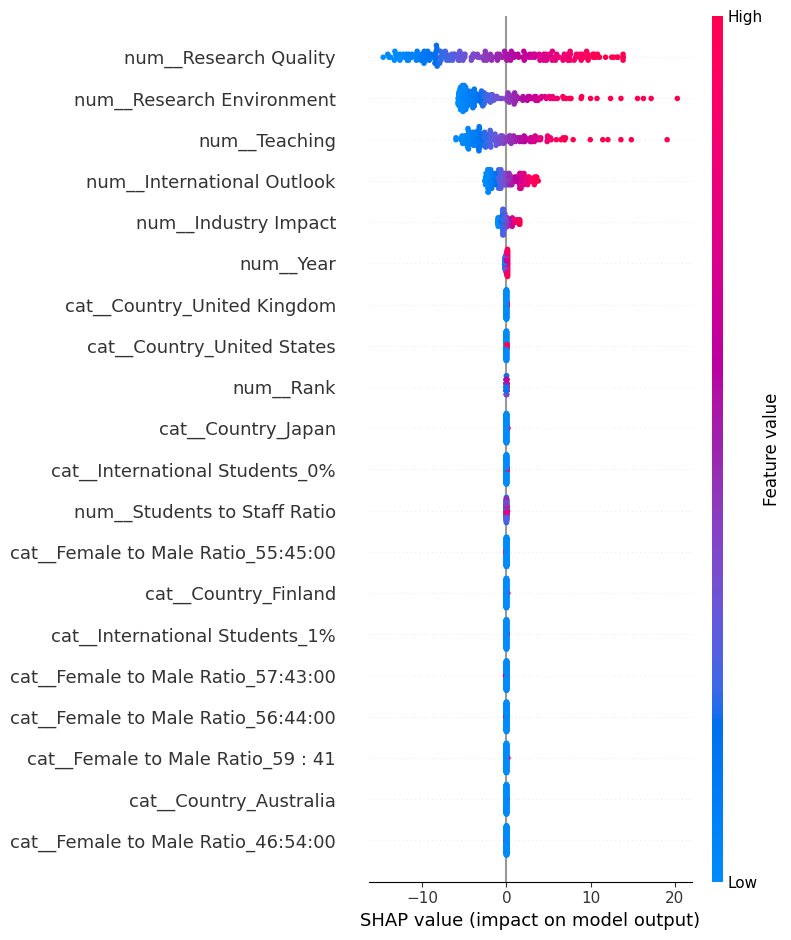

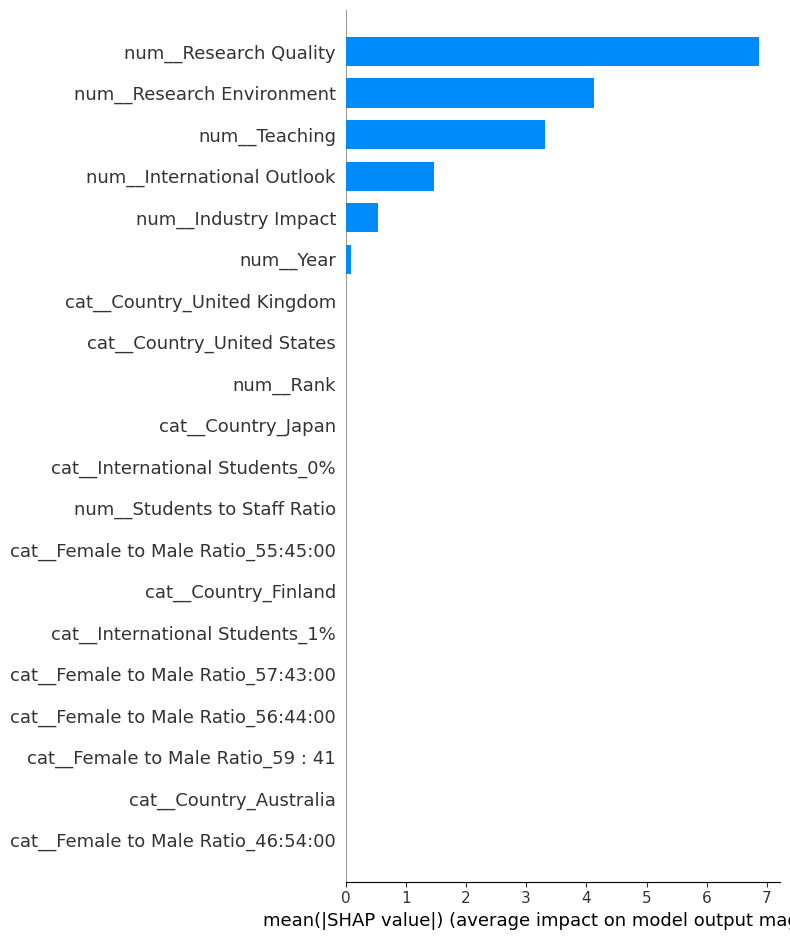


LINEAR REGRESSION — University Rankings
Accuracy (R²) = 0.9999
R2=0.9999 | MAE=0.1339 | RMSE=0.0304 | MAPE=0.0045
TrainTime(s)=2.901 | Inference(ms/sample)=0.0371

Readiness (0–5) breakdown:
  AccuracyScore(0-5)    : 4.9994
  Fairness(0-5)         : 4.9717
  Interpretability(0-5) : 4.1432
  DataQuality(0-5)      : 4.9620
  Scalability(0-5)      : 4.4680
  ✅ FINAL Readiness(0-5): 4.7354


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


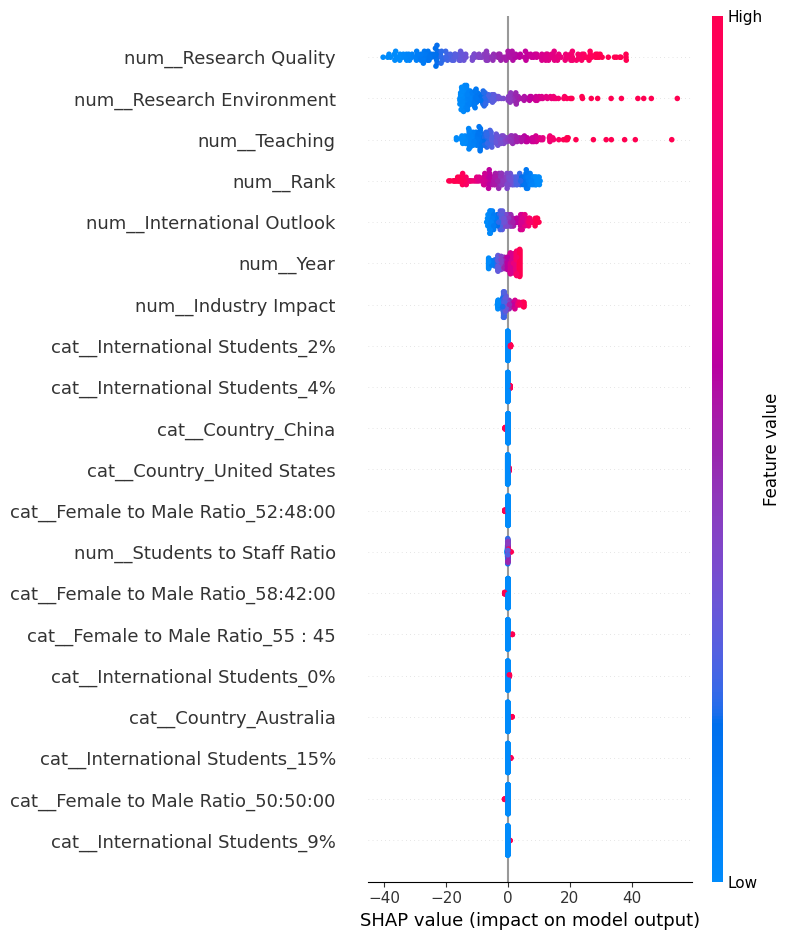

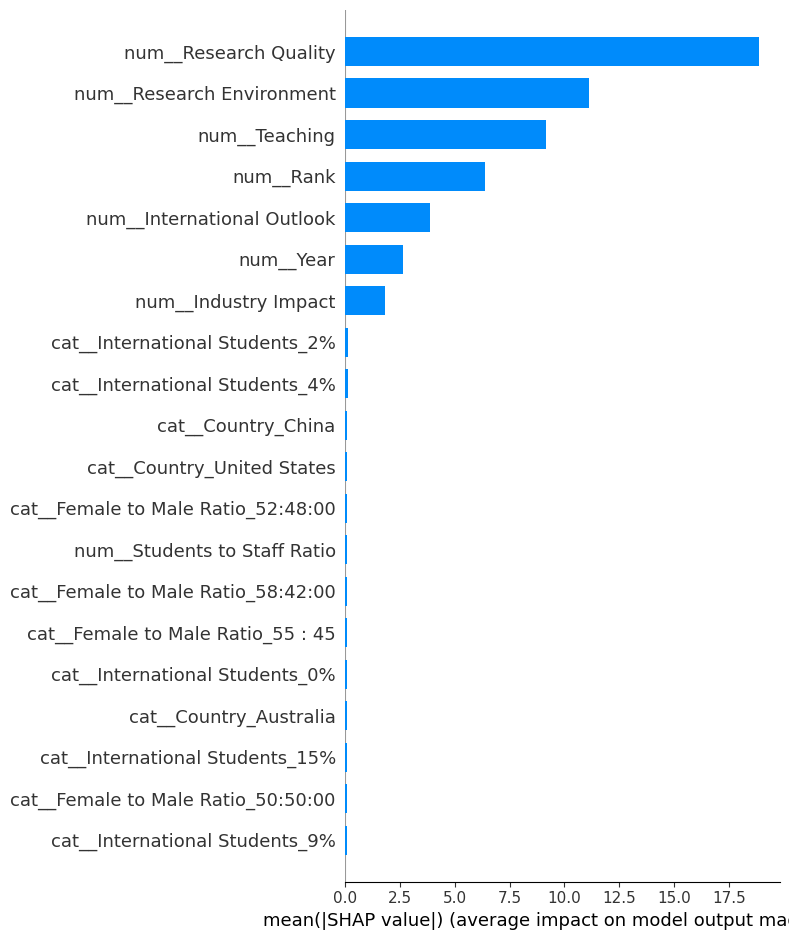


LOGISTIC REGRESSION (tuned) — Binary classification: OverallScore > median
Median threshold (train) = 32.8680
Accuracy=0.9931 | F1=0.9929
Tuning time (s) = 57.565
✅ Best params = {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 10.0}


In [8]:
# Small, self-contained script:
# 1) LinearRegression on THE Rankings -> metrics + readiness + SHAP
# 2) LogisticRegression (classification on same data via median split) -> hyperparam tuning + SHAP
# NOTE: LogisticRegression is NOT a regression model, so we create a binary label from Overall Score.

import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, f1_score

import shap
import matplotlib.pyplot as plt

shap.initjs()

# -------------------------
# CONFIG
# -------------------------
CSV_PATH = "/content/university_rankings/THE World University Rankings 2016-2026.csv"
TARGET = "Overall Score"
SHAP_SAMPLE = 200
RANDOM_STATE = 42

WEIGHTS = {  # your weights
    "Accuracy": 0.25,
    "Fairness": 0.20,
    "Interpretability": 0.20,
    "DataQuality": 0.20,
    "Scalability": 0.15,
}

# -------------------------
# Helpers
# -------------------------
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(1e-9, np.abs(y_true))
    return float(np.mean(np.abs((y_true - y_pred) / denom)))

def data_quality_score_from_X(X_df: pd.DataFrame) -> float:
    total = X_df.size
    miss = X_df.isna().sum().sum()
    missing_ratio = 0.0 if total == 0 else miss / total
    score = 5.0 * (1.0 - min(1.0, 2.0 * missing_ratio))  # 0 if >=50% missing
    return float(np.clip(score, 0.0, 5.0))

def scalability_score(train_time_s: float, infer_ms_per_sample: float) -> float:
    # 5 - log10(1+time)*1.5 clipped; train(60%) + infer(40%)
    def f_seconds(t_sec: float):
        return float(np.clip(5.0 - np.log10(1.0 + max(0.0, t_sec)) * 1.5, 0.0, 5.0))

    train_component = f_seconds(train_time_s)
    infer_component = f_seconds((infer_ms_per_sample / 1000.0))  # ms -> sec
    return float(0.6 * train_component + 0.4 * infer_component)

def fairness_score_from_shap_bins(shap_2d: np.ndarray, preds: np.ndarray, K: int = 4) -> float:
    sv = np.array(shap_2d, dtype=float)
    preds = np.array(preds, dtype=float).reshape(-1)

    n = min(len(preds), sv.shape[0])
    if n < 10:
        return 2.5
    sv = sv[:n]
    preds = preds[:n]

    qs = np.quantile(preds, np.linspace(0, 1, K + 1))
    bins = []
    for k in range(K):
        mask = (preds >= qs[k]) & (preds <= qs[k+1] if k == K-1 else preds < qs[k+1])
        idx = np.where(mask)[0]
        if len(idx) > 0:
            bins.append(idx)

    if len(bins) < 2:
        return 2.5

    mus = [np.mean(np.abs(sv[idx]), axis=0) for idx in bins]
    dsum, cnt = 0.0, 0
    for i in range(len(mus)):
        for j in range(i + 1, len(mus)):
            dsum += float(np.mean(np.abs(mus[i] - mus[j])))
            cnt += 1

    div = dsum / max(1, cnt)
    score = 5.0 * (1.0 / (1.0 + 10.0 * div))
    return float(np.clip(score, 0.0, 5.0))

def interpretability_score_from_mean_abs(mean_abs: np.ndarray) -> float:
    v = np.abs(np.array(mean_abs, dtype=float))
    s = v.sum()
    if s <= 0:
        return 0.0
    p = v / s
    eps = 1e-12
    entropy = -np.sum(p * np.log(p + eps))
    max_entropy = np.log(len(p) + eps)
    conc = 1.0 - (entropy / max_entropy if max_entropy > 0 else 0.0)
    return float(np.clip(5.0 * conc, 0.0, 5.0))

def acc_score_0_5_regression(r2: float) -> float:
    return float(np.clip(5.0 * max(0.0, r2), 0.0, 5.0))

def acc_score_0_5_classification(acc: float) -> float:
    return float(np.clip(5.0 * acc, 0.0, 5.0))

def ms_per_sample(model, X, n=2000):
    Xs = X[: min(n, X.shape[0])]
    t0 = time.time()
    _ = model.predict(Xs)
    dt = time.time() - t0
    return float(1000.0 * dt / max(1, Xs.shape[0]))

# -------------------------
# Load + basic clean
# -------------------------
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.astype(str).str.strip()

if TARGET not in df.columns:
    raise KeyError(f"Target '{TARGET}' not found. Available: {df.columns.tolist()}")

# Drop obvious ID-like columns if present (optional; safe)
drop_cols = [c for c in df.columns if c.lower() in ["unnamed: 0", "name"]]
df = df.drop(columns=drop_cols, errors="ignore")

# Separate X/y
y = pd.to_numeric(df[TARGET], errors="coerce")
X = df.drop(columns=[TARGET]).copy()

# Remove rows where target missing
mask = y.notna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

# Data quality score computed from raw X (before preprocessing)
dq = data_quality_score_from_X(X)

# Identify numeric vs categorical
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# ==========================================================
# 1) Linear Regression (Regression) -> readiness + SHAP
# ==========================================================
lin_pipe = Pipeline([("pre", pre), ("model", LinearRegression())])

t0 = time.time()
lin_pipe.fit(X_tr, y_tr)
train_time = time.time() - t0

y_hat = lin_pipe.predict(X_te)
r2 = r2_score(y_te, y_hat)
mae = mean_absolute_error(y_te, y_hat)
rmse = mean_squared_error(y_te, y_hat)
mape = safe_mape(y_te, y_hat)

# inference time on transformed dense/sparse OK via pipeline predict
infer_ms = ms_per_sample(lin_pipe, X_te.values if isinstance(X_te, np.ndarray) else X_te)

# ---- SHAP for LinearRegression on transformed matrix
Xt_tr = lin_pipe.named_steps["pre"].transform(X_tr)
Xt_te = lin_pipe.named_steps["pre"].transform(X_te)

Xt_tr_d = Xt_tr.toarray() if hasattr(Xt_tr, "toarray") else Xt_tr
Xt_te_d = Xt_te.toarray() if hasattr(Xt_te, "toarray") else Xt_te

try:
    feat_names = lin_pipe.named_steps["pre"].get_feature_names_out()
except Exception:
    feat_names = [f"feature_{i}" for i in range(Xt_te_d.shape[1])]

# sample for SHAP
idx = np.random.RandomState(RANDOM_STATE).choice(Xt_te_d.shape[0], size=min(SHAP_SAMPLE, Xt_te_d.shape[0]), replace=False)
Xt_te_s = Xt_te_d[idx]

# LinearExplainer works well for linear models
expl = shap.LinearExplainer(lin_pipe.named_steps["model"], Xt_tr_d, feature_perturbation="interventional")
sv = expl.shap_values(Xt_te_s)  # (n, p)

# plots
plt.figure()
shap.summary_plot(sv, Xt_te_s, feature_names=feat_names, show=False)
plt.tight_layout()
plt.show()

# SHAP BAR PLOT (feature importance)
plt.figure()
shap.summary_plot(
    sv,
    Xt_te_s,
    feature_names=feat_names,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.show()

# interpretability + fairness from SHAP
mean_abs = np.mean(np.abs(sv), axis=0)
interp = interpretability_score_from_mean_abs(mean_abs)

# fairness bins use predictions on the same sample
preds_s = lin_pipe.named_steps["model"].predict(Xt_te_s)
fair = fairness_score_from_shap_bins(sv, preds_s, K=4)

acc05 = acc_score_0_5_regression(r2)
sc = scalability_score(train_time, infer_ms)

readiness_lin = (
    WEIGHTS["Accuracy"] * acc05 +
    WEIGHTS["Fairness"] * fair +
    WEIGHTS["Interpretability"] * interp +
    WEIGHTS["DataQuality"] * dq +
    WEIGHTS["Scalability"] * sc
)

print("\n" + "="*90)
print("LINEAR REGRESSION — University Rankings")
print("="*90)
print(f"Accuracy (R²) = {r2:.4f}")
print(f"R2={r2:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f} | MAPE={mape:.4f}")
print(f"TrainTime(s)={train_time:.3f} | Inference(ms/sample)={infer_ms:.4f}")
print("\nReadiness (0–5) breakdown:")
print(f"  AccuracyScore(0-5)    : {acc05:.4f}")
print(f"  Fairness(0-5)         : {fair:.4f}")
print(f"  Interpretability(0-5) : {interp:.4f}")
print(f"  DataQuality(0-5)      : {dq:.4f}")
print(f"  Scalability(0-5)      : {sc:.4f}")
print(f"  ✅ FINAL Readiness(0-5): {readiness_lin:.4f}")

# ==========================================================
# 2) Logistic Regression (Classification) -> hyperparam tuning + SHAP
#    We create a binary label: AboveMedianScore
# ==========================================================
median_score = float(np.median(y_tr))
y_tr_cls = (y_tr > median_score).astype(int)
y_te_cls = (y_te > median_score).astype(int)

log_pipe = Pipeline([
    ("pre", pre),
    ("model", LogisticRegression(max_iter=2000))
])

param_dist = {
    "model__C": [0.01, 0.1, 1.0, 3.0, 10.0],
    "model__solver": ["lbfgs", "saga"],
    "model__penalty": ["l2"],
}

search = RandomizedSearchCV(
    estimator=log_pipe,
    param_distributions=param_dist,
    n_iter=8,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

t0 = time.time()
search.fit(X_tr, y_tr_cls)
tune_time = time.time() - t0

best_log = search.best_estimator_
yhat_cls = best_log.predict(X_te)
acc = accuracy_score(y_te_cls, yhat_cls)
f1 = f1_score(y_te_cls, yhat_cls)

# SHAP for LogisticRegression (linear)
Xt_tr2 = best_log.named_steps["pre"].transform(X_tr)
Xt_te2 = best_log.named_steps["pre"].transform(X_te)

Xt_tr2_d = Xt_tr2.toarray() if hasattr(Xt_tr2, "toarray") else Xt_tr2
Xt_te2_d = Xt_te2.toarray() if hasattr(Xt_te2, "toarray") else Xt_te2

try:
    feat_names2 = best_log.named_steps["pre"].get_feature_names_out()
except Exception:
    feat_names2 = [f"feature_{i}" for i in range(Xt_te2_d.shape[1])]

idx2 = np.random.RandomState(RANDOM_STATE).choice(Xt_te2_d.shape[0], size=min(SHAP_SAMPLE, Xt_te2_d.shape[0]), replace=False)
Xt_te2_s = Xt_te2_d[idx2]

expl2 = shap.LinearExplainer(best_log.named_steps["model"], Xt_tr2_d, feature_perturbation="interventional")
sv2 = expl2.shap_values(Xt_te2_s)  # (n, p)

plt.figure()
shap.summary_plot(sv2, Xt_te2_s, feature_names=feat_names2, show=False)
plt.tight_layout()
plt.show()

# SHAP BAR PLOT (feature importance)
plt.figure()
shap.summary_plot(
    sv2,
    Xt_te2_s,
    feature_names=feat_names2,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.show()


print("\n" + "="*90)
print("LOGISTIC REGRESSION (tuned) — Binary classification: OverallScore > median")
print("="*90)
print(f"Median threshold (train) = {median_score:.4f}")
print(f"Accuracy={acc:.4f} | F1={f1:.4f}")
print(f"Tuning time (s) = {tune_time:.3f}")
print(f"✅ Best params = {search.best_params_}")


COMPREHENSIVE ML PIPELINE

Task type detected: Regression
Train shape: (13370, 13), Test shape: (3343, 13)

🔧 Training models (baseline + tuning)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2196
[LightGBM] [Info] Number of data points in the train set: 13370, number of used features: 209
[LightGBM] [Info] Start training from score 35.748341
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001437 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2196
[LightGBM] [Info] Number of data points in the train set: 13370, number of used features: 209
[LightGBM] [Info] Start training from score 35.748341

📌 BEFORE vs AFTER Hyperparameter Tuning (per model)

Model: RandomForest
  BEFORE:
Regression Accuracy (R2): 0.9993
Accuracy: None | F1: None
RMSE: 0.4414 | MAE: 

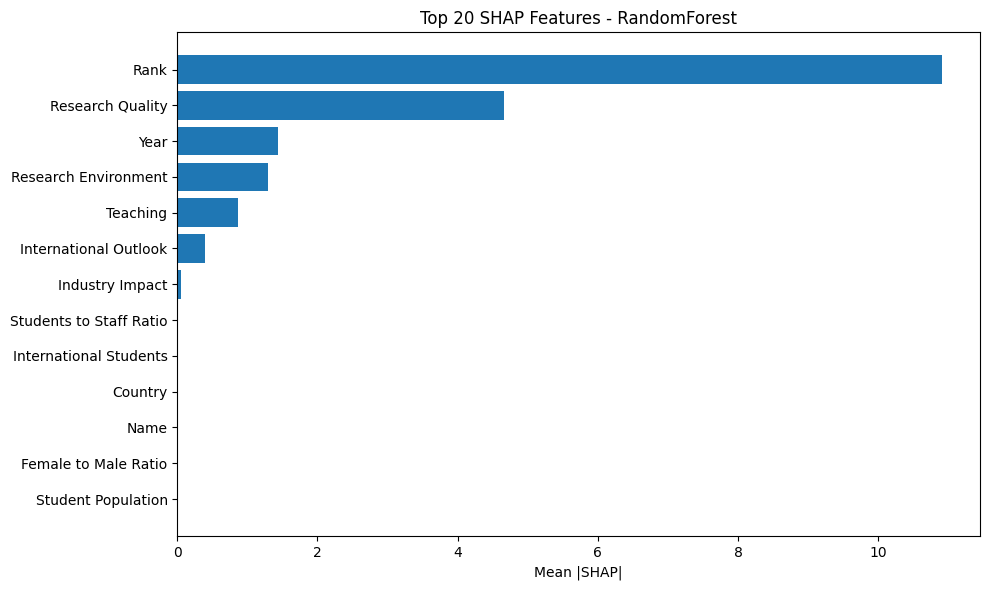

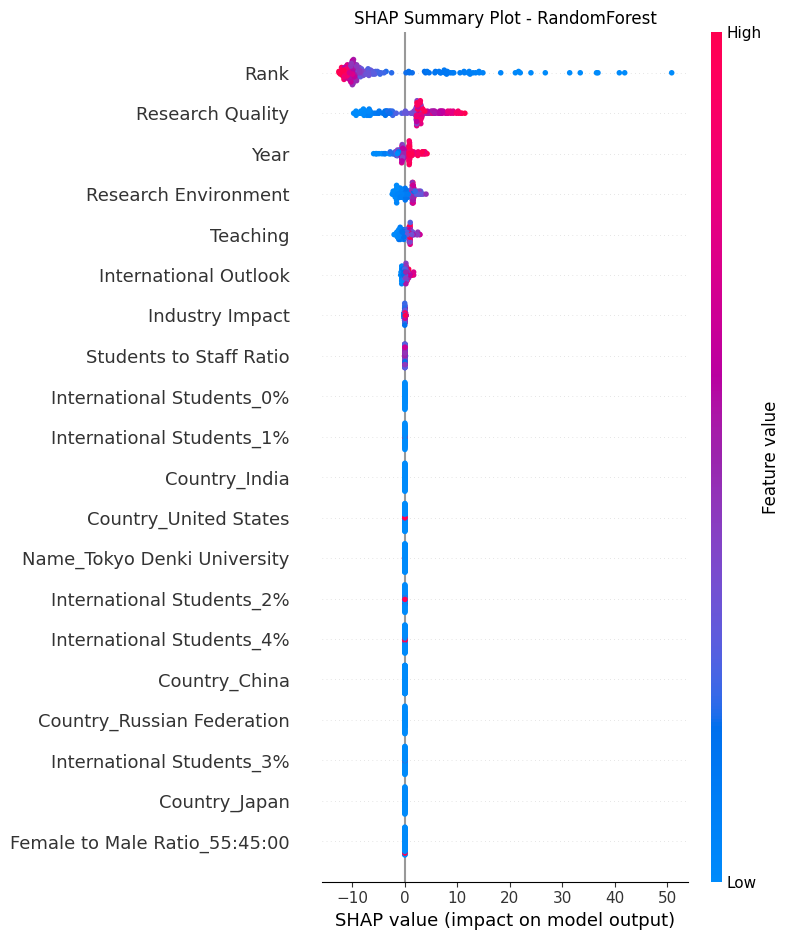

  ✅ SHAP displayed + saved:
     - shap_outputs/RandomForest_shap_bar.png
     - shap_outputs/RandomForest_shap_summary.png

Running SHAP for: HistGB


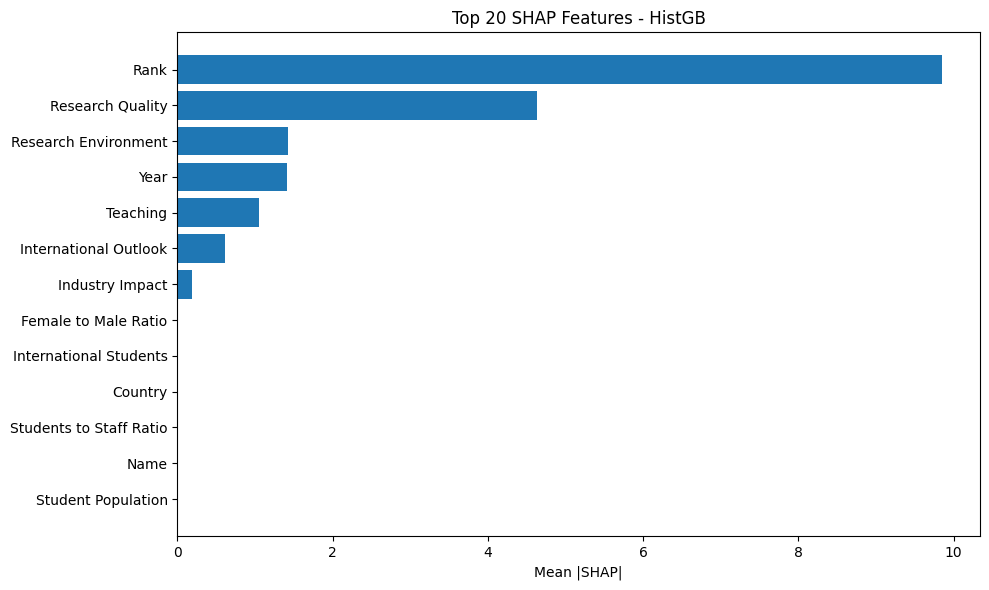

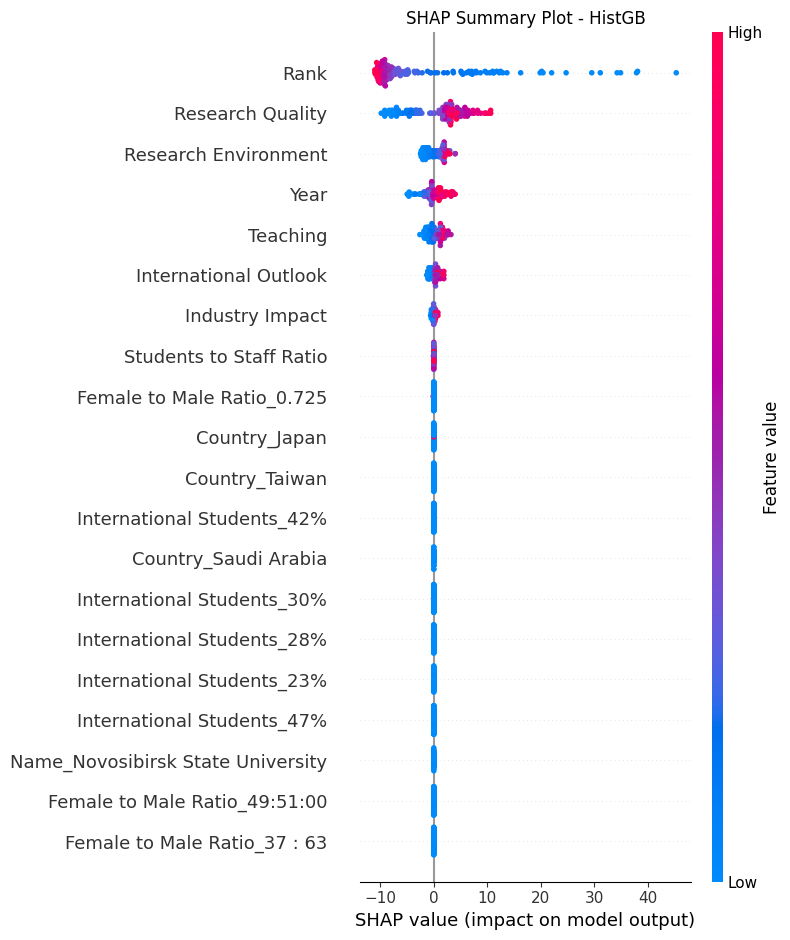

  ✅ SHAP displayed + saved:
     - shap_outputs/HistGB_shap_bar.png
     - shap_outputs/HistGB_shap_summary.png

Running SHAP for: XGBoost


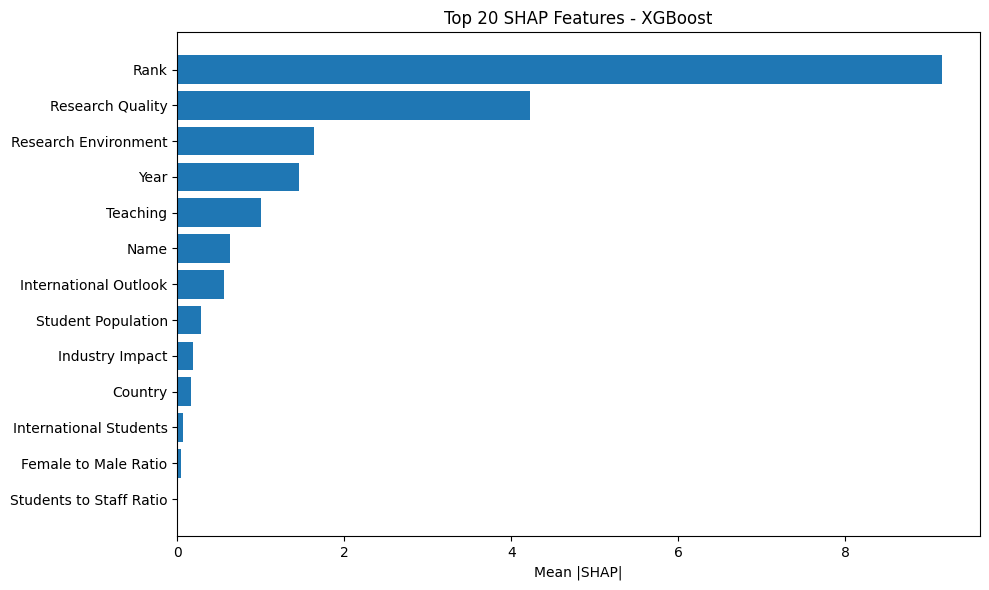

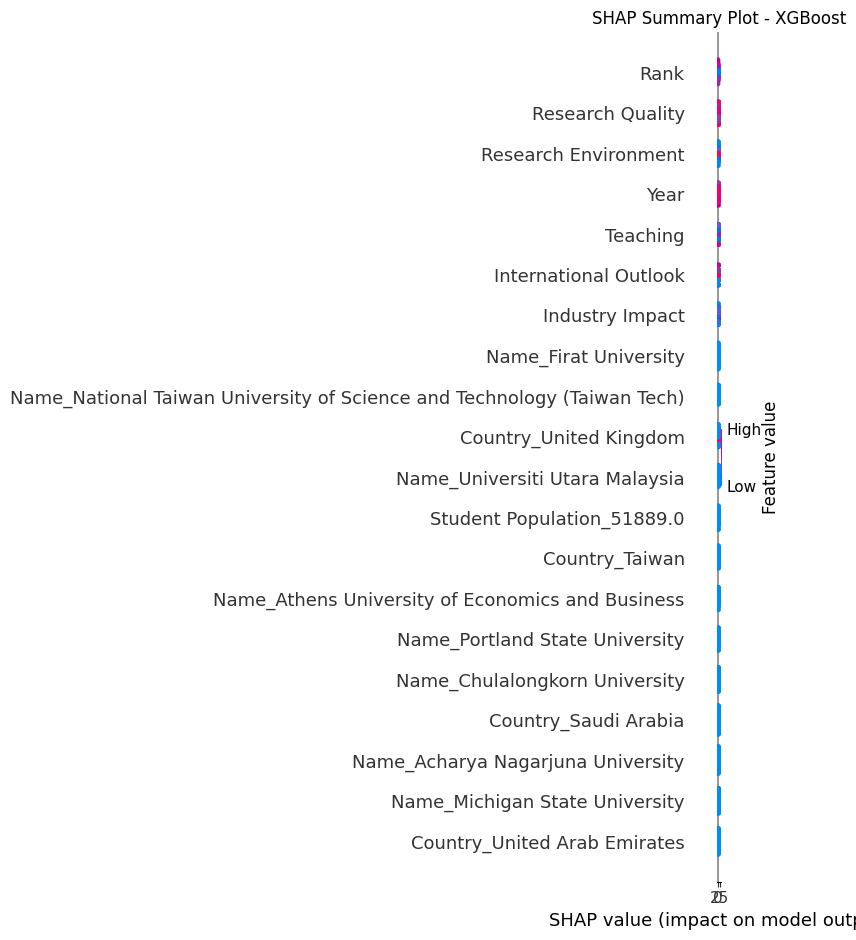

  ✅ SHAP displayed + saved:
     - shap_outputs/XGBoost_shap_bar.png
     - shap_outputs/XGBoost_shap_summary.png

Running SHAP for: LightGBM


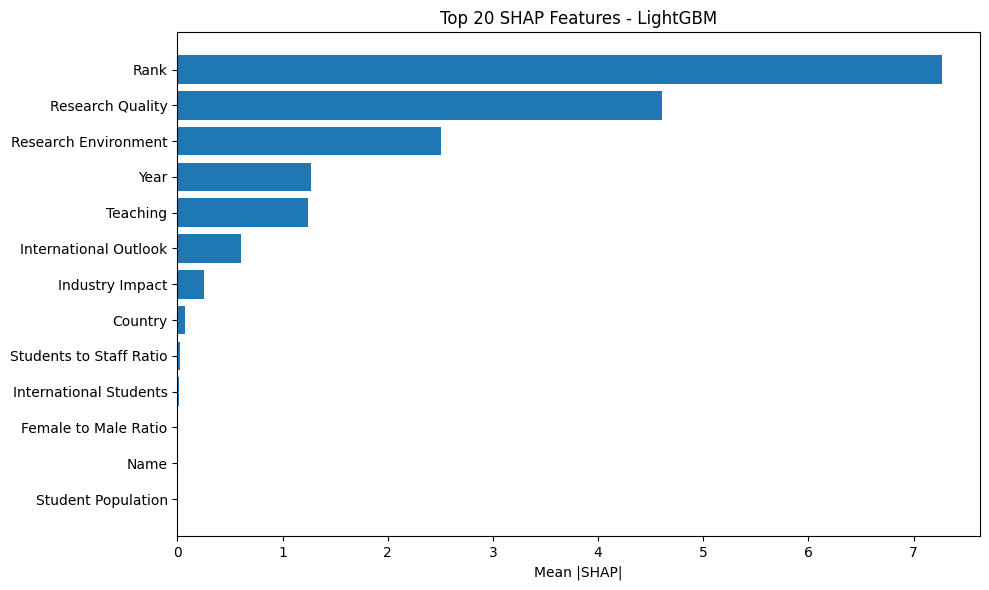

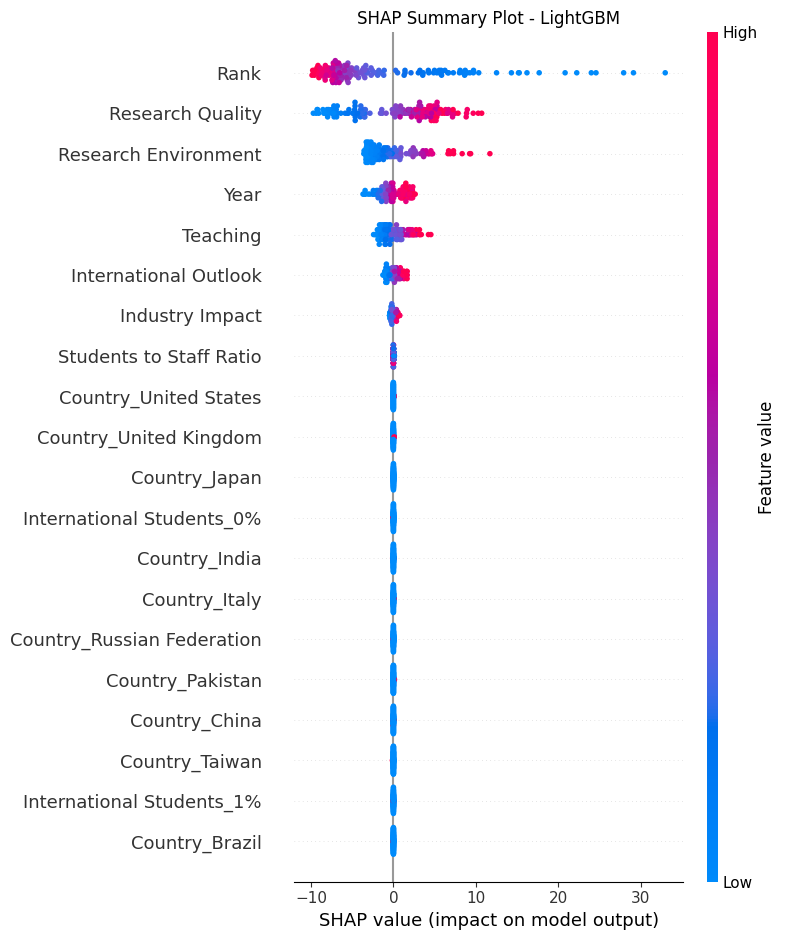

  ✅ SHAP displayed + saved:
     - shap_outputs/LightGBM_shap_bar.png
     - shap_outputs/LightGBM_shap_summary.png

📊 EDUCATIONAL AI READINESS SCORE (per model, 0–5)

Model: RandomForest
  Data Quality     : 4.965
  Accuracy         : 4.998
  Interpretability : 4.328
  Scalability      : 2.007
  Fairness         : 3.996
  ✅ Readiness Score: 4.208

Model: HistGB
  Data Quality     : 4.965
  Accuracy         : 4.999
  Interpretability : 4.269
  Scalability      : 1.964
  Fairness         : 4.048
  ✅ Readiness Score: 4.201

Model: XGBoost
  Data Quality     : 4.965
  Accuracy         : 4.999
  Interpretability : 3.997
  Scalability      : 2.8
  Fairness         : 4.035
  ✅ Readiness Score: 4.269

Model: LightGBM
  Data Quality     : 4.965
  Accuracy         : 4.999
  Interpretability : 4.171
  Scalability      : 3.517
  Fairness         : 4.112
  ✅ Readiness Score: 4.427


In [ ]:
results_rankings = comprehensive_ml_pipeline(
    dataset_path="/content/university_rankings/THE World University Rankings 2016-2026.csv",
    target_column="Overall Score",
    task_type="auto",
    fast_mode="auto",      # activates fast defaults
    do_hyperparam_tuning=True,
    compute_shap=True,
    use_tfidf=False
)
